In [49]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [50]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


from datasets import Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)



In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import joblib

train_df = joblib.load('drive/MyDrive/nlp/train_df.pkl')
val_df = joblib.load('drive/MyDrive/nlp/val_df.pkl')
test_df = joblib.load('drive/MyDrive/nlp/test_df.pkl')

In [53]:
train_df.head()

,text,variety,source,Sentiment,Sarcasm,tokens,clean_text
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0,"[member, but, vote, lib, dem, so, tight, tory,...",member but vote lib dem so tight tory not cont...
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0,"[yeah, blow, 3x, what, budget, who, would, ve,...",yeah blow 3x what budget who would ve think gi...
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0,"[food, pretty, great, little, dry, but, sucker...",food pretty great little dry but sucker load d...
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0,"[firstly, staff, they, want, cheese, ham, toas...",firstly staff they want cheese ham toasty orde...
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0,"[we, come, lunch, enjoy, food, we, order, hot,...",we come lunch enjoy food we order hot taste fr...


### Compute metrics for baseline

In [54]:
def compute_metrics_from_preds(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    cls_report = classification_report(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)




    print(f"Accuracy: {acc}")
    print(f"Macro F1: {f1_macro}")
    print(f"Weighted F1: {f1_weighted}")
    print(f"Precision: {precision_macro}")
    print(f"Recall: {recall_macro}")
    print("Classification Report:")
    print(cls_report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


    return {
        "accuracy": acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "precision": precision_macro,
        "recall": recall_macro,
        "classification_report": cls_report
    }


## Basic Baseline setup

In [55]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['Sentiment']
y_test = test_df['Sentiment']

y_train_s = train_df['Sarcasm']
y_test_s = test_df['Sarcasm']

In [56]:
X_train.shape, X_test.shape

((3747, 5000), (2183, 5000))

In [57]:
y_train.value_counts(), y_test.value_counts()

(Sentiment
 0.0    1907
 1.0    1840
 Name: count, dtype: int64,
 Sentiment
 0.0    1117
 1.0    1066
 Name: count, dtype: int64)

In [58]:
y_train_s.value_counts(), y_test_s.value_counts()

(Sarcasm
 0.0    3223
 1.0     524
 Name: count, dtype: int64,
 Sarcasm
 0.0    1878
 1.0     305
 Name: count, dtype: int64)

In [59]:
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=500, C=1.0, class_weight='balanced')

### Sentiment

In [60]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.8314246449839671
Macro F1: 0.8307184242777743
Weighted F1: 0.8309738658098015
Precision: 0.8339276861749086
Recall: 0.830368885432536
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84      1117
         1.0       0.86      0.79      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



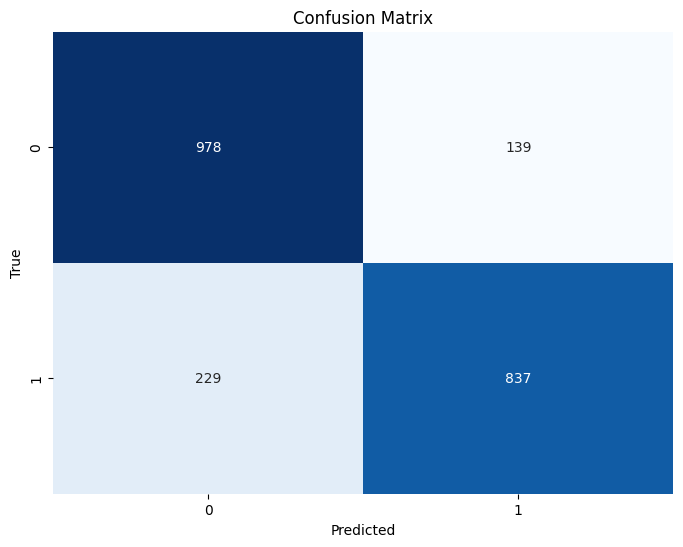

{'accuracy': 0.8314246449839671,
 'macro_f1': 0.8307184242777743,
 'weighted_f1': 0.8309738658098015,
 'precision': 0.8339276861749086,
 'recall': 0.830368885432536,
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.81      0.88      0.84      1117\n         1.0       0.86      0.79      0.82      1066\n\n    accuracy                           0.83      2183\n   macro avg       0.83      0.83      0.83      2183\nweighted avg       0.83      0.83      0.83      2183\n'}

In [61]:
compute_metrics_from_preds(y_test, y_pred)

### Sarcasm

In [62]:
model.fit(X_train, y_train_s)
y_pred_s = model.predict(X_test)

Accuracy: 0.7370590929912963
Macro F1: 0.6162039215109726
Weighted F1: 0.7713918274199925
Precision: 0.6100856779669499
Recall: 0.692017144154053
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      1878
         1.0       0.29      0.63      0.40       305

    accuracy                           0.74      2183
   macro avg       0.61      0.69      0.62      2183
weighted avg       0.84      0.74      0.77      2183



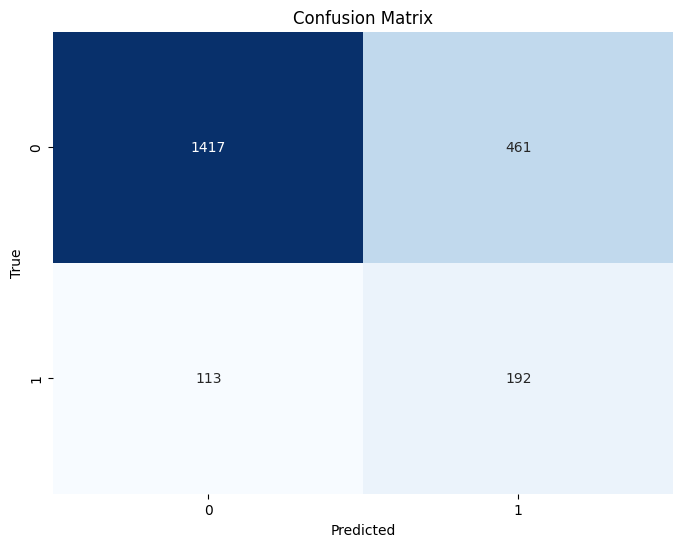

{'accuracy': 0.7370590929912963,
 'macro_f1': 0.6162039215109726,
 'weighted_f1': 0.7713918274199925,
 'precision': 0.6100856779669499,
 'recall': 0.692017144154053,
 'classification_report': '              precision    recall  f1-score   support\n\n         0.0       0.93      0.75      0.83      1878\n         1.0       0.29      0.63      0.40       305\n\n    accuracy                           0.74      2183\n   macro avg       0.61      0.69      0.62      2183\nweighted avg       0.84      0.74      0.77      2183\n'}

In [63]:
compute_metrics_from_preds(y_test_s, y_pred_s)

## Tuning for TF-IDF+LR

In [64]:
def find_best_config(label_col, candidate_configs):

    train_local = train_df[["clean_text", label_col]].copy()
    val_local = val_df[["clean_text", label_col]].copy()
    test_local = test_df[["clean_text", label_col]].copy()

    best_config = None
    best_val_f1 = -1
    tuning_rows = []

    # Tune on validation
    for config in candidate_configs:
        vectorizer = TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=config["ngram_range"]
        )

        X_train = vectorizer.fit_transform(train_local["clean_text"])
        X_val = vectorizer.transform(val_local["clean_text"])

        y_train = train_local[label_col]
        y_val = val_local[label_col]

        clf = LogisticRegression(
            max_iter=config["max_iter"],
            solver="liblinear",
            C=config["C"],
            class_weight=config["class_weight"],
            random_state=42
        )
        clf.fit(X_train, y_train)
        val_pred = clf.predict(X_val)
        val_metrics = compute_metrics_from_preds(y_val, val_pred)

        row = config.copy()
        row["val_macro_f1"] = val_metrics["macro_f1"]
        tuning_rows.append(row)

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_config = config

    tuning_df = pd.DataFrame(tuning_rows).sort_values("val_macro_f1", ascending=False)
    print(f"\nBest baseline config for {label_col}:")
    print(best_config)
    display(tuning_df)
    return best_config

In [65]:
candidate_configs = [
      {"max_features": 5000, "ngram_range": (1, 1), "C": 1.0, "class_weight": None, "max_iter": 500},
      {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0, "class_weight": None, "max_iter": 500},
      {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0, "class_weight": "balanced", "max_iter": 500},
      {"max_features": 10000, "ngram_range": (1, 2), "C": 1.0, "class_weight": "balanced", "max_iter": 500},
      {"max_features": 10000, "ngram_range": (1, 2), "C": 2.0, "class_weight": "balanced", "max_iter": 500},
      {"max_features": 5000, "ngram_range": (1, 1), "C": 1.0, "class_weight": None, "max_iter": 1000},
      {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0, "class_weight": None, "max_iter": 1000},
      {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0, "class_weight": "balanced", "max_iter": 1000},
      {"max_features": 10000, "ngram_range": (1, 2), "C": 1.0, "class_weight": "balanced", "max_iter": 1000},
      {"max_features": 10000, "ngram_range": (1, 2), "C": 2.0, "class_weight": "balanced", "max_iter": 1000}
  ]

Accuracy: 0.8370607028753994
Macro F1: 0.8370008066739506
Weighted F1: 0.8370706855756408
Precision: 0.8369680633831578
Recall: 0.8370506535947713
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       160
         1.0       0.83      0.84      0.83       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



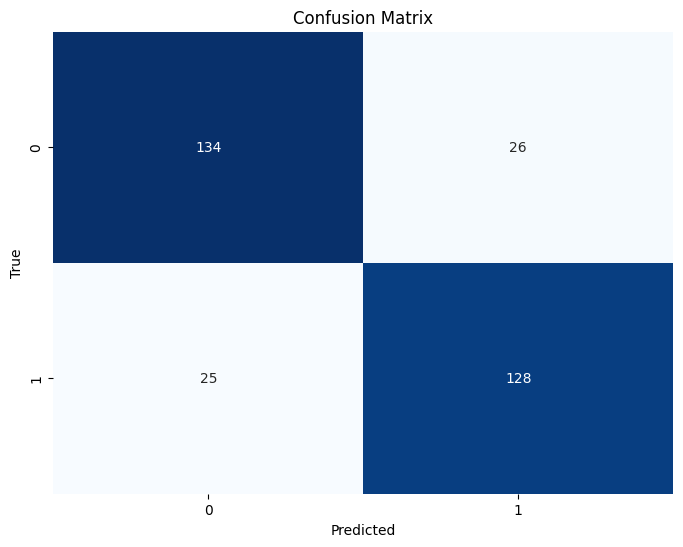

Accuracy: 0.8370607028753994
Macro F1: 0.8370008066739506
Weighted F1: 0.8370706855756408
Precision: 0.8369680633831578
Recall: 0.8370506535947713
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       160
         1.0       0.83      0.84      0.83       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



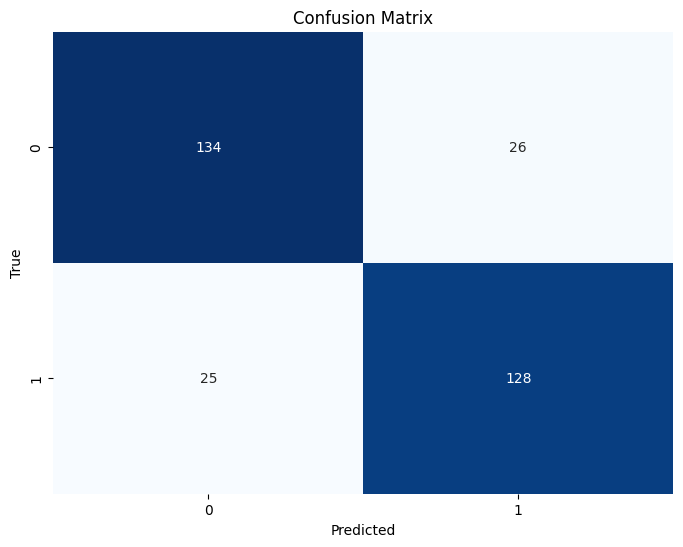

Accuracy: 0.8338658146964856
Macro F1: 0.8338641188959661
Weighted F1: 0.8338759894996032
Precision: 0.8341297067712162
Recall: 0.8342116013071895
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       160
         1.0       0.82      0.85      0.83       153

    accuracy                           0.83       313
   macro avg       0.83      0.83      0.83       313
weighted avg       0.83      0.83      0.83       313



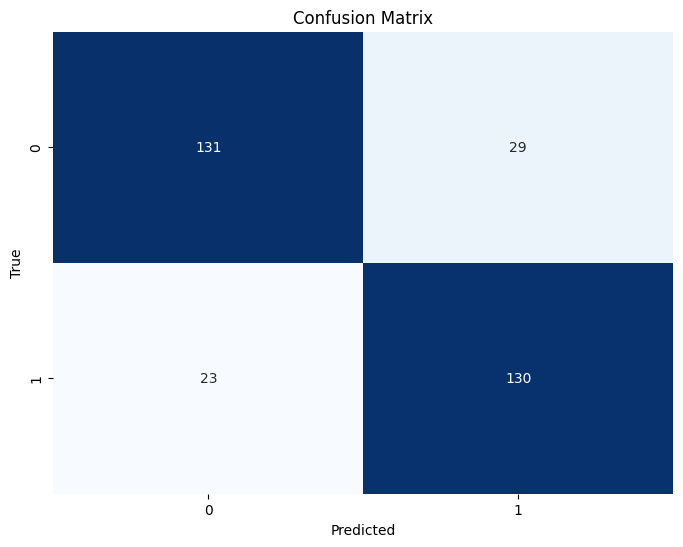

Accuracy: 0.8338658146964856
Macro F1: 0.8338641188959661
Weighted F1: 0.8338759894996032
Precision: 0.8341297067712162
Recall: 0.8342116013071895
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       160
         1.0       0.82      0.85      0.83       153

    accuracy                           0.83       313
   macro avg       0.83      0.83      0.83       313
weighted avg       0.83      0.83      0.83       313



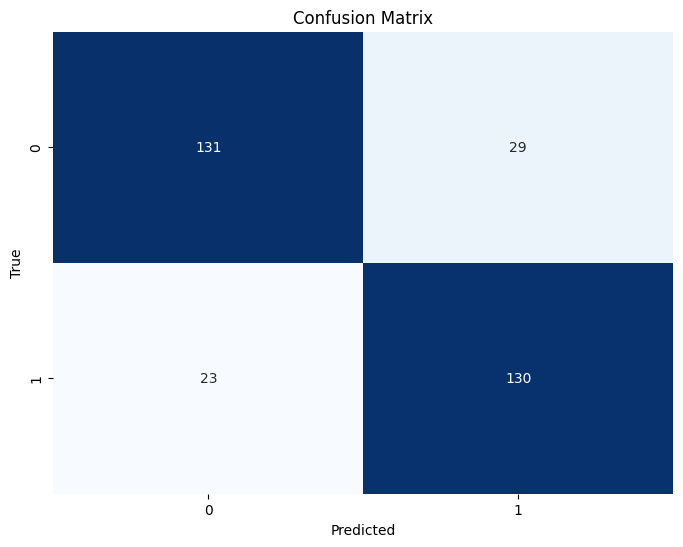

Accuracy: 0.8370607028753994
Macro F1: 0.8370607028753994
Weighted F1: 0.8370607028753994
Precision: 0.8374795751633987
Recall: 0.8374795751633987
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84       160
         1.0       0.82      0.86      0.84       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



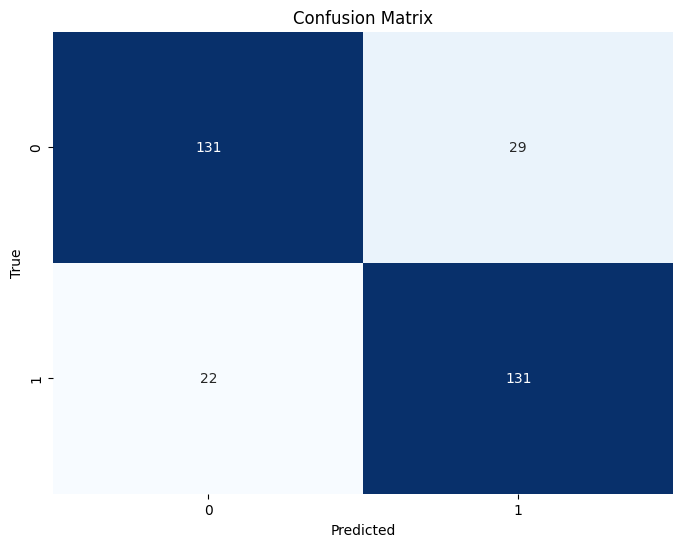

Accuracy: 0.8370607028753994
Macro F1: 0.8370008066739506
Weighted F1: 0.8370706855756408
Precision: 0.8369680633831578
Recall: 0.8370506535947713
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       160
         1.0       0.83      0.84      0.83       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



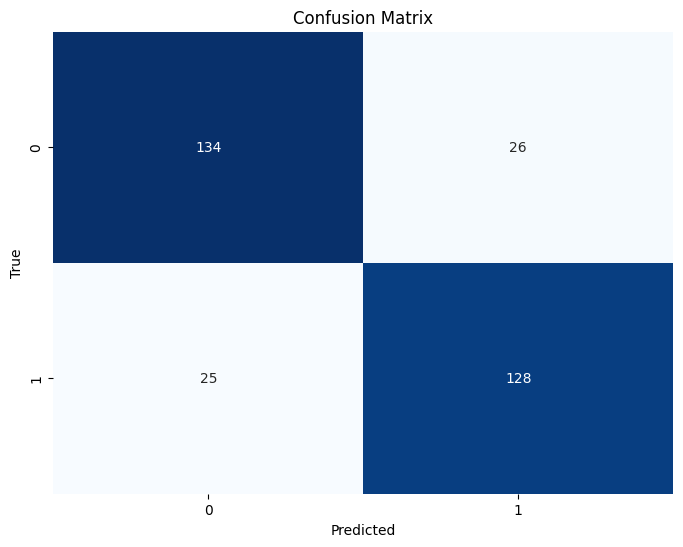

Accuracy: 0.8370607028753994
Macro F1: 0.8370008066739506
Weighted F1: 0.8370706855756408
Precision: 0.8369680633831578
Recall: 0.8370506535947713
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       160
         1.0       0.83      0.84      0.83       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



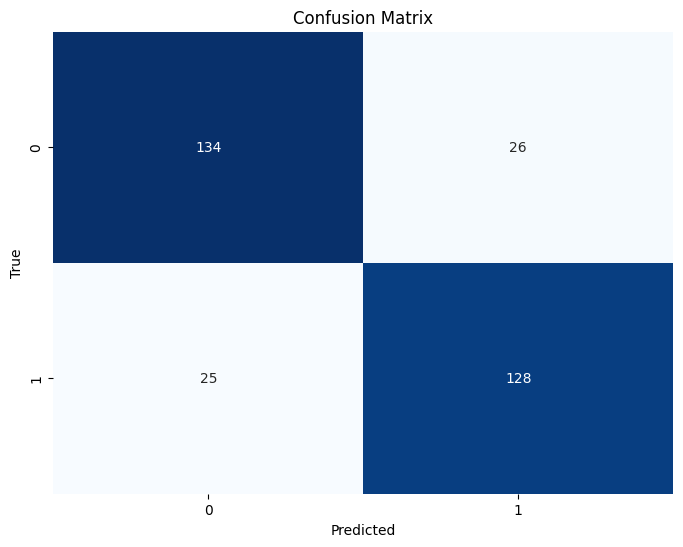

Accuracy: 0.8338658146964856
Macro F1: 0.8338641188959661
Weighted F1: 0.8338759894996032
Precision: 0.8341297067712162
Recall: 0.8342116013071895
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       160
         1.0       0.82      0.85      0.83       153

    accuracy                           0.83       313
   macro avg       0.83      0.83      0.83       313
weighted avg       0.83      0.83      0.83       313



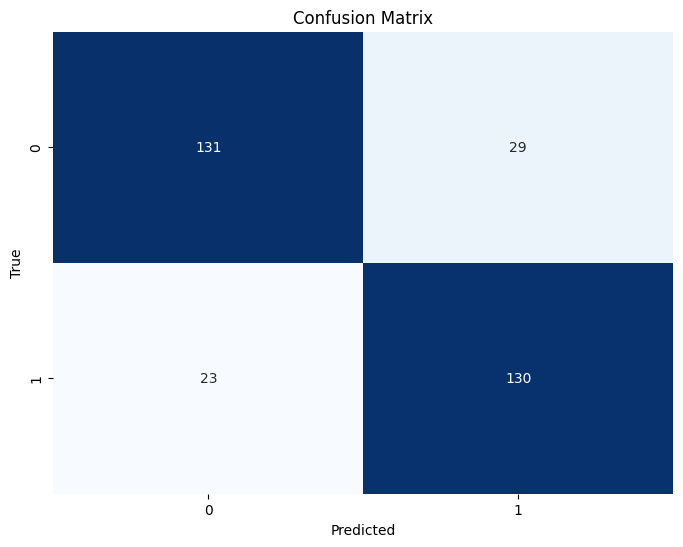

Accuracy: 0.8338658146964856
Macro F1: 0.8338641188959661
Weighted F1: 0.8338759894996032
Precision: 0.8341297067712162
Recall: 0.8342116013071895
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       160
         1.0       0.82      0.85      0.83       153

    accuracy                           0.83       313
   macro avg       0.83      0.83      0.83       313
weighted avg       0.83      0.83      0.83       313



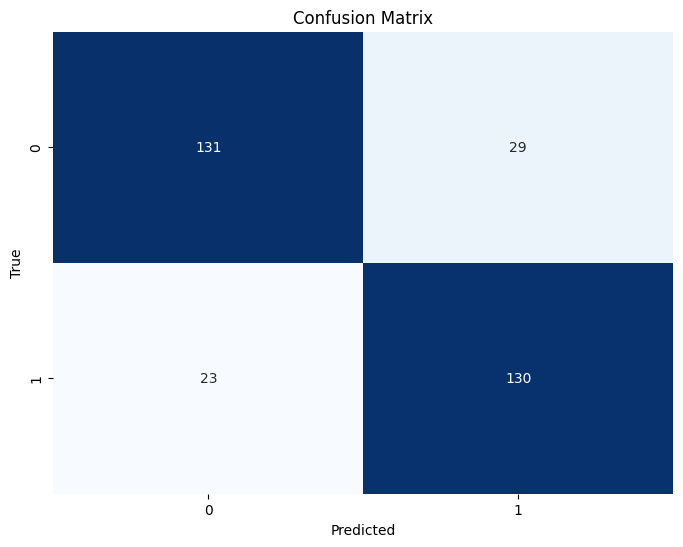

Accuracy: 0.8370607028753994
Macro F1: 0.8370607028753994
Weighted F1: 0.8370607028753994
Precision: 0.8374795751633987
Recall: 0.8374795751633987
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84       160
         1.0       0.82      0.86      0.84       153

    accuracy                           0.84       313
   macro avg       0.84      0.84      0.84       313
weighted avg       0.84      0.84      0.84       313



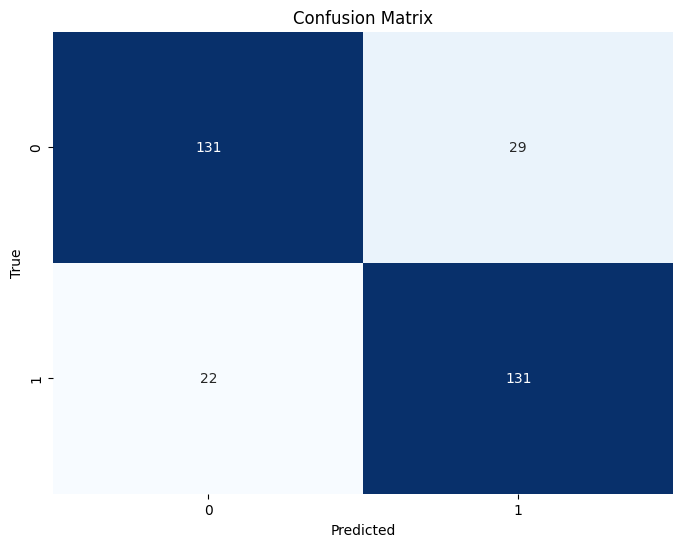


Best baseline config for Sentiment:
{'max_features': 10000, 'ngram_range': (1, 2), 'C': 2.0, 'class_weight': 'balanced', 'max_iter': 500}


,max_features,ngram_range,C,class_weight,max_iter,val_macro_f1
9,10000,"(1, 2)",2.0,balanced,1000,0.837061
4,10000,"(1, 2)",2.0,balanced,500,0.837061
1,5000,"(1, 2)",1.0,None,500,0.837001
0,5000,"(1, 1)",1.0,None,500,0.837001
6,5000,"(1, 2)",1.0,None,1000,0.837001
5,5000,"(1, 1)",1.0,None,1000,0.837001
2,5000,"(1, 2)",1.0,balanced,500,0.833864
3,10000,"(1, 2)",1.0,balanced,500,0.833864
7,5000,"(1, 2)",1.0,balanced,1000,0.833864
8,10000,"(1, 2)",1.0,balanced,1000,0.833864


In [66]:
best_sentiment = find_best_config("Sentiment", candidate_configs)

Accuracy: 0.8594249201277955
Macro F1: 0.46219931271477666
Weighted F1: 0.7944512148260379
Precision: 0.42971246006389774
Recall: 0.5
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       269
         1.0       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



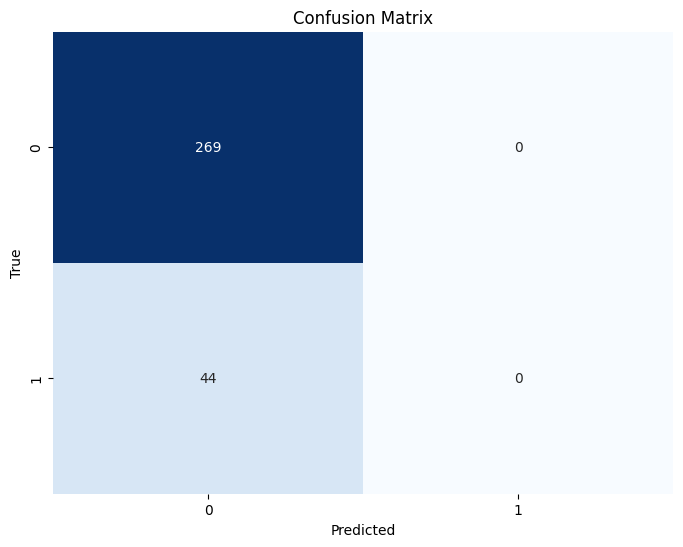

Accuracy: 0.8562300319488818
Macro F1: 0.4612736660929432
Weighted F1: 0.7928601672779663
Precision: 0.42948717948717946
Recall: 0.49814126394052044
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       269
         1.0       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



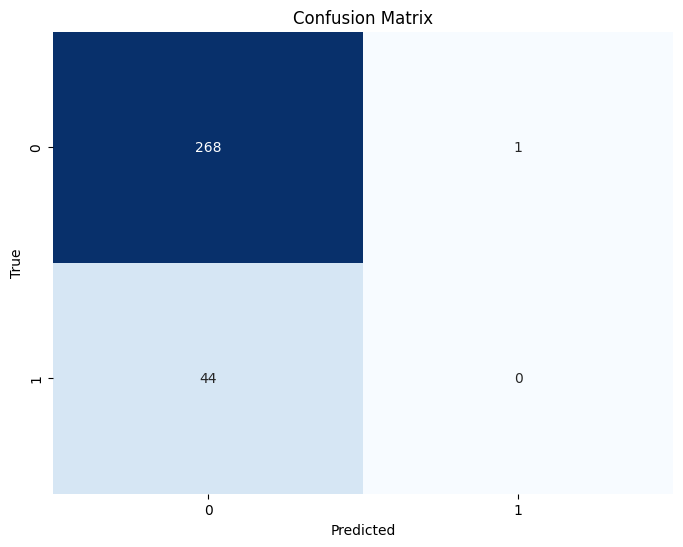

Accuracy: 0.7667731629392971
Macro F1: 0.6552915440899147
Weighted F1: 0.7962093207253699
Precision: 0.6410503910503911
Recall: 0.740748563703954
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.78      0.85       269
         1.0       0.34      0.70      0.46        44

    accuracy                           0.77       313
   macro avg       0.64      0.74      0.66       313
weighted avg       0.86      0.77      0.80       313



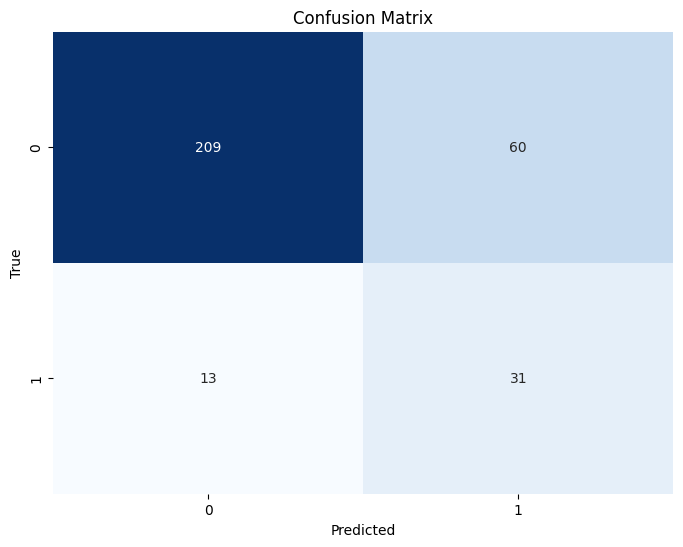

Accuracy: 0.7731629392971247
Macro F1: 0.6572904618706146
Weighted F1: 0.8005394037440473
Precision: 0.6414403417760146
Recall: 0.7349611355187563
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.79      0.86       269
         1.0       0.34      0.68      0.46        44

    accuracy                           0.77       313
   macro avg       0.64      0.73      0.66       313
weighted avg       0.85      0.77      0.80       313



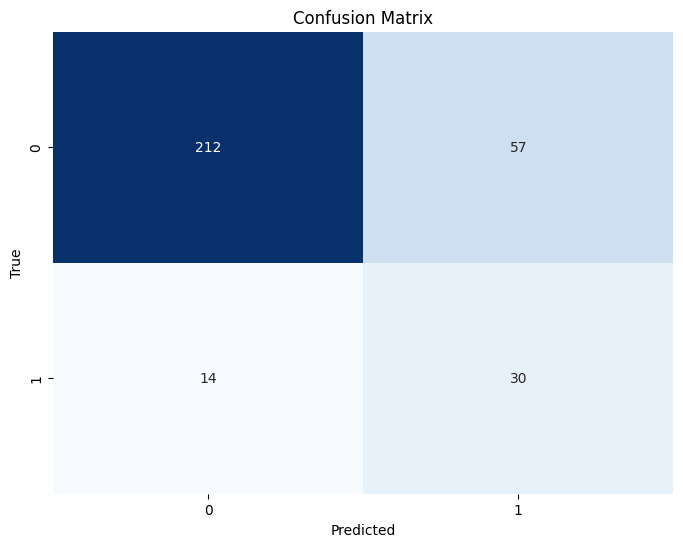

Accuracy: 0.8019169329073482
Macro F1: 0.6629030016675931
Weighted F1: 0.818515611264334
Precision: 0.6450480192076831
Recall: 0.7041652585332883
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.84      0.88       269
         1.0       0.37      0.57      0.45        44

    accuracy                           0.80       313
   macro avg       0.65      0.70      0.66       313
weighted avg       0.84      0.80      0.82       313



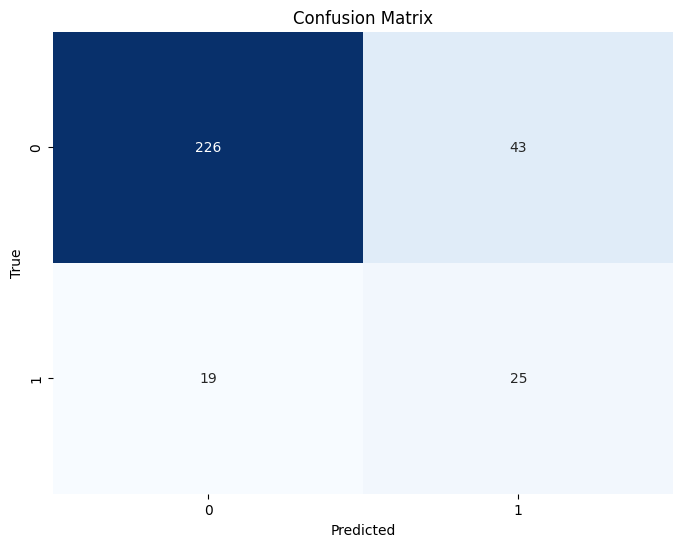

Accuracy: 0.8594249201277955
Macro F1: 0.46219931271477666
Weighted F1: 0.7944512148260379
Precision: 0.42971246006389774
Recall: 0.5
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       269
         1.0       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



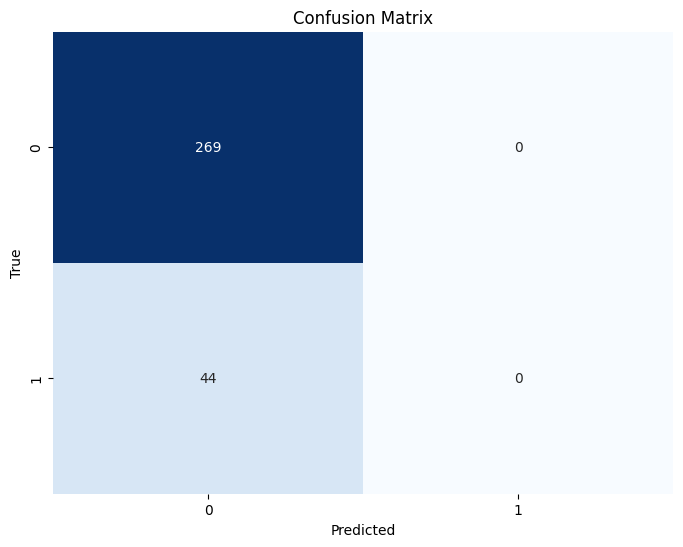

Accuracy: 0.8562300319488818
Macro F1: 0.4612736660929432
Weighted F1: 0.7928601672779663
Precision: 0.42948717948717946
Recall: 0.49814126394052044
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       269
         1.0       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



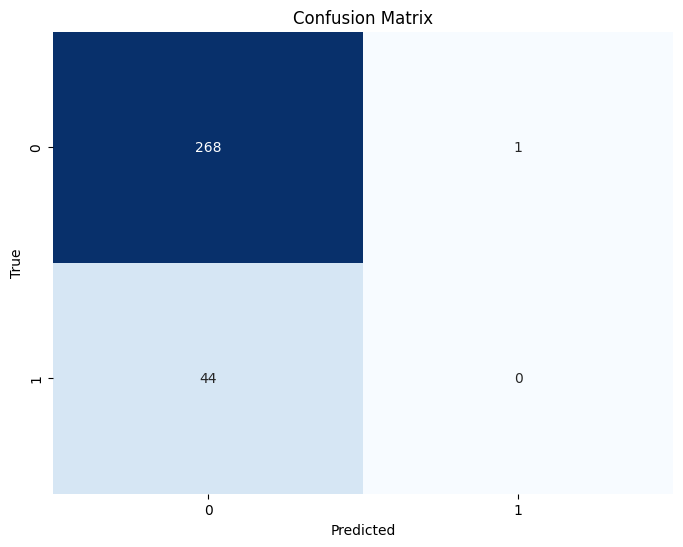

Accuracy: 0.7667731629392971
Macro F1: 0.6552915440899147
Weighted F1: 0.7962093207253699
Precision: 0.6410503910503911
Recall: 0.740748563703954
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.78      0.85       269
         1.0       0.34      0.70      0.46        44

    accuracy                           0.77       313
   macro avg       0.64      0.74      0.66       313
weighted avg       0.86      0.77      0.80       313



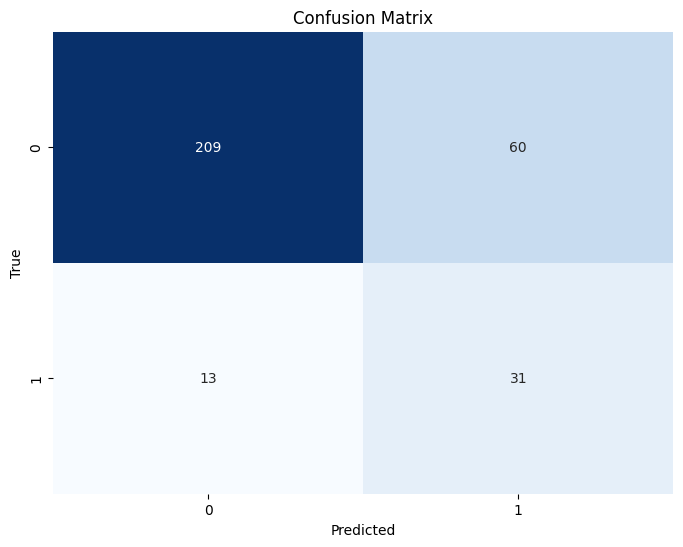

Accuracy: 0.7731629392971247
Macro F1: 0.6572904618706146
Weighted F1: 0.8005394037440473
Precision: 0.6414403417760146
Recall: 0.7349611355187563
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.79      0.86       269
         1.0       0.34      0.68      0.46        44

    accuracy                           0.77       313
   macro avg       0.64      0.73      0.66       313
weighted avg       0.85      0.77      0.80       313



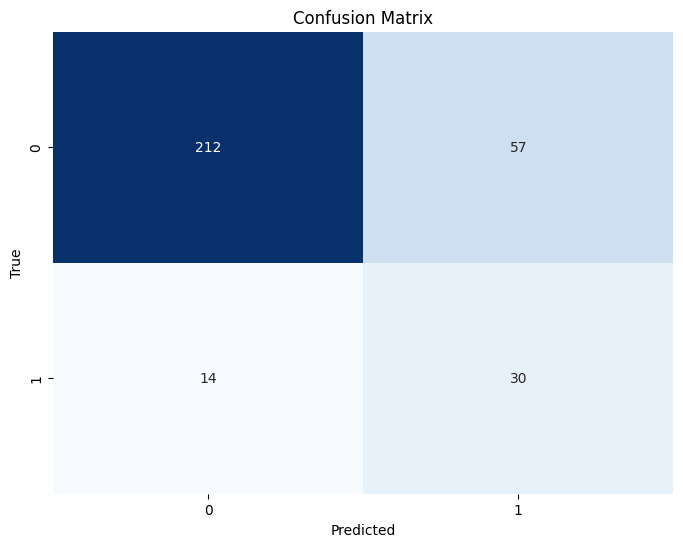

Accuracy: 0.8019169329073482
Macro F1: 0.6629030016675931
Weighted F1: 0.818515611264334
Precision: 0.6450480192076831
Recall: 0.7041652585332883
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.84      0.88       269
         1.0       0.37      0.57      0.45        44

    accuracy                           0.80       313
   macro avg       0.65      0.70      0.66       313
weighted avg       0.84      0.80      0.82       313



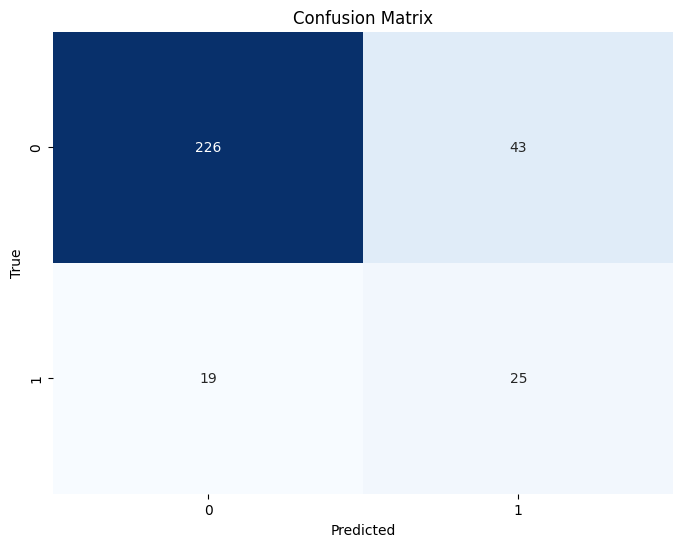


Best baseline config for Sarcasm:
{'max_features': 10000, 'ngram_range': (1, 2), 'C': 2.0, 'class_weight': 'balanced', 'max_iter': 500}


,max_features,ngram_range,C,class_weight,max_iter,val_macro_f1
9,10000,"(1, 2)",2.0,balanced,1000,0.662903
4,10000,"(1, 2)",2.0,balanced,500,0.662903
8,10000,"(1, 2)",1.0,balanced,1000,0.657290
3,10000,"(1, 2)",1.0,balanced,500,0.657290
7,5000,"(1, 2)",1.0,balanced,1000,0.655292
2,5000,"(1, 2)",1.0,balanced,500,0.655292
5,5000,"(1, 1)",1.0,None,1000,0.462199
0,5000,"(1, 1)",1.0,None,500,0.462199
1,5000,"(1, 2)",1.0,None,500,0.461274
6,5000,"(1, 2)",1.0,None,1000,0.461274


In [67]:
best_sarcasm = find_best_config("Sarcasm", candidate_configs)


## Running the model with best hyperparameters

In [68]:
sentiment_vectorizer = TfidfVectorizer(
      max_features=best_sentiment["max_features"],
      ngram_range=best_sentiment["ngram_range"]
  )

X_train = sentiment_vectorizer.fit_transform(train_df["clean_text"])
X_test = sentiment_vectorizer.transform(test_df["clean_text"])

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

sarcasm_vectorizer = TfidfVectorizer(
      max_features=best_sarcasm["max_features"],
      ngram_range=best_sarcasm["ngram_range"]
  )

X_train_s = sarcasm_vectorizer.fit_transform(train_df["clean_text"])
X_test_s = sarcasm_vectorizer.transform(test_df["clean_text"])

y_train_s = train_df["Sarcasm"]
y_test_s = test_df["Sarcasm"]

In [69]:
X_train.shape, X_train_s.shape

((3747, 10000), (3747, 10000))

Sentiment Model
Accuracy: 0.8305084745762712
Macro F1: 0.8300691244239631
Weighted F1: 0.830270988007456
Precision: 0.8316283268950444
Recall: 0.8297734483783787
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1117
         1.0       0.85      0.80      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



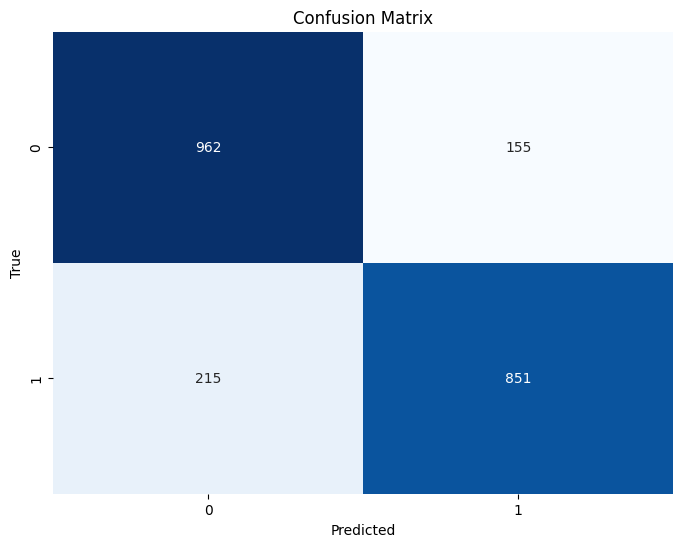

Sarcasm Model
Accuracy: 0.7764544205222171
Macro F1: 0.6183708620279538
Weighted F1: 0.7953569385485775
Precision: 0.6064933298715428
Recall: 0.6503779744758114
Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.83      0.86      1878
         1.0       0.31      0.48      0.37       305

    accuracy                           0.78      2183
   macro avg       0.61      0.65      0.62      2183
weighted avg       0.82      0.78      0.80      2183



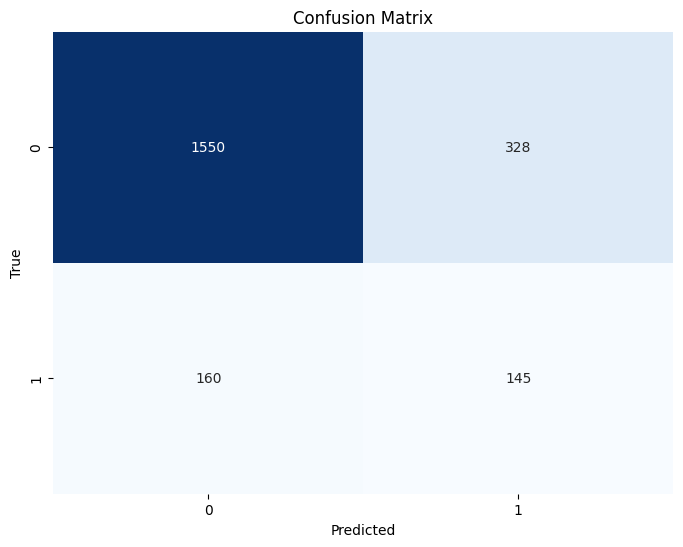

Seed 42 done
Sentiment Model
Accuracy: 0.8305084745762712
Macro F1: 0.8300691244239631
Weighted F1: 0.830270988007456
Precision: 0.8316283268950444
Recall: 0.8297734483783787
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1117
         1.0       0.85      0.80      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



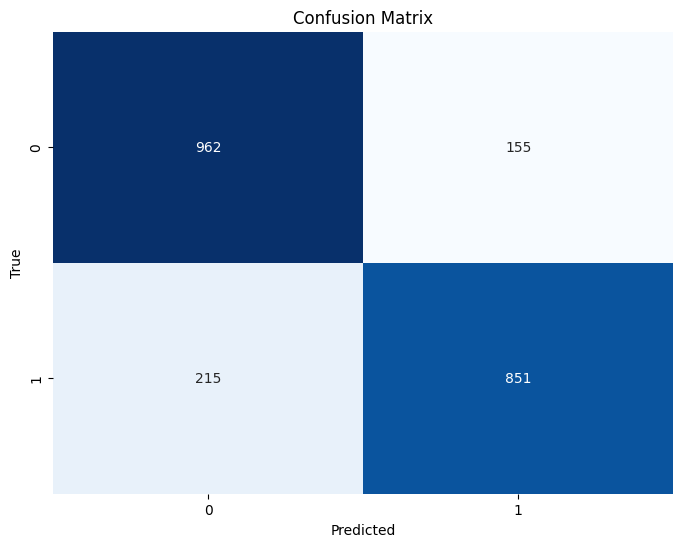

Sarcasm Model
Accuracy: 0.7764544205222171
Macro F1: 0.6183708620279538
Weighted F1: 0.7953569385485775
Precision: 0.6064933298715428
Recall: 0.6503779744758114
Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.83      0.86      1878
         1.0       0.31      0.48      0.37       305

    accuracy                           0.78      2183
   macro avg       0.61      0.65      0.62      2183
weighted avg       0.82      0.78      0.80      2183



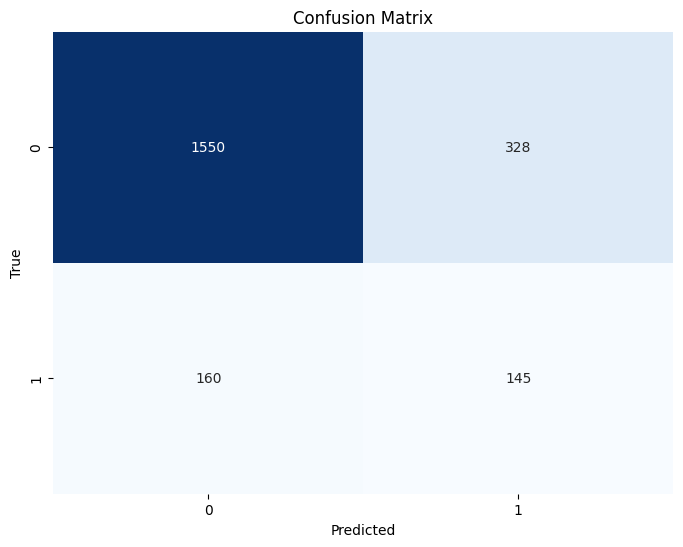

Seed 100 done


In [70]:
sentiment_results = {}
sarcasm_results = {}

seeds = [42,100]

for seed in seeds:

  sentiment_model = LogisticRegression(
      max_iter=best_sentiment["max_iter"],
      solver="liblinear",
      C=best_sentiment["C"],
      class_weight=best_sentiment["class_weight"],
      random_state=seed
  )

  sarcasm_model = LogisticRegression(
      max_iter=best_sarcasm["max_iter"],
      solver="liblinear",
      C=best_sarcasm["C"],
      class_weight=best_sarcasm["class_weight"],
      random_state=seed
  )

  sentiment_model.fit(X_train, y_train)
  sarcasm_model.fit(X_train_s, y_train_s)

  y_pred = sentiment_model.predict(X_test)
  y_pred_s = sarcasm_model.predict(X_test_s)

  print("Sentiment Model")
  sentiment_metrics = compute_metrics_from_preds(y_test, y_pred)

  print("Sarcasm Model")
  sarcasm_metrics = compute_metrics_from_preds(y_test_s, y_pred_s)

  sentiment_results[seed] = sentiment_metrics
  sarcasm_results[seed] = sarcasm_metrics
  print(f"Seed {seed} done")


In [71]:
sentiment_results_pd = pd.DataFrame(sentiment_results)
sentiment_results_pd

,42,100
accuracy,0.830508,0.830508
macro_f1,0.830069,0.830069
weighted_f1,0.830271,0.830271
precision,0.831628,0.831628
recall,0.829773,0.829773
classification_report,precision recall f1-score ...,precision recall f1-score ...


In [72]:
sarcasm_results_pd = pd.DataFrame(sarcasm_results)
sarcasm_results_pd

,42,100
accuracy,0.776454,0.776454
macro_f1,0.618371,0.618371
weighted_f1,0.795357,0.795357
precision,0.606493,0.606493
recall,0.650378,0.650378
classification_report,precision recall f1-score ...,precision recall f1-score ...


# Transformer

In [73]:
!pip install transformers datasets evaluate -q

In [74]:
train_df.head()

,text,variety,source,Sentiment,Sarcasm,tokens,clean_text
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0,"[member, but, vote, lib, dem, so, tight, tory,...",member but vote lib dem so tight tory not cont...
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0,"[yeah, blow, 3x, what, budget, who, would, ve,...",yeah blow 3x what budget who would ve think gi...
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0,"[food, pretty, great, little, dry, but, sucker...",food pretty great little dry but sucker load d...
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0,"[firstly, staff, they, want, cheese, ham, toas...",firstly staff they want cheese ham toasty orde...
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0,"[we, come, lunch, enjoy, food, we, order, hot,...",we come lunch enjoy food we order hot taste fr...


Setup for Transformer model

In [75]:
#Change Sentiment and Sarcasm to integer
train_df['Sentiment'] = train_df['Sentiment'].map({0.0: 0, 1.0: 1})
train_df['Sarcasm'] = train_df['Sarcasm'].map({0.0: 0, 1.0: 1})
val_df['Sentiment'] = val_df['Sentiment'].map({0.0: 0, 1.0: 1})
val_df['Sarcasm'] = val_df['Sarcasm'].map({0.0: 0, 1.0: 1})
test_df['Sentiment'] = test_df['Sentiment'].map({0.0: 0, 1.0: 1})
test_df['Sarcasm'] = test_df['Sarcasm'].map({0.0: 0, 1.0: 1})

In [76]:
train_df['Sentiment'].value_counts(), train_df['Sarcasm'].value_counts()

(Sentiment
 0    1907
 1    1840
 Name: count, dtype: int64,
 Sarcasm
 0    3223
 1     524
 Name: count, dtype: int64)

In [77]:
train_ds_sent = Dataset.from_pandas(train_df[["text", "Sentiment"]])
val_ds_sent = Dataset.from_pandas(val_df[["text", "Sentiment"]])
test_ds_sent = Dataset.from_pandas(test_df[["text", "Sentiment"]])

train_ds_sarc = Dataset.from_pandas(train_df[["text", "Sarcasm"]])
val_ds_sarc = Dataset.from_pandas(val_df[["text", "Sarcasm"]])
test_ds_sarc = Dataset.from_pandas(test_df[["text", "Sarcasm"]])



In [78]:
train_ds_sent

Dataset({
    features: ['text', 'Sentiment'],
    num_rows: 3747
})

In [79]:
train_ds_sent = train_ds_sent.rename_column("Sentiment", "label")
val_ds_sent   = val_ds_sent.rename_column("Sentiment", "label")
test_ds_sent  = test_ds_sent.rename_column("Sentiment", "label")

train_ds_sarc = train_ds_sarc.rename_column("Sarcasm", "label")
val_ds_sarc   = val_ds_sarc.rename_column("Sarcasm", "label")
test_ds_sarc  = test_ds_sarc.rename_column("Sarcasm", "label")

In [80]:
train_ds_sent

Dataset({
    features: ['text', 'label'],
    num_rows: 3747
})

In [81]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [82]:
def tokenize(batch):
  return tokenizer(
      batch["text"],
      truncation=True,
      padding=False,
      max_length=256
  )

In [83]:
train_ds_sent = train_ds_sent.map(tokenize, batched=True)
val_ds_sent   = val_ds_sent.map(tokenize, batched=True)
test_ds_sent  = test_ds_sent.map(tokenize, batched=True)

train_ds_sarc = train_ds_sarc.map(tokenize, batched=True)
val_ds_sarc   = val_ds_sarc.map(tokenize, batched=True)
test_ds_sarc  = test_ds_sarc.map(tokenize, batched=True)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

## Compute metrics for transformer model

In [84]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    cls_report = classification_report(labels, preds)
    conf_matrix = confusion_matrix(labels, preds)

    print(f"Accuracy: {acc}")
    print(f"Macro F1: {macro_f1}")
    print(f"Weighted F1: {weighted_f1}")
    print(f"Precision: {macro_precision}")
    print(f"Recall: {macro_recall}")
    print("Classification Report:")
    print(cls_report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision": macro_precision,
        "recall": macro_recall,
        "classification_report": cls_report
    }

### Basic Sentiment Analysis with Roberta

In [85]:
model_sent = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(train_df["Sentiment"].unique()),
    problem_type="single_label_classification"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [86]:
training_args = TrainingArguments(
      output_dir = "./sentiment_results",
      weight_decay = 0.001,
      num_train_epochs = 3,
      learning_rate = 2e-5,
      eval_strategy = "epoch",
      save_strategy = "epoch",
      per_device_train_batch_size = 8,
      per_device_eval_batch_size = 8,
      report_to="none"
)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.323643,0.862620,0.861512,0.861234,0.880277,0.865053,precision recall f1-score support 0 0.97 0.76 0.85 160 1 0.79 0.97 0.87 153 accuracy 0.86 313 macro avg 0.88 0.87 0.86 313 weighted avg 0.88 0.86 0.86 313
2,0.413523,0.230526,0.920128,0.920125,0.920136,0.920274,0.920445,precision recall f1-score support 0 0.94 0.91 0.92 160 1 0.91 0.93 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
3,0.259082,0.308692,0.942492,0.942393,0.942446,0.943447,0.942034,precision recall f1-score support 0 0.93 0.96 0.94 160 1 0.96 0.92 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.8626198083067093
Macro F1: 0.861511550136338
Weighted F1: 0.8612344855937452
Precision: 0.8802765957446808
Recall: 0.8650531045751634
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       160
           1       0.79      0.97      0.87       153

    accuracy                           0.86       313
   macro avg       0.88      0.87      0.86       313
weighted avg       0.88      0.86      0.86       313



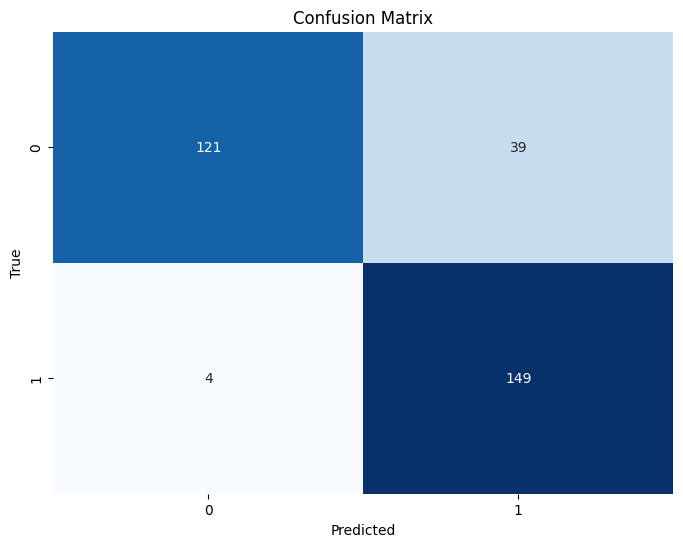

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.9201245342724442
Weighted F1: 0.9201359486639373
Precision: 0.9202735810534912
Recall: 0.9204452614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       160
           1       0.91      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



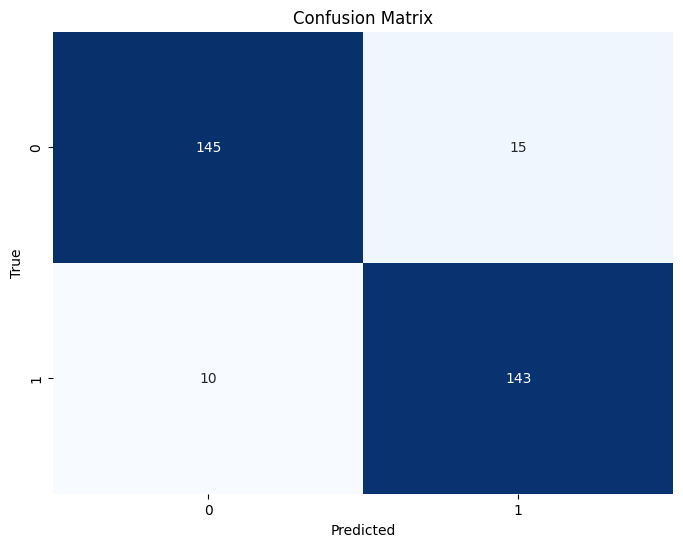

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9424920127795527
Macro F1: 0.9423926380368097
Weighted F1: 0.9424461475136714
Precision: 0.9434472584214408
Recall: 0.9420343137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       160
           1       0.96      0.92      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



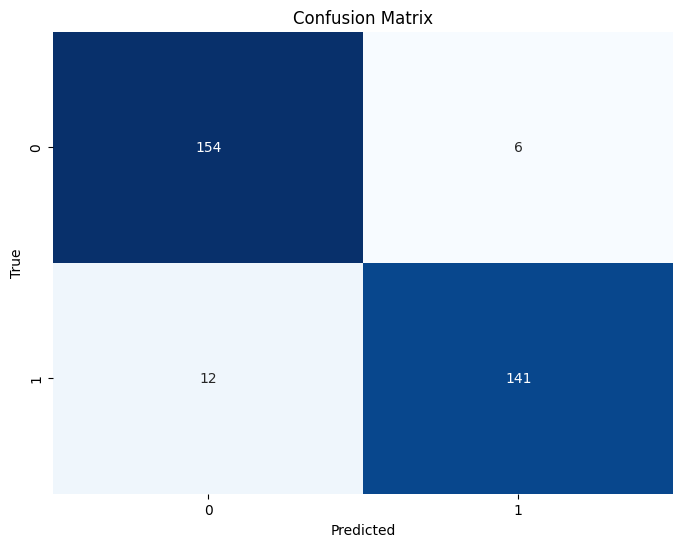

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1407, training_loss=0.29007617920615947, metrics={'train_runtime': 335.8243, 'train_samples_per_second': 33.473, 'train_steps_per_second': 4.19, 'total_flos': 879828980238000.0, 'train_loss': 0.29007617920615947, 'epoch': 3.0})

In [87]:
trainer_sent = Trainer(
    model=model_sent,
    args=training_args,
    train_dataset=train_ds_sent,
    eval_dataset=val_ds_sent,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer_sent.train()

Accuracy: 0.8941823179111315
Macro F1: 0.8941734351656392
Weighted F1: 0.8941960861666446
Precision: 0.8942511889952676
Recall: 0.8944564726275319
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1117
           1       0.88      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183



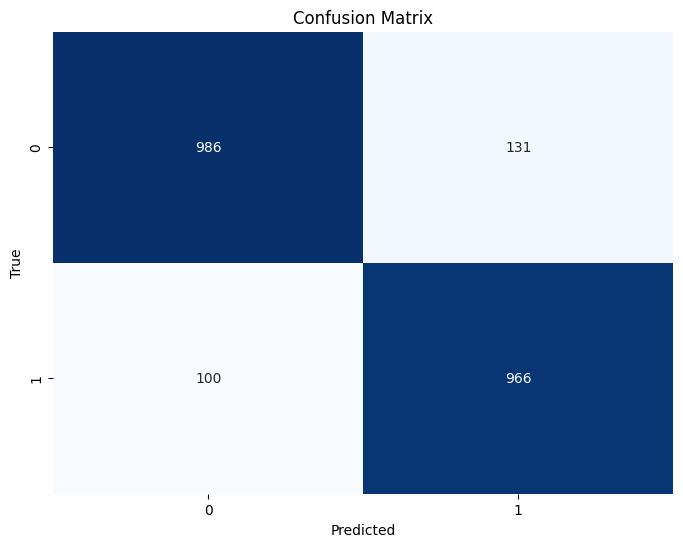

Accuracy: 0.8941823179111315
Macro F1: 0.8941734351656392
Weighted F1: 0.8941960861666446
Precision: 0.8942511889952676
Recall: 0.8944564726275319
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1117
           1       0.88      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183



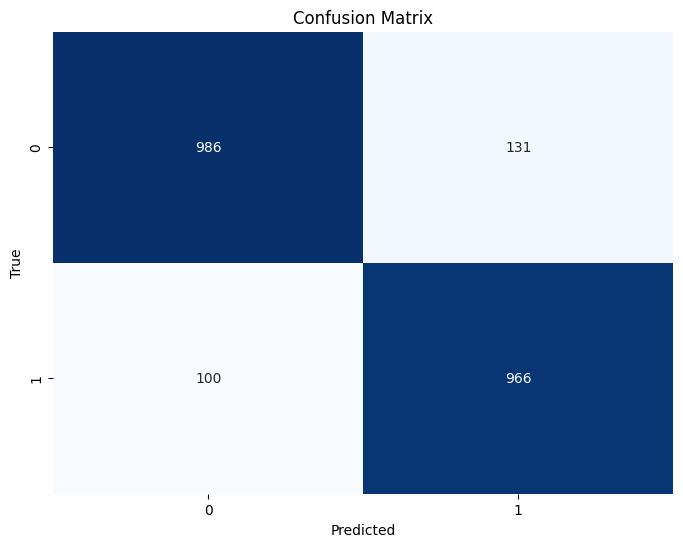

{'accuracy': 0.8941823179111315,
 'macro_f1': 0.8941734351656392,
 'weighted_f1': 0.8941960861666446,
 'precision': 0.8942511889952676,
 'recall': 0.8944564726275319,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.91      0.88      0.90      1117\n           1       0.88      0.91      0.89      1066\n\n    accuracy                           0.89      2183\n   macro avg       0.89      0.89      0.89      2183\nweighted avg       0.89      0.89      0.89      2183\n'}

In [88]:
pred_output = trainer_sent.predict(test_ds_sent)
compute_metrics((pred_output.predictions, pred_output.label_ids))


### Basic Sarcasm Model with Roberta

In [89]:
model_sarcasm = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(train_df["Sarcasm"].unique()),
    problem_type="single_label_classification"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [90]:
training_args = TrainingArguments(
      output_dir = "./sarcasm_results",
      weight_decay = 0.001,
      num_train_epochs = 3,
      learning_rate = 2e-5,
      eval_strategy = "epoch",
      save_strategy = "epoch",
      per_device_train_batch_size = 8,
      per_device_eval_batch_size = 8,
      report_to="none"
)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.486143,0.859425,0.462199,0.794451,0.429712,0.500000,precision recall f1-score support 0 0.86 1.00 0.92 269 1 0.00 0.00 0.00 44 accuracy 0.86 313 macro avg 0.43 0.50 0.46 313 weighted avg 0.74 0.86 0.79 313
2,0.395683,0.367881,0.872204,0.594665,0.835771,0.788944,0.573969,precision recall f1-score support 0 0.88 0.99 0.93 269 1 0.70 0.16 0.26 44 accuracy 0.87 313 macro avg 0.79 0.57 0.59 313 weighted avg 0.85 0.87 0.84 313
3,0.377703,0.389298,0.840256,0.607651,0.824813,0.638534,0.593401,precision recall f1-score support 0 0.88 0.94 0.91 269 1 0.39 0.25 0.31 44 accuracy 0.84 313 macro avg 0.64 0.59 0.61 313 weighted avg 0.82 0.84 0.82 313


Accuracy: 0.8594249201277955
Macro F1: 0.46219931271477666
Weighted F1: 0.7944512148260379
Precision: 0.42971246006389774
Recall: 0.5
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       269
           1       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



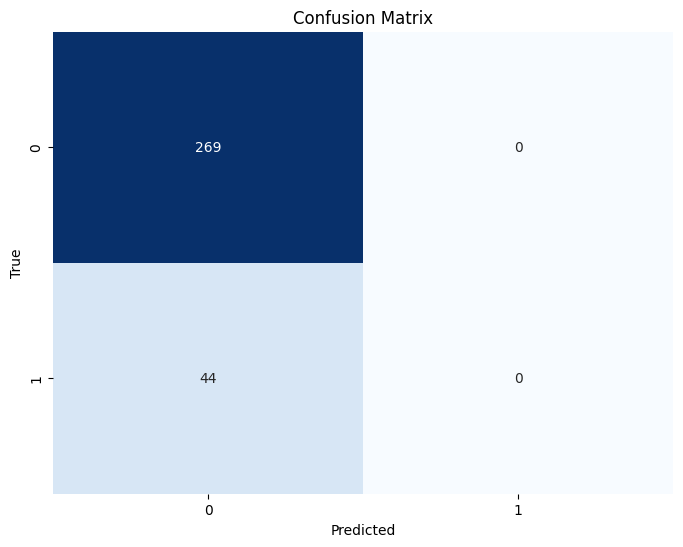

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8722044728434505
Macro F1: 0.5946645946645946
Weighted F1: 0.8357706664415929
Precision: 0.7889438943894389
Recall: 0.5739692463670159
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       269
           1       0.70      0.16      0.26        44

    accuracy                           0.87       313
   macro avg       0.79      0.57      0.59       313
weighted avg       0.85      0.87      0.84       313



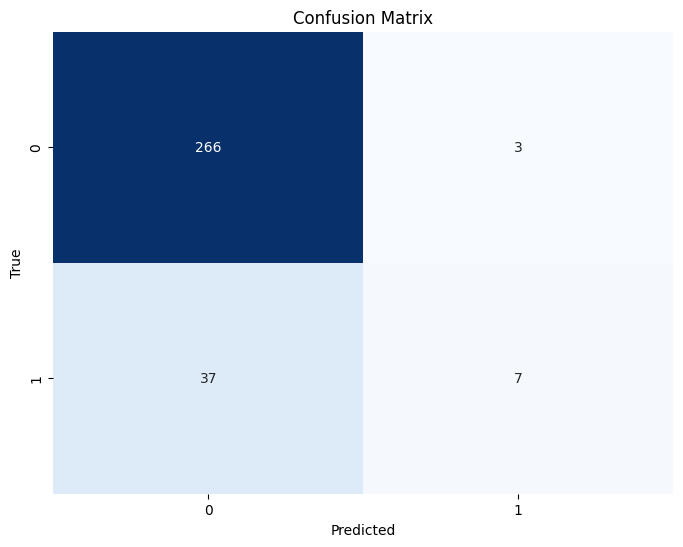

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8402555910543131
Macro F1: 0.6076514239871641
Weighted F1: 0.8248129907510999
Precision: 0.6385338345864662
Recall: 0.5934014869888475
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       269
           1       0.39      0.25      0.31        44

    accuracy                           0.84       313
   macro avg       0.64      0.59      0.61       313
weighted avg       0.82      0.84      0.82       313



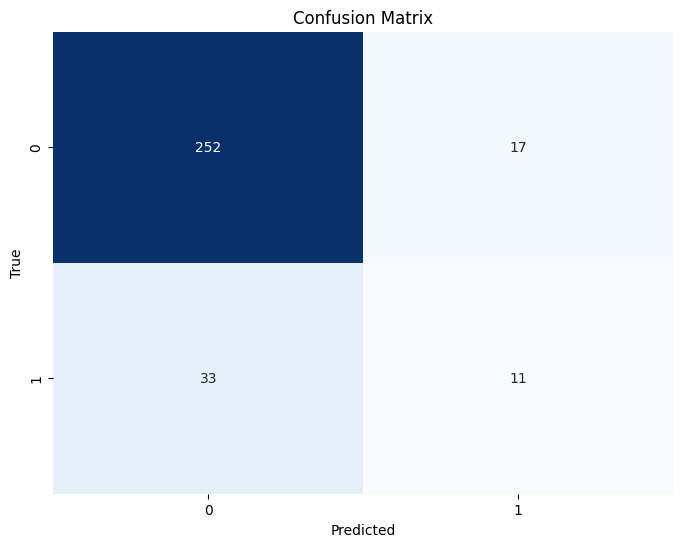

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1407, training_loss=0.36889710253489805, metrics={'train_runtime': 339.8055, 'train_samples_per_second': 33.081, 'train_steps_per_second': 4.141, 'total_flos': 879828980238000.0, 'train_loss': 0.36889710253489805, 'epoch': 3.0})

In [91]:
trainer_sarcasm = Trainer(
    model=model_sarcasm,
    args=training_args,
    train_dataset=train_ds_sarc,
    eval_dataset=val_ds_sarc,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)
trainer_sarcasm.train()

Accuracy: 0.8579935868071461
Macro F1: 0.6318053415511042
Weighted F1: 0.8397504670845665
Precision: 0.6869594145043246
Recall: 0.6098901866303532
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1878
           1       0.49      0.27      0.34       305

    accuracy                           0.86      2183
   macro avg       0.69      0.61      0.63      2183
weighted avg       0.83      0.86      0.84      2183



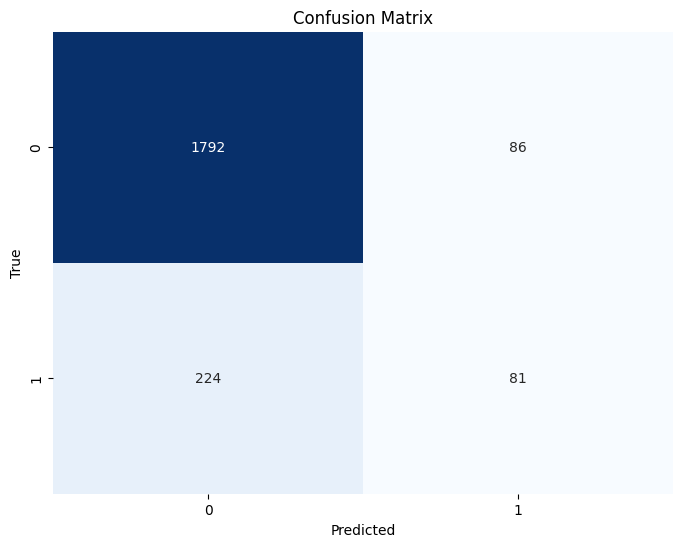

Accuracy: 0.8579935868071461
Macro F1: 0.6318053415511042
Weighted F1: 0.8397504670845665
Precision: 0.6869594145043246
Recall: 0.6098901866303532
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1878
           1       0.49      0.27      0.34       305

    accuracy                           0.86      2183
   macro avg       0.69      0.61      0.63      2183
weighted avg       0.83      0.86      0.84      2183



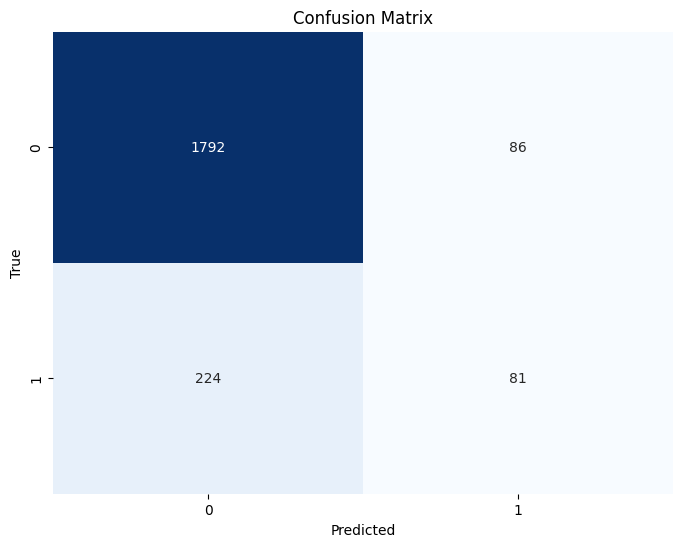

{'accuracy': 0.8579935868071461,
 'macro_f1': 0.6318053415511042,
 'weighted_f1': 0.8397504670845665,
 'precision': 0.6869594145043246,
 'recall': 0.6098901866303532,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.89      0.95      0.92      1878\n           1       0.49      0.27      0.34       305\n\n    accuracy                           0.86      2183\n   macro avg       0.69      0.61      0.63      2183\nweighted avg       0.83      0.86      0.84      2183\n'}

In [92]:
pred_output = trainer_sarcasm.predict(test_ds_sarc)
compute_metrics((pred_output.predictions, pred_output.label_ids))


### Fine tuning the model

In [93]:

def find_best_config_from_grid(candidate_config, train_dataset, val_dataset):
    results = []
    for config in candidate_config:
        print(config)
        print(f"Running: lr={config['learning_rate']}, bs={config['batch_size']}, epochs={config['num_train_epochs']}, wd={config['weight_decay']}")

        set_seed(42)

        model = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base",
            num_labels=2
        )


        training_args = TrainingArguments(
            output_dir=f"./results/lr_{config['learning_rate']}_bs_{config['batch_size']}_ep_{config['num_train_epochs']}",
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            fp16=torch.cuda.is_available(),
            dataloader_pin_memory=True,
            learning_rate=config['learning_rate'],
            per_device_train_batch_size=config['batch_size'],
            per_device_eval_batch_size=config['batch_size'],
            num_train_epochs=config['num_train_epochs'],
            weight_decay=config['weight_decay'],
            seed=42,
            warmup_ratio=0.1,
            lr_scheduler_type="linear"
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            processing_class=tokenizer,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
        )

        trainer.train()

        pred_output = trainer.predict(val_dataset)
        eval_result = compute_metrics((pred_output.predictions, pred_output.label_ids))


        results.append({
            "learning_rate": config['learning_rate'],
            "batch_size": config['batch_size'],
            "num_train_epochs": config['num_train_epochs'],
            "weight_decay": config['weight_decay'],
            "accuracy": eval_result["accuracy"],
            "macro_f1": eval_result["macro_f1"],
            "weighted_f1": eval_result["weighted_f1"],
            "precision": eval_result["precision"],
            "recall": eval_result["recall"]
        })

        del model
        torch.cuda.empty_cache()


    return results


In [94]:
candidate_configs = [
    {'learning_rate': 1e-5, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 1e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 1e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01},
    {'learning_rate': 2e-5, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.0},
    {'learning_rate': 2e-5, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 2e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 2e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.0},
    {'learning_rate': 3e-5, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 3e-5, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01},

    {'learning_rate': 1e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 1e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 1e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01},
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.0},
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.0},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01},

]

{'learning_rate': 1e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=1e-05, bs=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.265544,0.916933,0.916912,0.916882,0.918776,0.917749,precision recall f1-score support 0 0.95 0.88 0.92 160 1 0.88 0.95 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,0.433610,0.304726,0.916933,0.916925,0.916943,0.916973,0.917177,precision recall f1-score support 0 0.93 0.91 0.92 160 1 0.90 0.93 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.9169329073482428
Macro F1: 0.9169117046475537
Weighted F1: 0.9168820208665889
Precision: 0.9187755937755938
Recall: 0.917749183006536
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92       160
           1       0.88      0.95      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



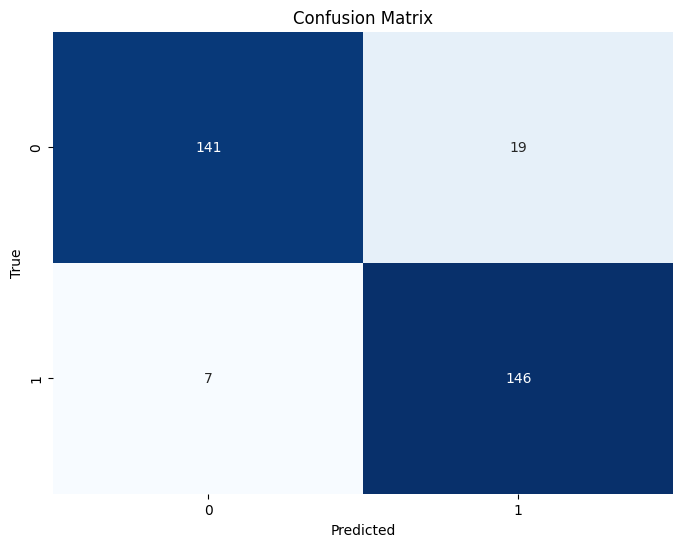

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9169329073482428
Macro F1: 0.9169252756227031
Weighted F1: 0.9169430829822958
Precision: 0.9169728891066471
Recall: 0.9171772875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.90      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



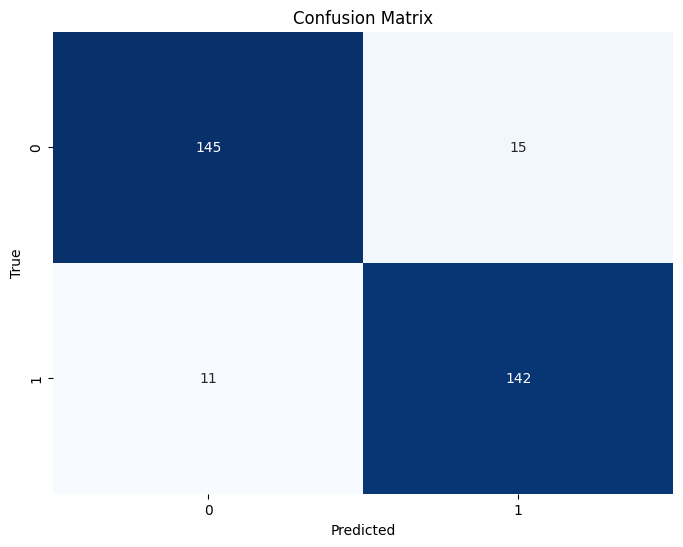

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9169329073482428
Macro F1: 0.9169252756227031
Weighted F1: 0.9169430829822958
Precision: 0.9169728891066471
Recall: 0.9171772875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.90      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



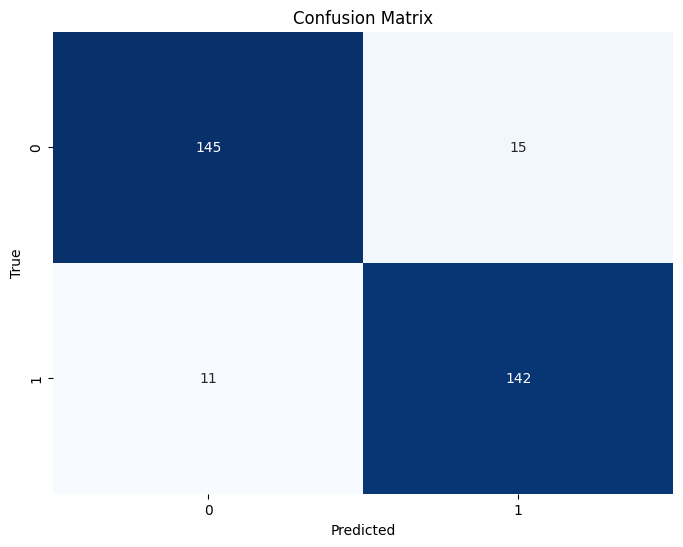

Accuracy: 0.9169329073482428
Macro F1: 0.9169252756227031
Weighted F1: 0.9169430829822958
Precision: 0.9169728891066471
Recall: 0.9171772875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.90      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



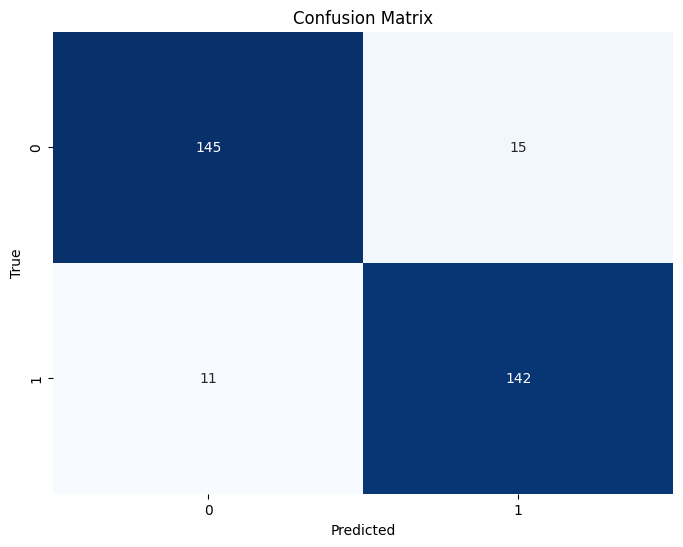

{'learning_rate': 1e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=1e-05, bs=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.225147,0.916933,0.916925,0.916943,0.916973,0.917177,precision recall f1-score support 0 0.93 0.91 0.92 160 1 0.90 0.93 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,0.429775,0.230069,0.926518,0.926506,0.926485,0.928037,0.927267,precision recall f1-score support 0 0.96 0.89 0.93 160 1 0.90 0.96 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
3,0.264323,0.282899,0.926518,0.926470,0.926512,0.926549,0.926409,precision recall f1-score support 0 0.93 0.93 0.93 160 1 0.93 0.92 0.92 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9169329073482428
Macro F1: 0.9169252756227031
Weighted F1: 0.9169430829822958
Precision: 0.9169728891066471
Recall: 0.9171772875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.90      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



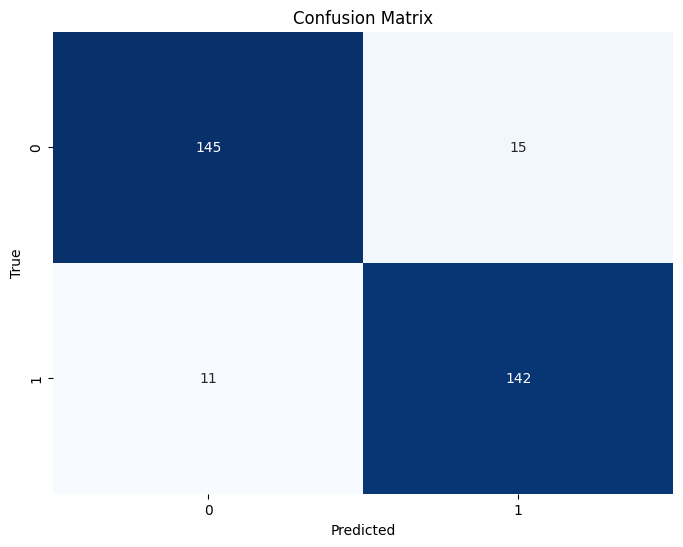

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9264845639440628
Precision: 0.9280365035193976
Recall: 0.9272671568627451
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       160
           1       0.90      0.96      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



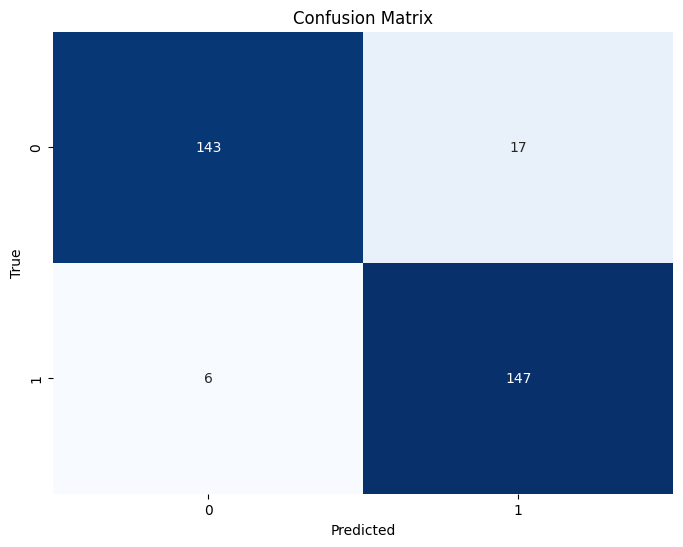

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9265175718849841
Macro F1: 0.9264695367958735
Weighted F1: 0.9265115674988453
Precision: 0.9265487087283426
Recall: 0.9264093137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       160
           1       0.93      0.92      0.92       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



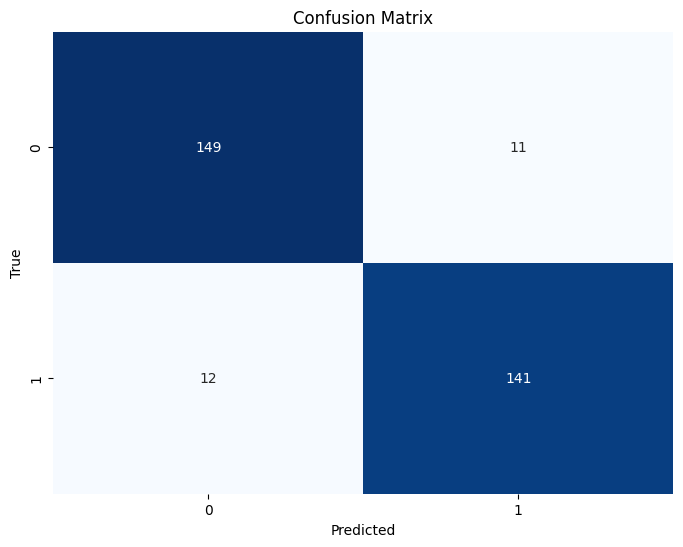

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9264845639440628
Precision: 0.9280365035193976
Recall: 0.9272671568627451
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       160
           1       0.90      0.96      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



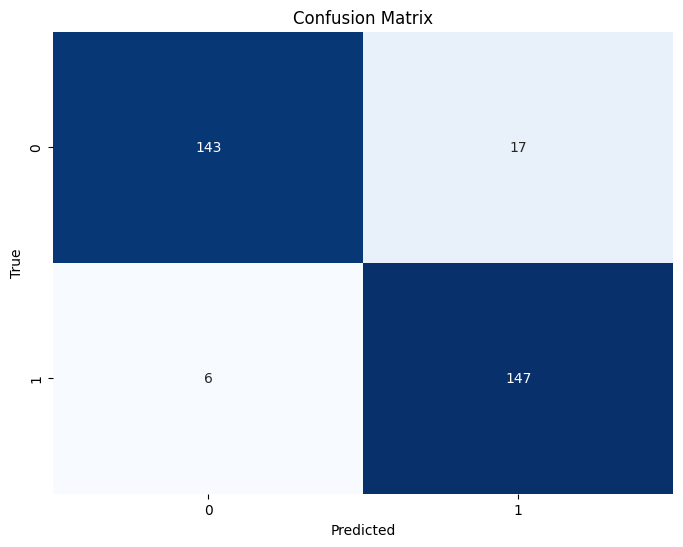

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9264845639440628
Precision: 0.9280365035193976
Recall: 0.9272671568627451
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       160
           1       0.90      0.96      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



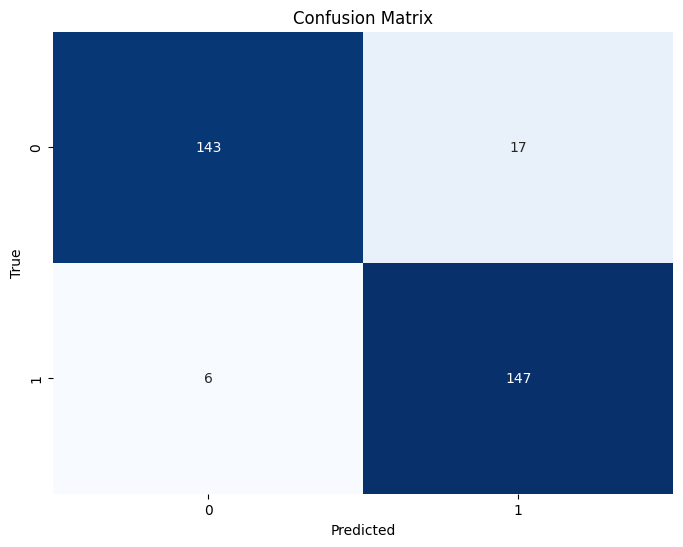

{'learning_rate': 1e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=1e-05, bs=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.210373,0.923323,0.923303,0.923331,0.923254,0.923427,precision recall f1-score support 0 0.93 0.92 0.92 160 1 0.92 0.93 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,0.436522,0.257871,0.920128,0.920046,0.919989,0.924249,0.921303,precision recall f1-score support 0 0.97 0.87 0.92 160 1 0.88 0.97 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.93 0.92 0.92 313


Accuracy: 0.9233226837060703
Macro F1: 0.9233031119823573
Weighted F1: 0.9233305123955555
Precision: 0.9232543895467538
Recall: 0.9234272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       160
           1       0.92      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



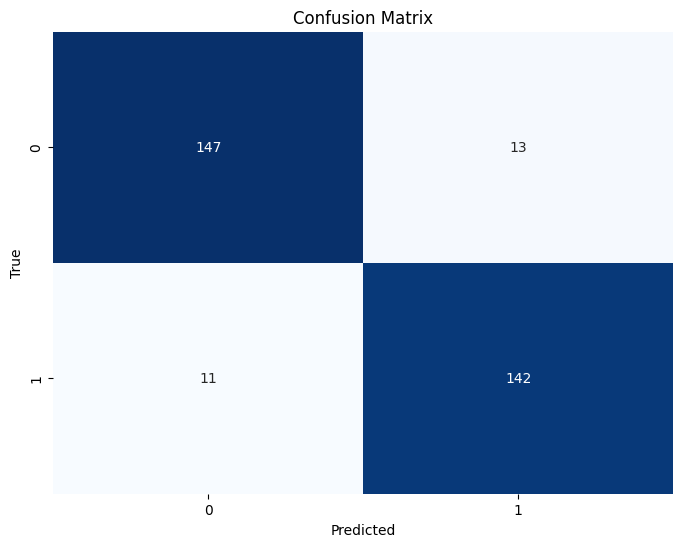

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.920046184184982
Weighted F1: 0.9199890562454598
Precision: 0.9242492801316331
Recall: 0.9213031045751634
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       160
           1       0.88      0.97      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.93      0.92      0.92       313



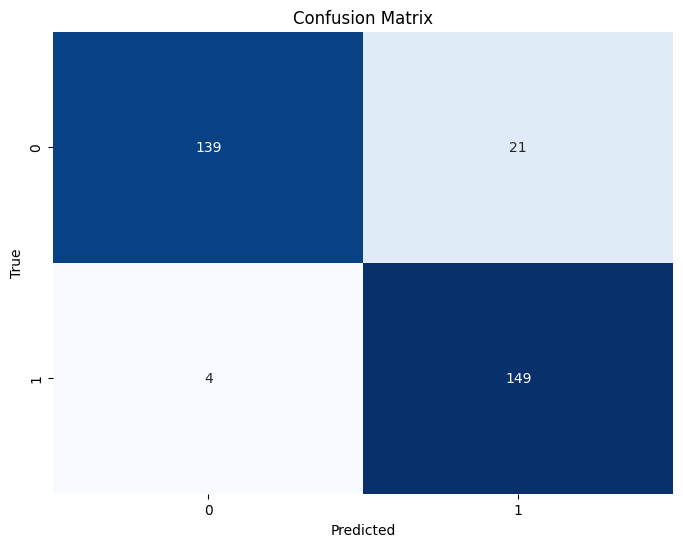

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9233226837060703
Macro F1: 0.9233031119823573
Weighted F1: 0.9233305123955555
Precision: 0.9232543895467538
Recall: 0.9234272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       160
           1       0.92      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



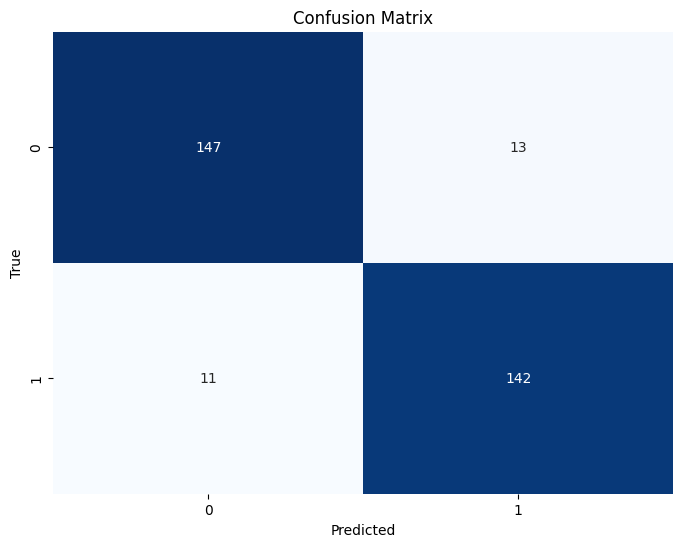

Accuracy: 0.9233226837060703
Macro F1: 0.9233031119823573
Weighted F1: 0.9233305123955555
Precision: 0.9232543895467538
Recall: 0.9234272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       160
           1       0.92      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



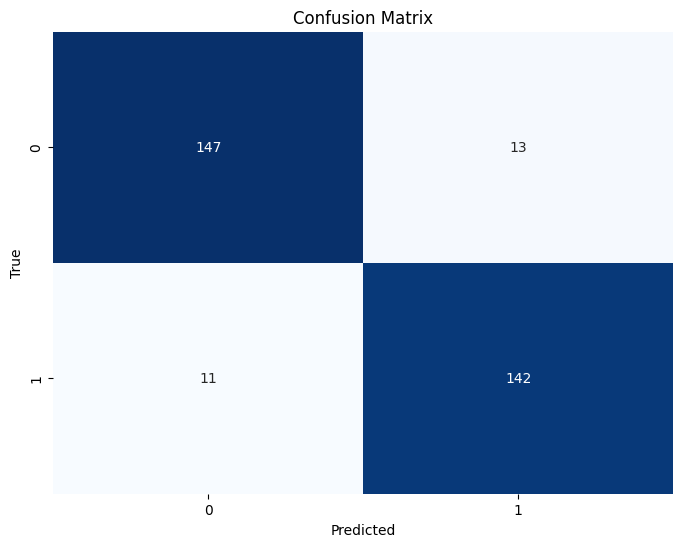

{'learning_rate': 2e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.0}
Running: lr=2e-05, bs=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.241878,0.916933,0.916932,0.916926,0.917600,0.917463,precision recall f1-score support 0 0.94 0.89 0.92 160 1 0.89 0.94 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,0.430276,0.246093,0.932907,0.932839,0.932887,0.933190,0.932659,precision recall f1-score support 0 0.93 0.94 0.93 160 1 0.94 0.92 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9169329073482428
Macro F1: 0.9169320594479831
Weighted F1: 0.9169261241461645
Precision: 0.9175997057862046
Recall: 0.9174632352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       160
           1       0.89      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



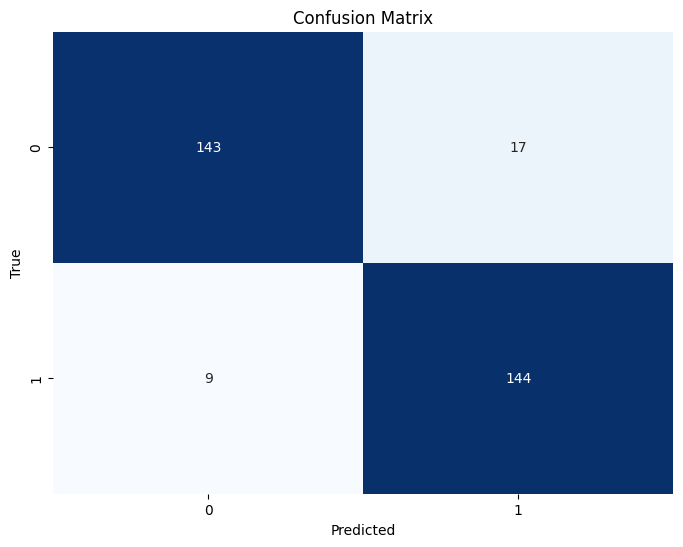

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9329073482428115
Macro F1: 0.9328387947153849
Weighted F1: 0.9328867821845835
Precision: 0.9331901840490797
Recall: 0.9326593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.94      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



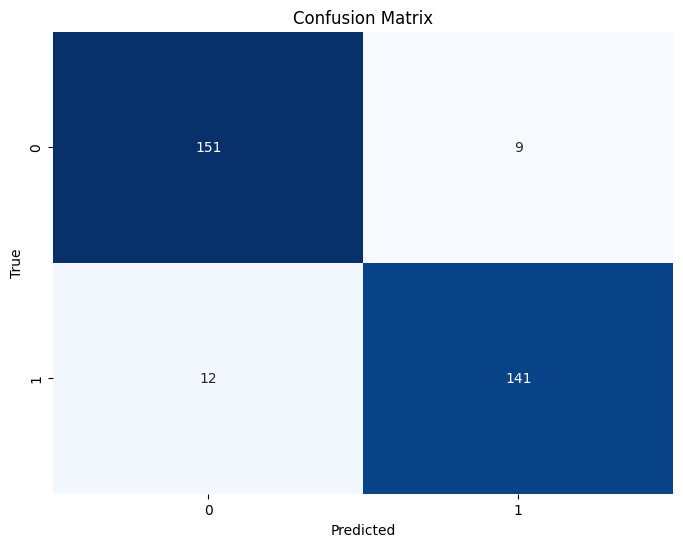

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9329073482428115
Macro F1: 0.9328387947153849
Weighted F1: 0.9328867821845835
Precision: 0.9331901840490797
Recall: 0.9326593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.94      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



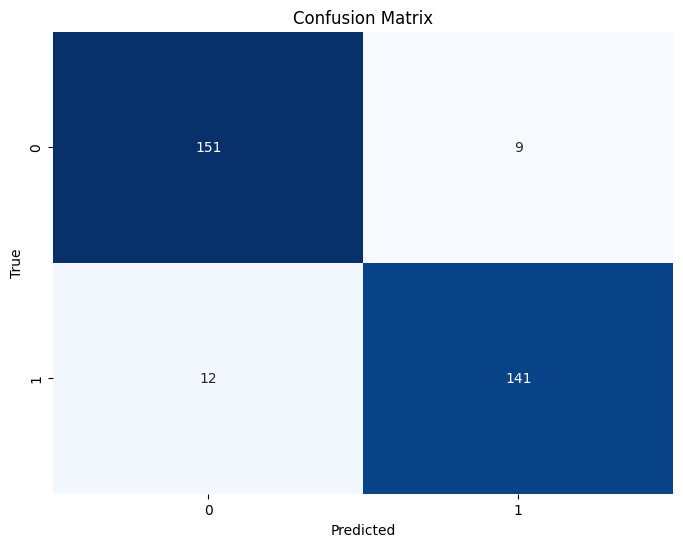

Accuracy: 0.9329073482428115
Macro F1: 0.9328387947153849
Weighted F1: 0.9328867821845835
Precision: 0.9331901840490797
Recall: 0.9326593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.94      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



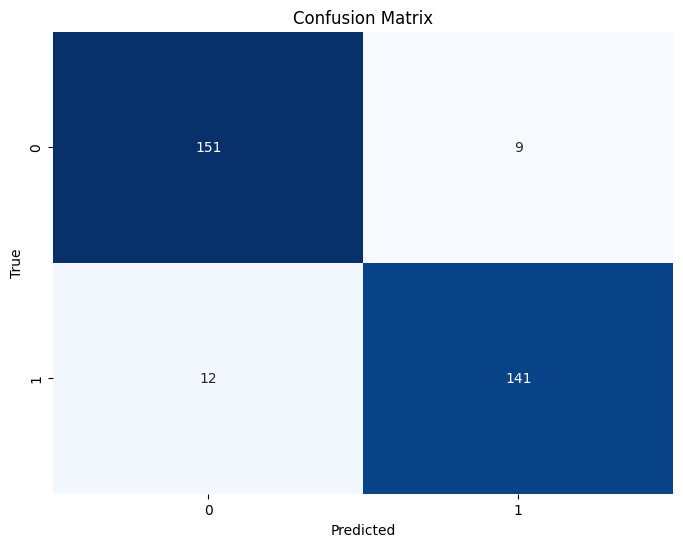

{'learning_rate': 2e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=2e-05, bs=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.241887,0.900958,0.900954,0.900940,0.901848,0.901552,precision recall f1-score support 0 0.93 0.88 0.90 160 1 0.88 0.93 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.90 0.90 0.90 313
2,0.452151,0.226478,0.932907,0.932863,0.932902,0.932944,0.932802,precision recall f1-score support 0 0.93 0.94 0.93 160 1 0.93 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9009584664536742
Macro F1: 0.9009544224978309
Weighted F1: 0.9009402686523795
Precision: 0.9018477638786689
Recall: 0.9015522875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       160
           1       0.88      0.93      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.90      0.90      0.90       313



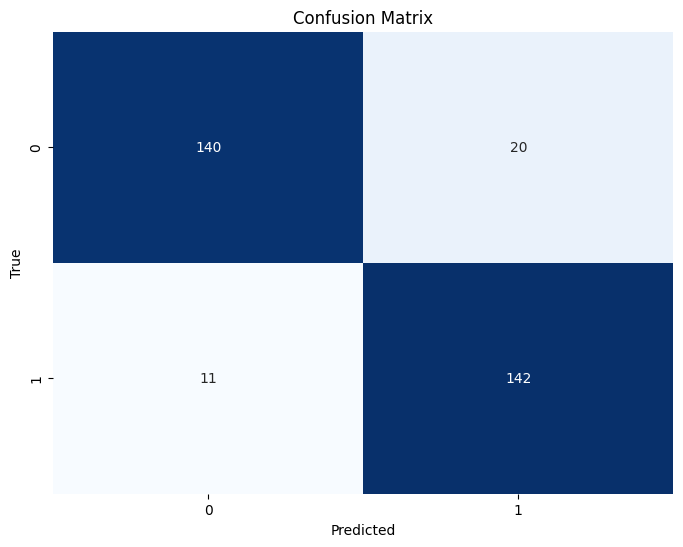

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9329073482428115
Macro F1: 0.9328634901179715
Weighted F1: 0.9329018659772066
Precision: 0.932943772474665
Recall: 0.9328022875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



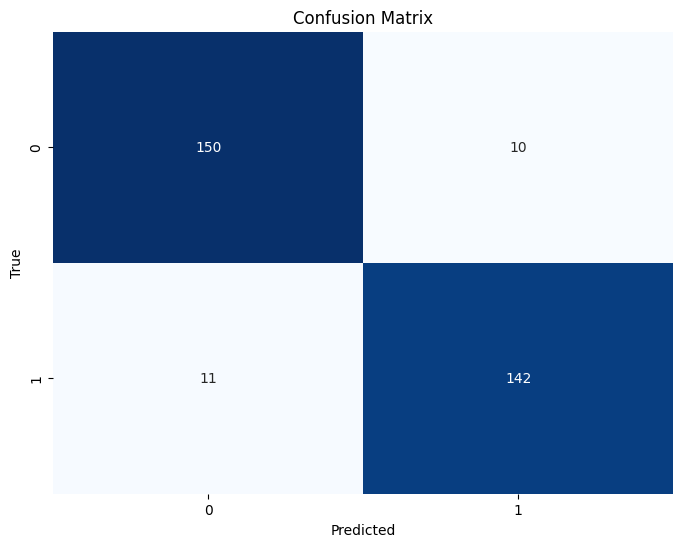

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9329073482428115
Macro F1: 0.9328634901179715
Weighted F1: 0.9329018659772066
Precision: 0.932943772474665
Recall: 0.9328022875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



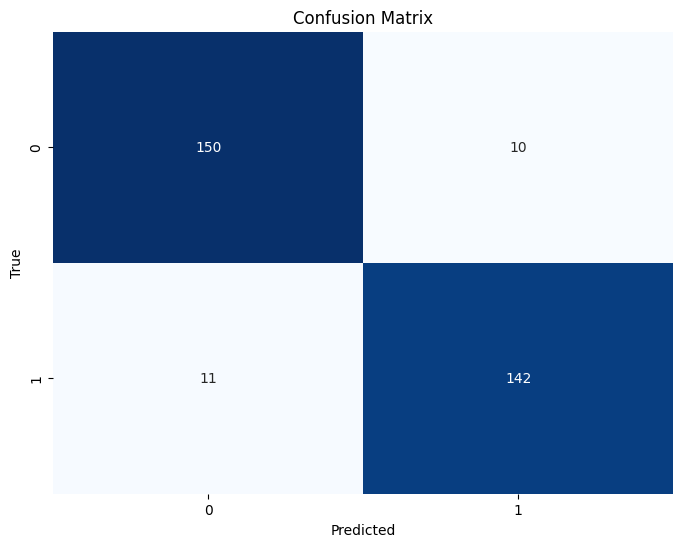

Accuracy: 0.9329073482428115
Macro F1: 0.9328634901179715
Weighted F1: 0.9329018659772066
Precision: 0.932943772474665
Recall: 0.9328022875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



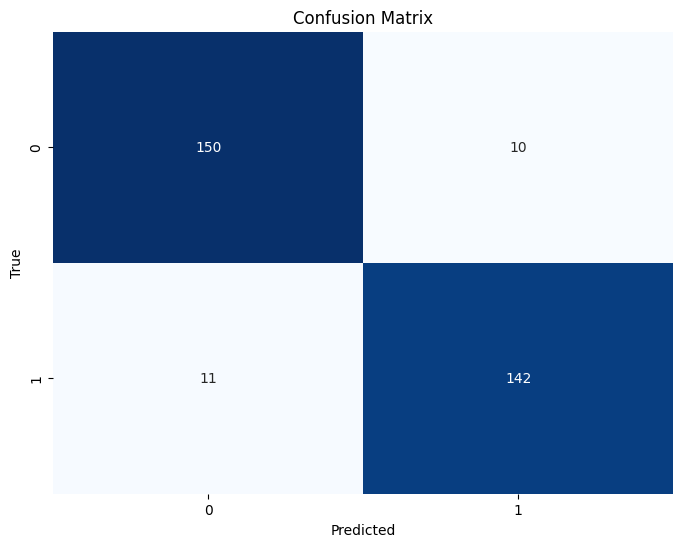

{'learning_rate': 2e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=2e-05, bs=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.463044,0.843450,0.841109,0.840677,0.872617,0.846589,precision recall f1-score support 0 0.98 0.71 0.82 160 1 0.76 0.99 0.86 153 accuracy 0.84 313 macro avg 0.87 0.85 0.84 313 weighted avg 0.88 0.84 0.84 313
2,0.439794,0.321508,0.904153,0.904074,0.904012,0.907647,0.905249,precision recall f1-score support 0 0.95 0.86 0.90 160 1 0.86 0.95 0.91 153 accuracy 0.90 313 macro avg 0.91 0.91 0.90 313 weighted avg 0.91 0.90 0.90 313
3,0.283389,0.256542,0.936102,0.936023,0.936074,0.936569,0.935784,precision recall f1-score support 0 0.93 0.95 0.94 160 1 0.95 0.92 0.93 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.8434504792332268
Macro F1: 0.8411085211085211
Weighted F1: 0.8406771077697596
Precision: 0.8726174791392183
Recall: 0.8465890522875817
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.71      0.82       160
           1       0.76      0.99      0.86       153

    accuracy                           0.84       313
   macro avg       0.87      0.85      0.84       313
weighted avg       0.88      0.84      0.84       313



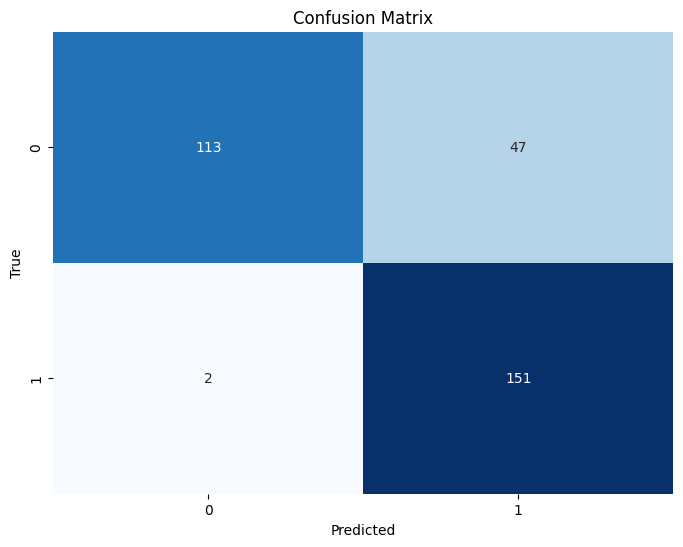

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9041533546325878
Macro F1: 0.9040740438051651
Weighted F1: 0.9040123576060585
Precision: 0.9076471071663379
Recall: 0.9052491830065359
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       160
           1       0.86      0.95      0.91       153

    accuracy                           0.90       313
   macro avg       0.91      0.91      0.90       313
weighted avg       0.91      0.90      0.90       313



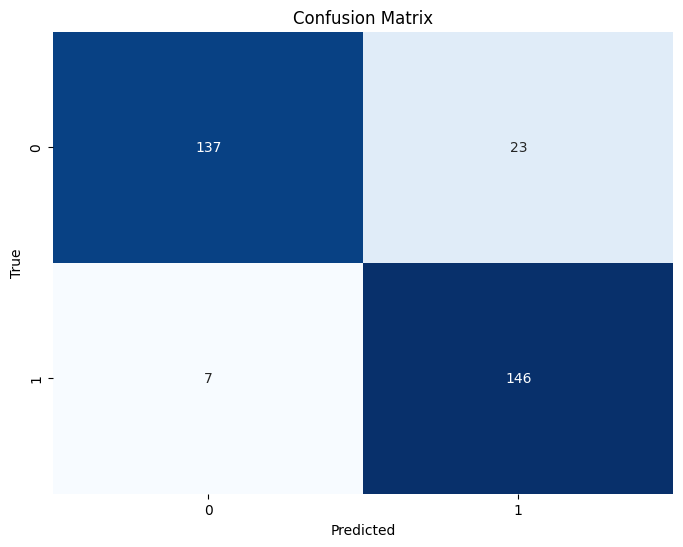

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9361022364217252
Macro F1: 0.9360232196876788
Weighted F1: 0.9360735030638901
Precision: 0.9365689965624489
Recall: 0.9357843137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       160
           1       0.95      0.92      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



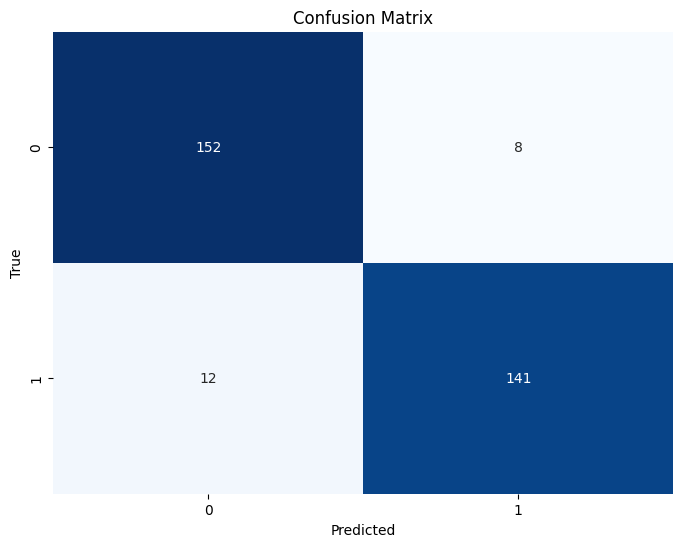

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9361022364217252
Macro F1: 0.9360232196876788
Weighted F1: 0.9360735030638901
Precision: 0.9365689965624489
Recall: 0.9357843137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       160
           1       0.95      0.92      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



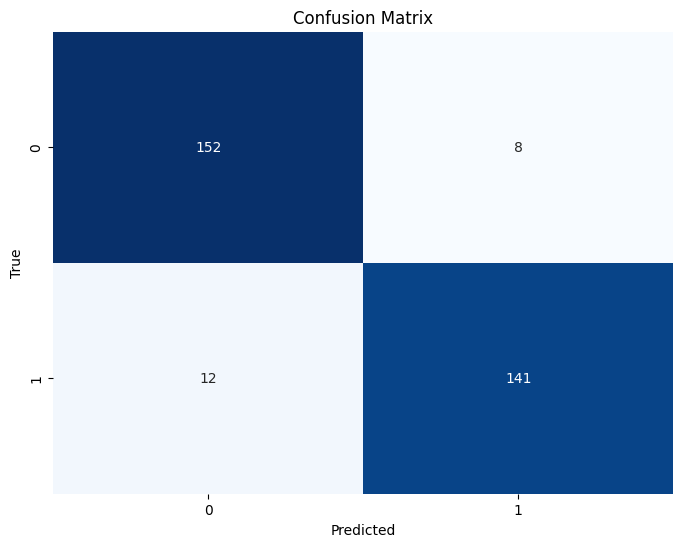

Accuracy: 0.9361022364217252
Macro F1: 0.9360232196876788
Weighted F1: 0.9360735030638901
Precision: 0.9365689965624489
Recall: 0.9357843137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       160
           1       0.95      0.92      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



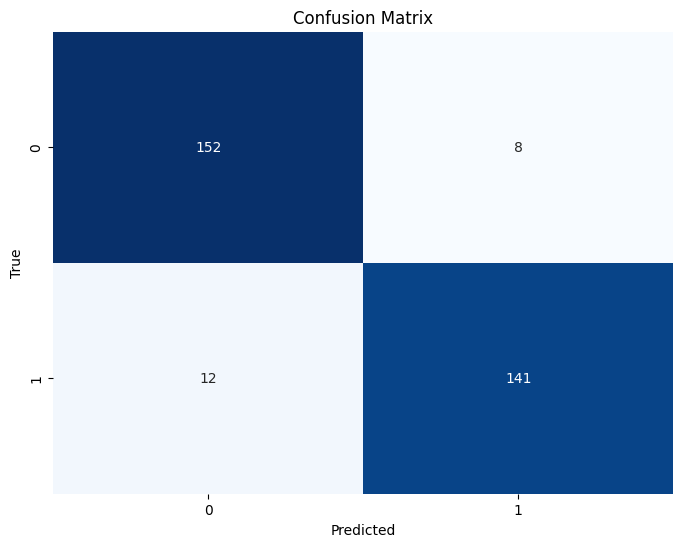

{'learning_rate': 2e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=2e-05, bs=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.221623,0.913738,0.913734,0.913747,0.913883,0.914052,precision recall f1-score support 0 0.93 0.90 0.91 160 1 0.90 0.93 0.91 153 accuracy 0.91 313 macro avg 0.91 0.91 0.91 313 weighted avg 0.91 0.91 0.91 313
2,0.425461,0.307725,0.904153,0.904152,0.904146,0.904810,0.904677,precision recall f1-score support 0 0.93 0.88 0.90 160 1 0.88 0.93 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.91 0.90 0.90 313


Accuracy: 0.9137380191693291
Macro F1: 0.9137344970142398
Weighted F1: 0.9137468245570523
Precision: 0.913883217639853
Recall: 0.9140522875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       160
           1       0.90      0.93      0.91       153

    accuracy                           0.91       313
   macro avg       0.91      0.91      0.91       313
weighted avg       0.91      0.91      0.91       313



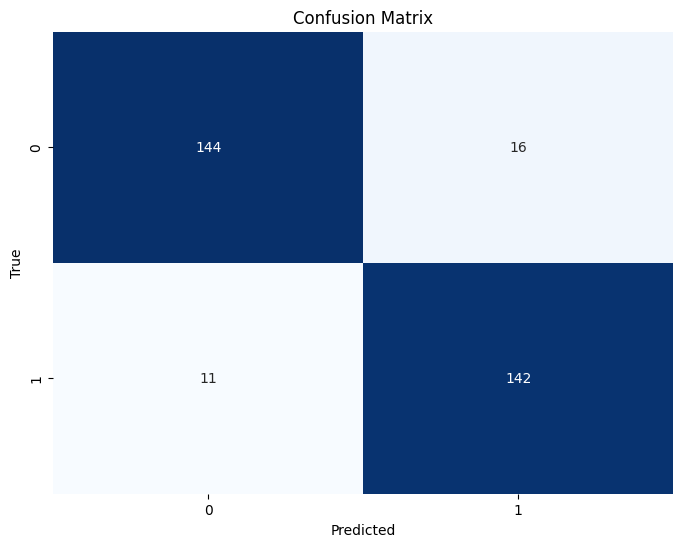

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9041533546325878
Macro F1: 0.9041523762861343
Weighted F1: 0.9041455278609589
Precision: 0.90480957829356
Recall: 0.9046772875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       160
           1       0.88      0.93      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.91      0.90      0.90       313



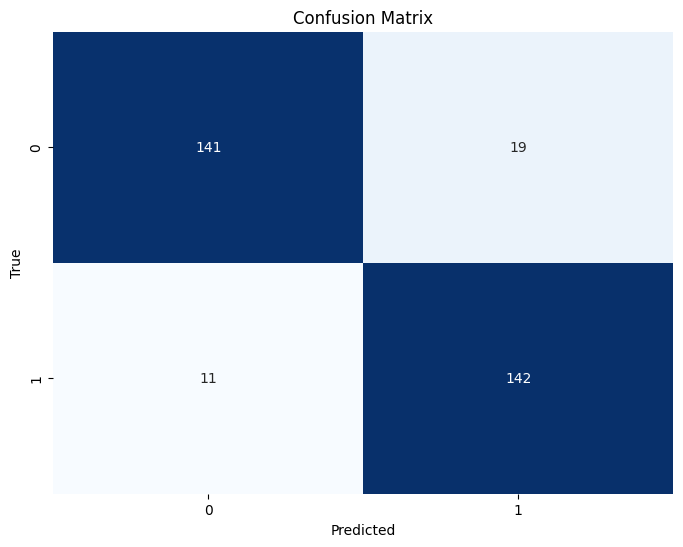

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9137380191693291
Macro F1: 0.9137344970142398
Weighted F1: 0.9137468245570523
Precision: 0.913883217639853
Recall: 0.9140522875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       160
           1       0.90      0.93      0.91       153

    accuracy                           0.91       313
   macro avg       0.91      0.91      0.91       313
weighted avg       0.91      0.91      0.91       313



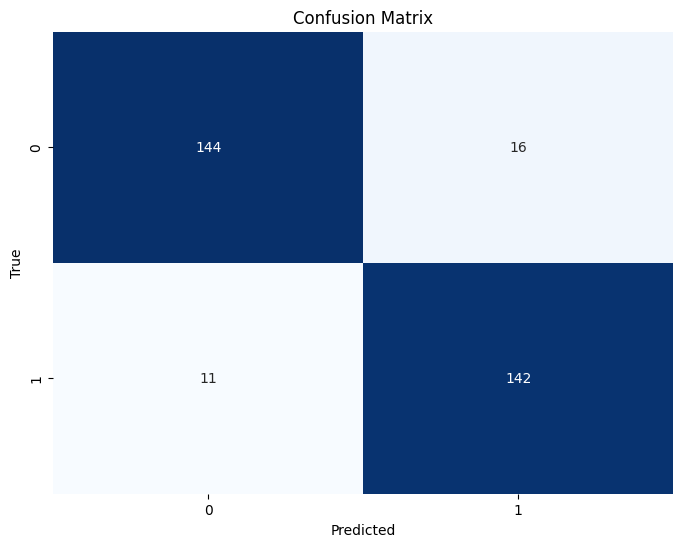

Accuracy: 0.9137380191693291
Macro F1: 0.9137344970142398
Weighted F1: 0.9137468245570523
Precision: 0.913883217639853
Recall: 0.9140522875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       160
           1       0.90      0.93      0.91       153

    accuracy                           0.91       313
   macro avg       0.91      0.91      0.91       313
weighted avg       0.91      0.91      0.91       313



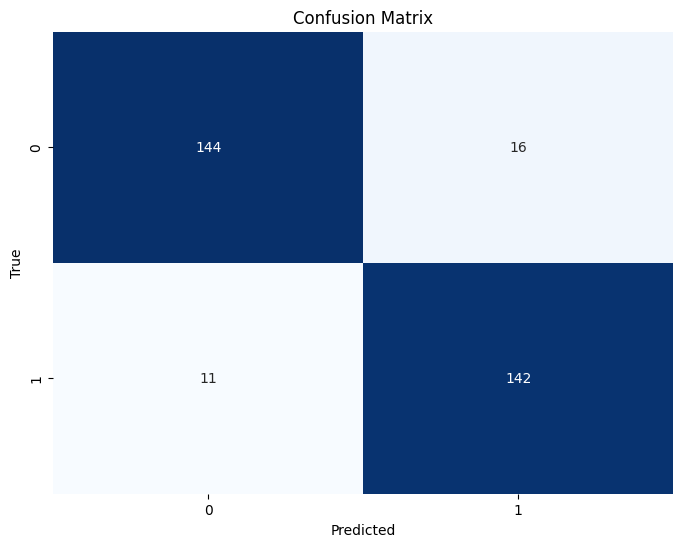

{'learning_rate': 3e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.0}
Running: lr=3e-05, bs=8, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.399581,0.846645,0.844704,0.844315,0.871904,0.849571,precision recall f1-score support 0 0.97 0.72 0.83 160 1 0.77 0.98 0.86 153 accuracy 0.85 313 macro avg 0.87 0.85 0.84 313 weighted avg 0.87 0.85 0.84 313
2,0.435124,0.250295,0.936102,0.936049,0.936090,0.936248,0.935927,precision recall f1-score support 0 0.93 0.94 0.94 160 1 0.94 0.93 0.93 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.8466453674121406
Macro F1: 0.8447035475068221
Weighted F1: 0.8443151835257585
Precision: 0.871903520208605
Recall: 0.8495710784313726
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       160
           1       0.77      0.98      0.86       153

    accuracy                           0.85       313
   macro avg       0.87      0.85      0.84       313
weighted avg       0.87      0.85      0.84       313



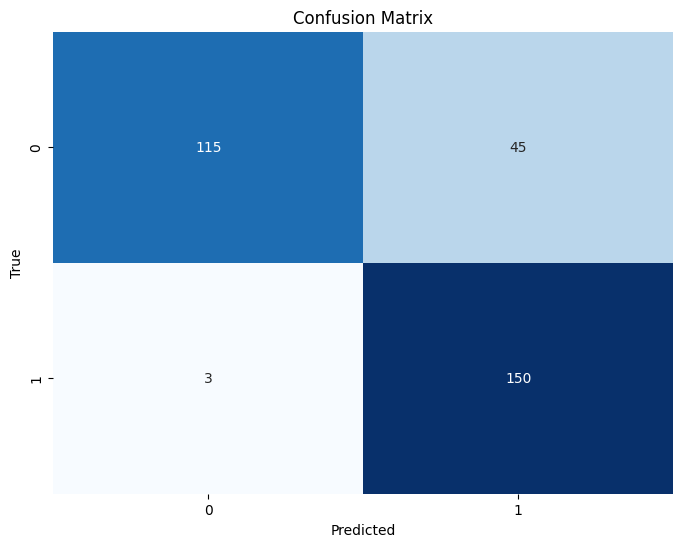

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9361022364217252
Macro F1: 0.9360493625367767
Weighted F1: 0.9360904866695144
Precision: 0.9362480582127382
Recall: 0.9359272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       160
           1       0.94      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



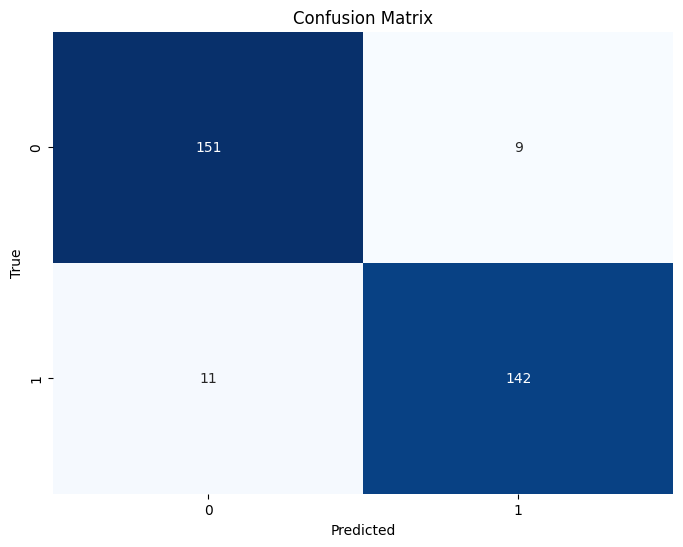

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9361022364217252
Macro F1: 0.9360493625367767
Weighted F1: 0.9360904866695144
Precision: 0.9362480582127382
Recall: 0.9359272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       160
           1       0.94      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



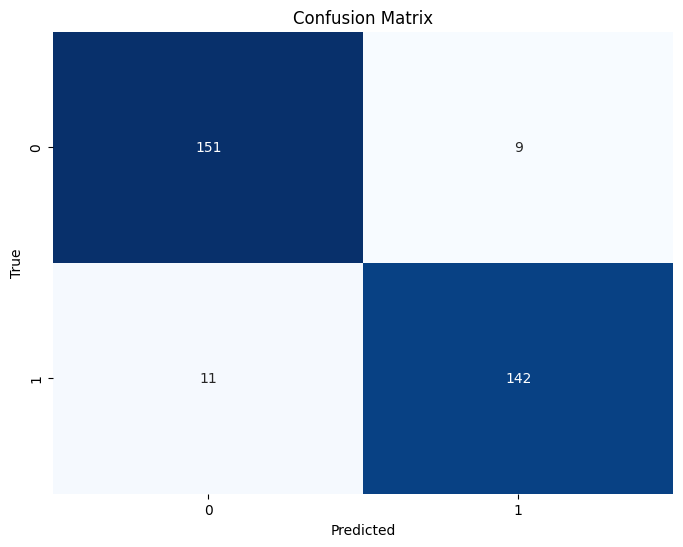

Accuracy: 0.9361022364217252
Macro F1: 0.9360493625367767
Weighted F1: 0.9360904866695144
Precision: 0.9362480582127382
Recall: 0.9359272875816993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       160
           1       0.94      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



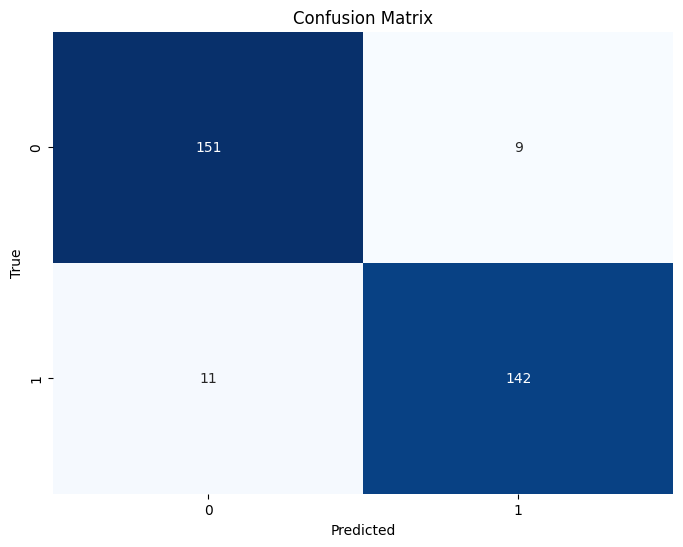

{'learning_rate': 3e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=3e-05, bs=8, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.316572,0.897764,0.897528,0.897418,0.904741,0.899285,precision recall f1-score support 0 0.96 0.83 0.89 160 1 0.85 0.97 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.91 0.90 0.90 313
2,0.447782,0.265515,0.920128,0.920098,0.920133,0.920056,0.920159,precision recall f1-score support 0 0.92 0.92 0.92 160 1 0.92 0.92 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.8977635782747604
Macro F1: 0.8975282370273368
Weighted F1: 0.8974184111118724
Precision: 0.9047412008281573
Recall: 0.8992851307189542
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       160
           1       0.85      0.97      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.91      0.90      0.90       313



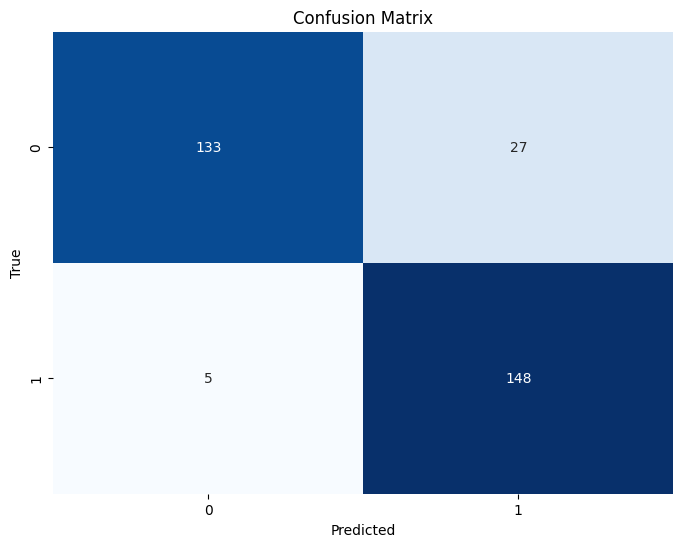

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



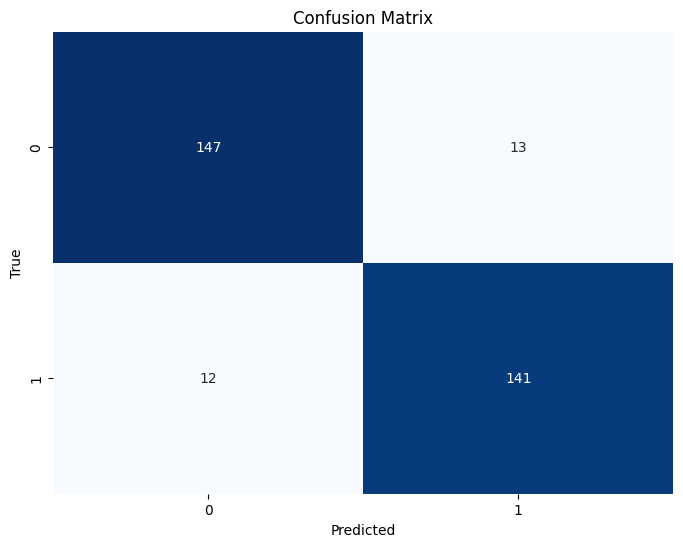

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



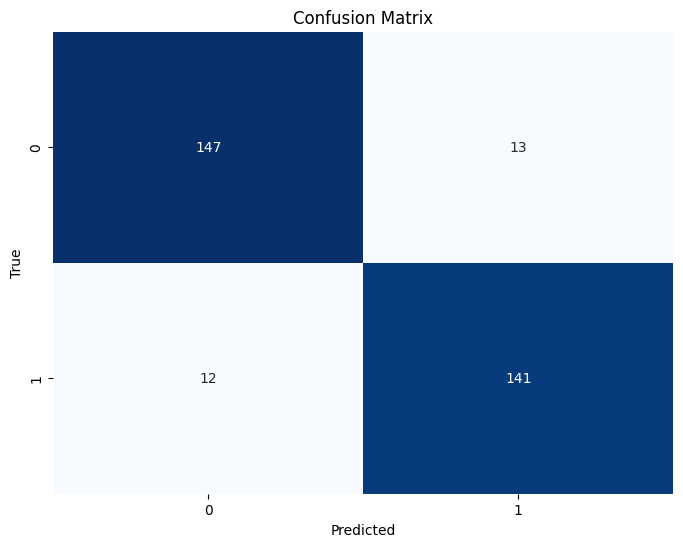

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



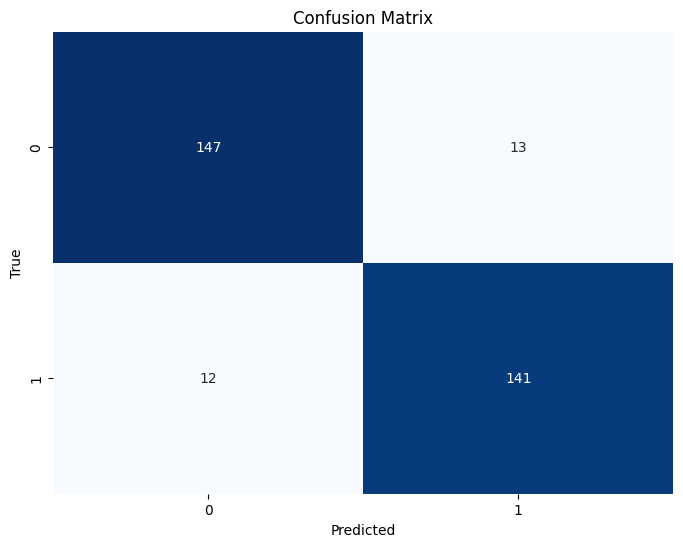

{'learning_rate': 3e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=3e-05, bs=8, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.355859,0.849840,0.848047,0.847678,0.873993,0.852696,precision recall f1-score support 0 0.97 0.72 0.83 160 1 0.77 0.98 0.86 153 accuracy 0.85 313 macro avg 0.87 0.85 0.85 313 weighted avg 0.88 0.85 0.85 313
2,0.450855,0.268449,0.926518,0.926515,0.926525,0.926664,0.926838,precision recall f1-score support 0 0.94 0.91 0.93 160 1 0.91 0.94 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
3,0.269766,0.239534,0.936102,0.936086,0.936109,0.936035,0.936213,precision recall f1-score support 0 0.94 0.93 0.94 160 1 0.93 0.94 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.8498402555910544
Macro F1: 0.8480472663795151
Weighted F1: 0.8476781215418453
Precision: 0.8739928961275232
Recall: 0.8526960784313725
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       160
           1       0.77      0.98      0.86       153

    accuracy                           0.85       313
   macro avg       0.87      0.85      0.85       313
weighted avg       0.88      0.85      0.85       313



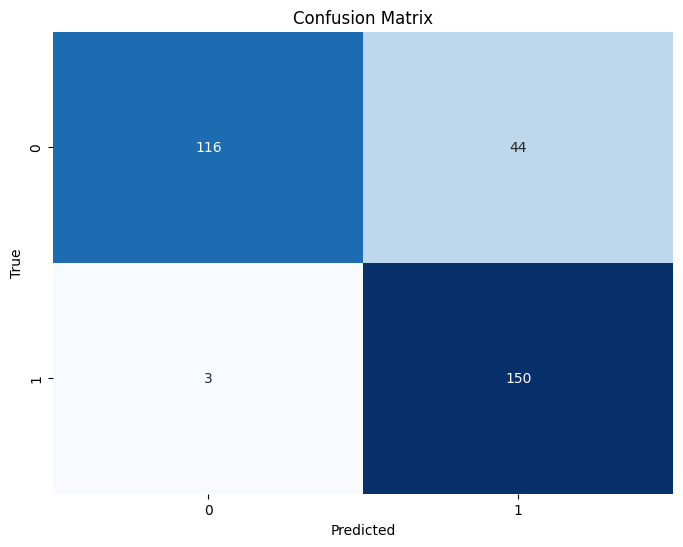

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9265175718849841
Macro F1: 0.9265145715306486
Weighted F1: 0.9265250727708224
Precision: 0.9266639444671294
Recall: 0.9268382352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       160
           1       0.91      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



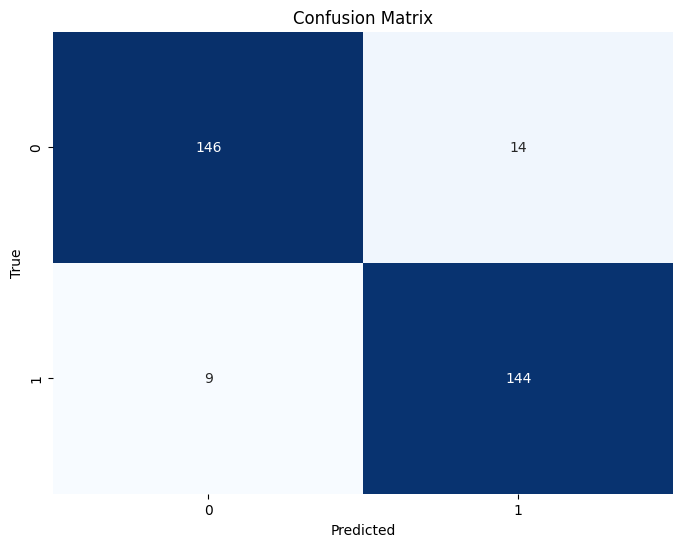

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9361022364217252
Macro F1: 0.9360859266519643
Weighted F1: 0.9361087603296296
Precision: 0.9360351163740303
Recall: 0.9362132352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       160
           1       0.93      0.94      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



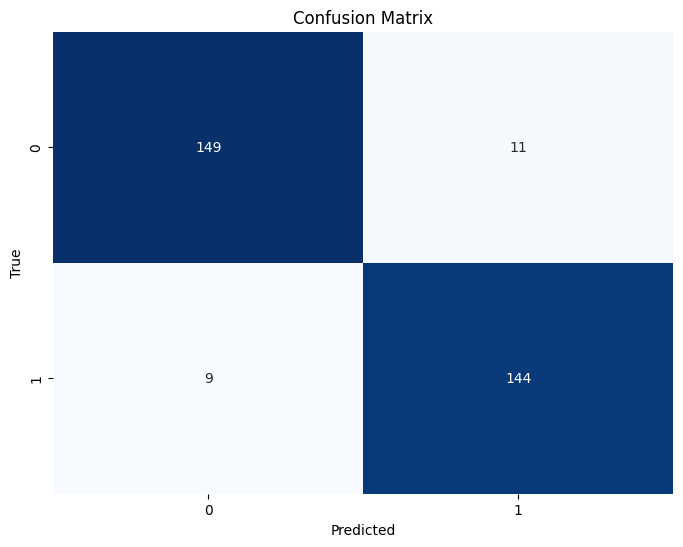

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9361022364217252
Macro F1: 0.9360859266519643
Weighted F1: 0.9361087603296296
Precision: 0.9360351163740303
Recall: 0.9362132352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       160
           1       0.93      0.94      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



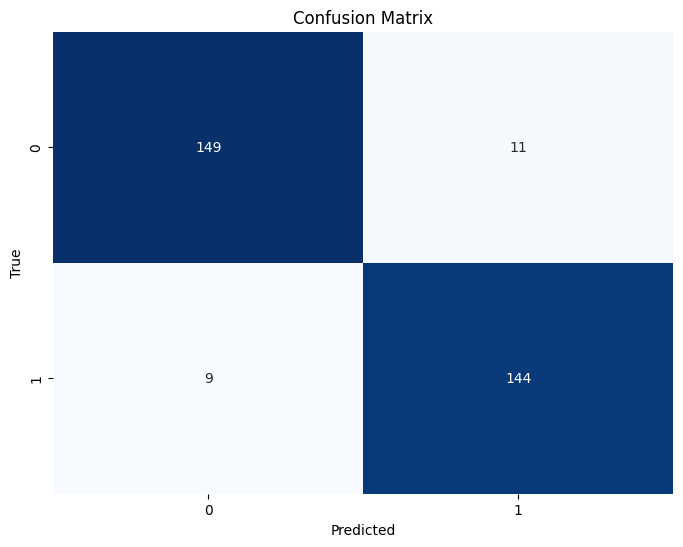

Accuracy: 0.9361022364217252
Macro F1: 0.9360859266519643
Weighted F1: 0.9361087603296296
Precision: 0.9360351163740303
Recall: 0.9362132352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       160
           1       0.93      0.94      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



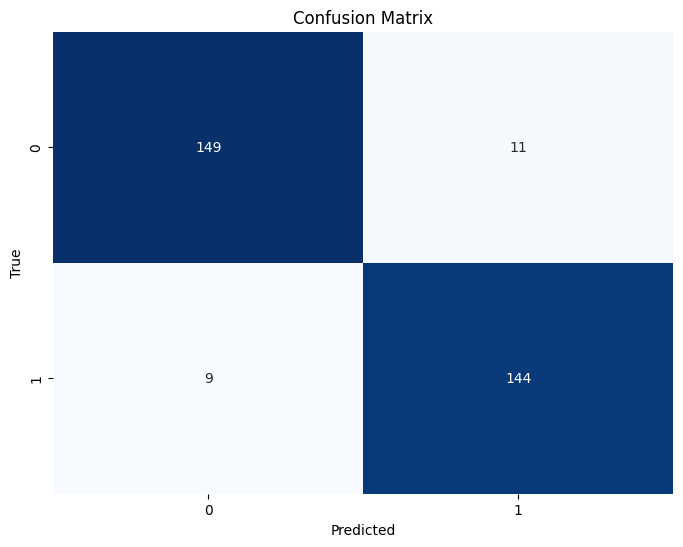

{'learning_rate': 3e-05, 'batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=3e-05, bs=8, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.461007,0.801917,0.797348,0.796667,0.841035,0.805678,precision recall f1-score support 0 0.96 0.64 0.77 160 1 0.72 0.97 0.83 153 accuracy 0.80 313 macro avg 0.84 0.81 0.80 313 weighted avg 0.84 0.80 0.80 313
2,0.453781,0.281279,0.897764,0.897712,0.897661,0.900316,0.898713,precision recall f1-score support 0 0.94 0.86 0.90 160 1 0.86 0.94 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.90 0.90 0.90 313
3,0.267570,0.307813,0.929712,0.929654,0.929700,0.929850,0.929534,precision recall f1-score support 0 0.93 0.94 0.93 160 1 0.93 0.92 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.8019169329073482
Macro F1: 0.7973475355054302
Weighted F1: 0.7966669869562083
Precision: 0.8410354571142102
Recall: 0.8056781045751633
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.64      0.77       160
           1       0.72      0.97      0.83       153

    accuracy                           0.80       313
   macro avg       0.84      0.81      0.80       313
weighted avg       0.84      0.80      0.80       313



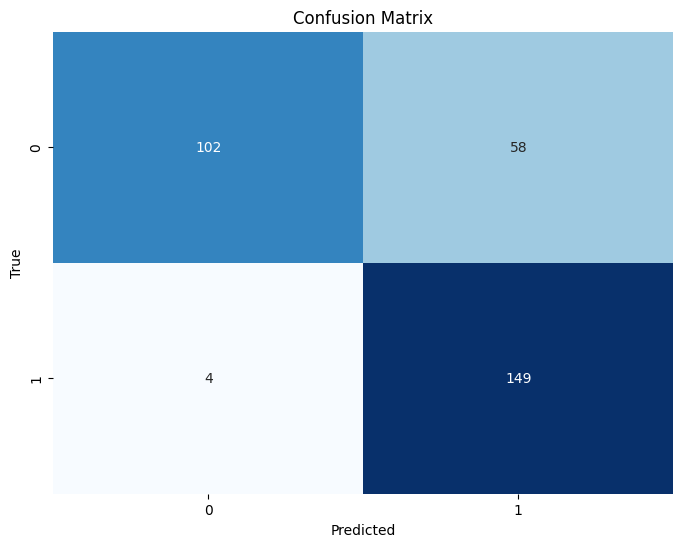

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8977635782747604
Macro F1: 0.8977124183006536
Weighted F1: 0.8976612583265468
Precision: 0.9003158067426791
Recall: 0.8987132352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       160
           1       0.86      0.94      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.90      0.90      0.90       313



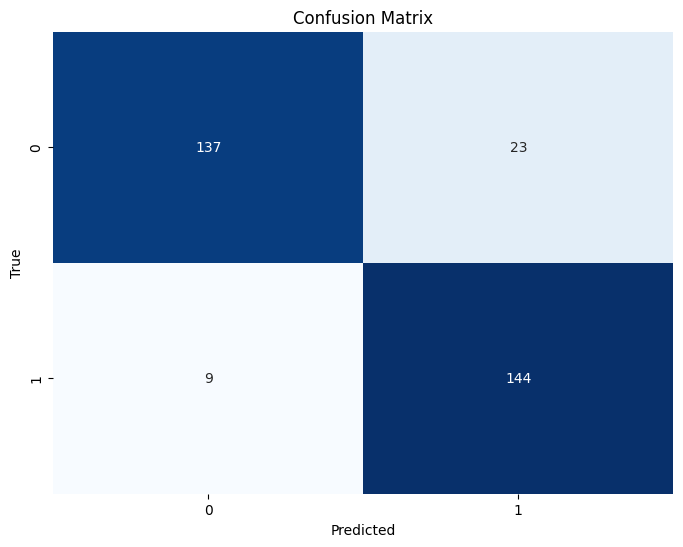

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9297124600638977
Macro F1: 0.9296542987904544
Weighted F1: 0.929699535336466
Precision: 0.929850380181506
Recall: 0.9295343137254901
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



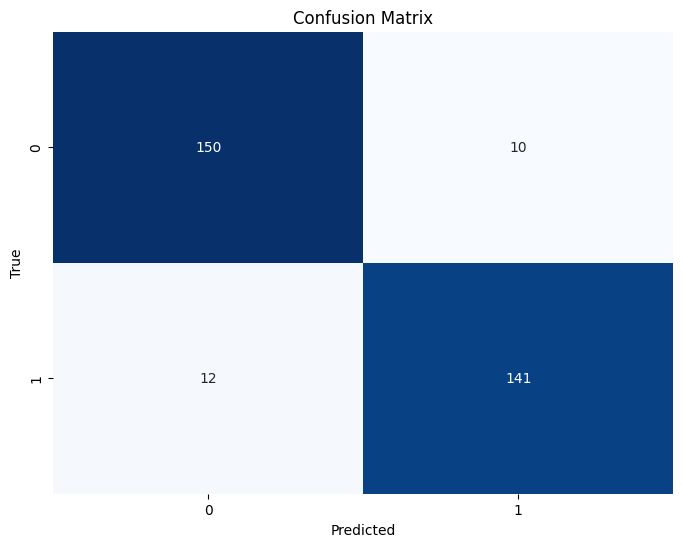

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9297124600638977
Macro F1: 0.9296542987904544
Weighted F1: 0.929699535336466
Precision: 0.929850380181506
Recall: 0.9295343137254901
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



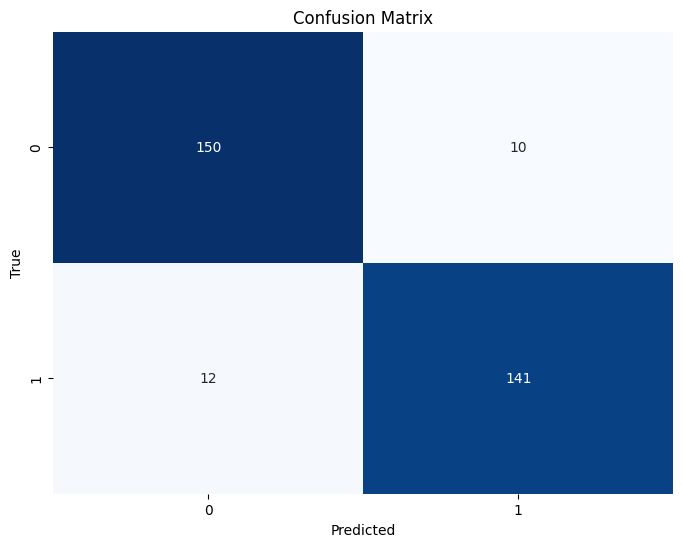

Accuracy: 0.9297124600638977
Macro F1: 0.9296542987904544
Weighted F1: 0.929699535336466
Precision: 0.929850380181506
Recall: 0.9295343137254901
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       160
           1       0.93      0.92      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



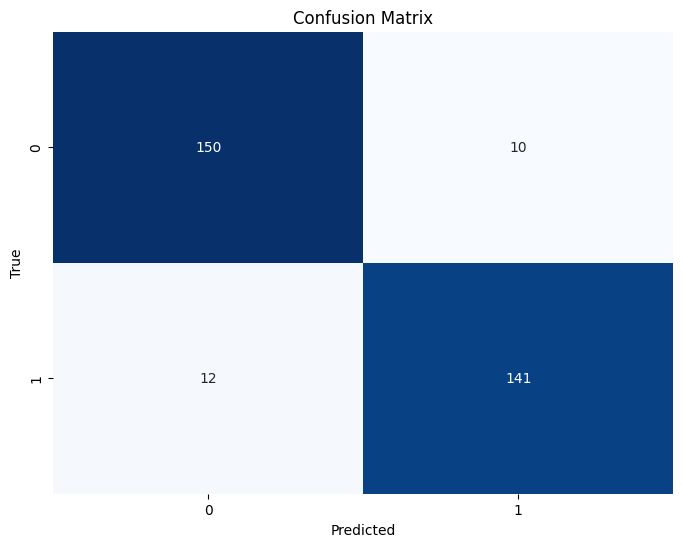

{'learning_rate': 1e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=1e-05, bs=16, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.201881,0.916933,0.916932,0.916926,0.917600,0.917463,precision recall f1-score support 0 0.94 0.89 0.92 160 1 0.89 0.94 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,No log,0.200923,0.920128,0.920128,0.920128,0.920588,0.920588,precision recall f1-score support 0 0.94 0.90 0.92 160 1 0.90 0.94 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.9169329073482428
Macro F1: 0.9169320594479831
Weighted F1: 0.9169261241461645
Precision: 0.9175997057862046
Recall: 0.9174632352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       160
           1       0.89      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



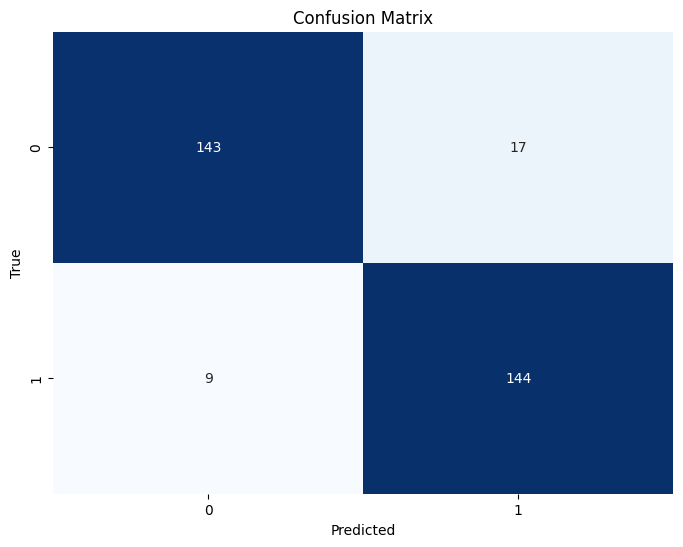

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.9201277955271565
Weighted F1: 0.9201277955271565
Precision: 0.9205882352941177
Recall: 0.9205882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       160
           1       0.90      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



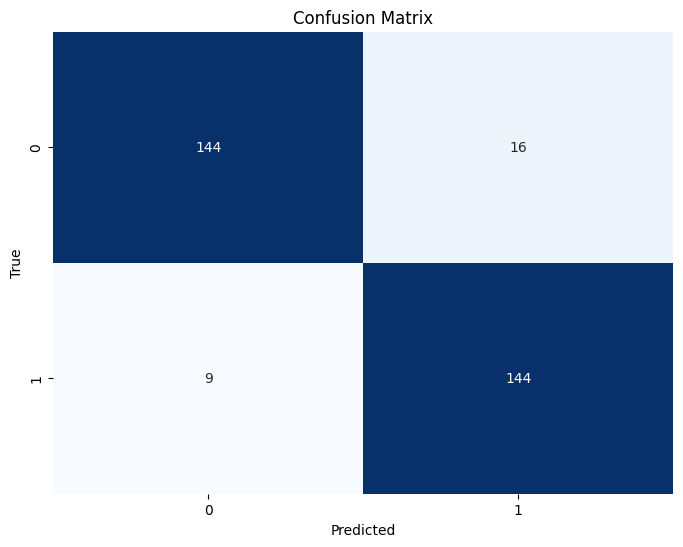

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9201277955271565
Macro F1: 0.9201277955271565
Weighted F1: 0.9201277955271565
Precision: 0.9205882352941177
Recall: 0.9205882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       160
           1       0.90      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



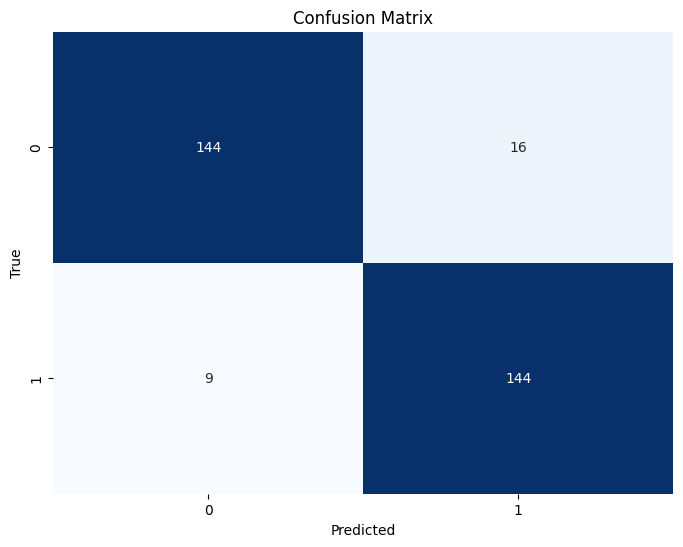

Accuracy: 0.9201277955271565
Macro F1: 0.9201277955271565
Weighted F1: 0.9201277955271565
Precision: 0.9205882352941177
Recall: 0.9205882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       160
           1       0.90      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



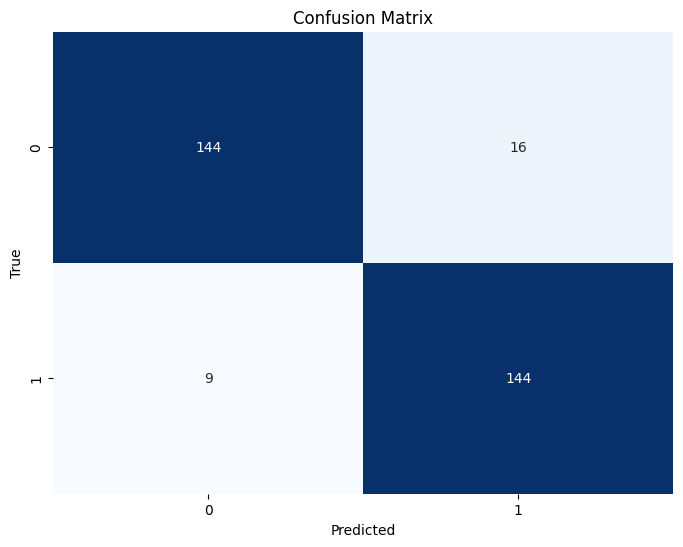

{'learning_rate': 1e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=1e-05, bs=16, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.226958,0.904153,0.904129,0.904095,0.905958,0.904963,precision recall f1-score support 0 0.94 0.87 0.90 160 1 0.87 0.94 0.91 153 accuracy 0.90 313 macro avg 0.91 0.90 0.90 313 weighted avg 0.91 0.90 0.90 313
2,No log,0.166732,0.932907,0.932883,0.932911,0.932839,0.932945,precision recall f1-score support 0 0.94 0.93 0.93 160 1 0.93 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9041533546325878
Macro F1: 0.9041288899779466
Weighted F1: 0.9040946394614489
Precision: 0.9059582309582309
Recall: 0.9049632352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       160
           1       0.87      0.94      0.91       153

    accuracy                           0.90       313
   macro avg       0.91      0.90      0.90       313
weighted avg       0.91      0.90      0.90       313



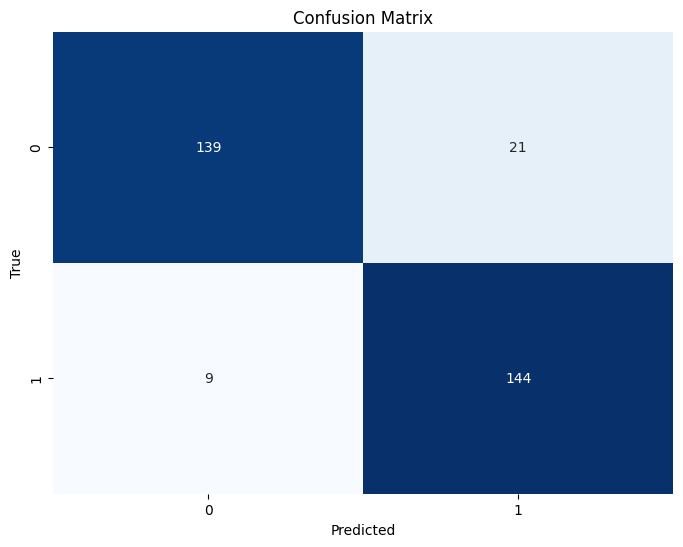

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9329073482428115
Macro F1: 0.9328826851010384
Weighted F1: 0.9329114587664403
Precision: 0.9328391734052112
Recall: 0.9329452614379086
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.93      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



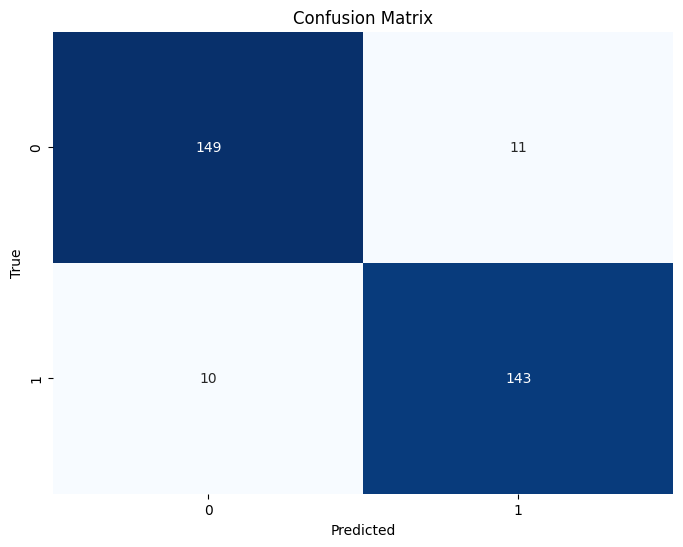

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.226958,0.904153,0.904129,0.904095,0.905958,0.904963,precision recall f1-score support 0 0.94 0.87 0.90 160 1 0.87 0.94 0.91 153 accuracy 0.90 313 macro avg 0.91 0.90 0.90 313 weighted avg 0.91 0.90 0.90 313
2,No log,0.166732,0.932907,0.932883,0.932911,0.932839,0.932945,precision recall f1-score support 0 0.94 0.93 0.93 160 1 0.93 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
3,0.327283,0.185297,0.936102,0.936070,0.936102,0.936070,0.936070,precision recall f1-score support 0 0.94 0.94 0.94 160 1 0.93 0.93 0.93 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.9361022364217252
Macro F1: 0.9360702614379085
Weighted F1: 0.9361022364217252
Precision: 0.9360702614379085
Recall: 0.9360702614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       160
           1       0.93      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



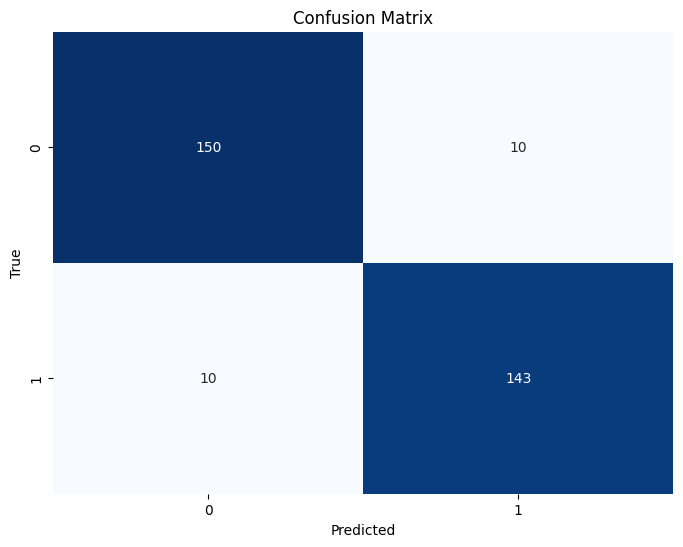

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9361022364217252
Macro F1: 0.9360702614379085
Weighted F1: 0.9361022364217252
Precision: 0.9360702614379085
Recall: 0.9360702614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       160
           1       0.93      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



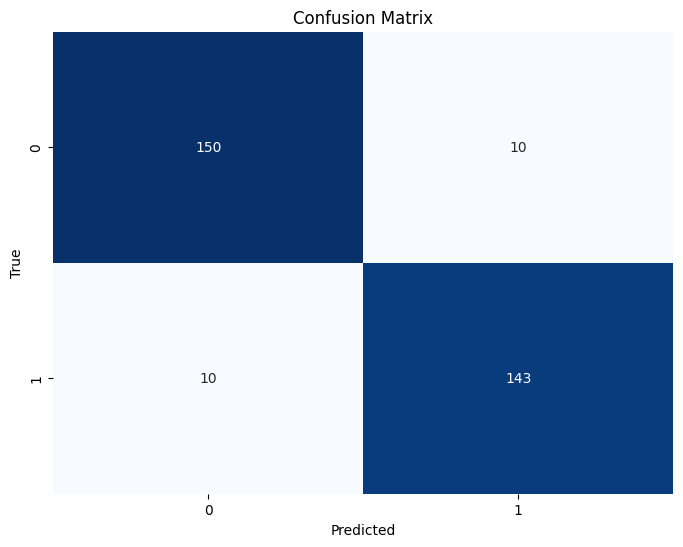

Accuracy: 0.9361022364217252
Macro F1: 0.9360702614379085
Weighted F1: 0.9361022364217252
Precision: 0.9360702614379085
Recall: 0.9360702614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       160
           1       0.93      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



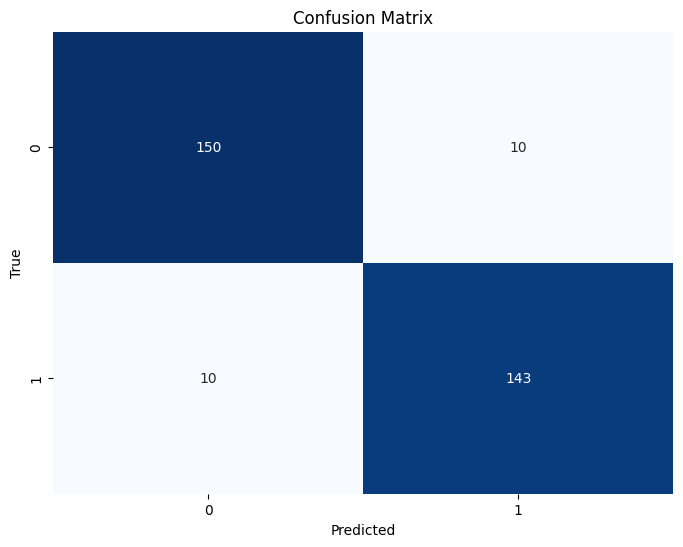

{'learning_rate': 1e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=1e-05, bs=16, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.225861,0.897764,0.897679,0.897613,0.901216,0.898856,precision recall f1-score support 0 0.94 0.85 0.89 160 1 0.86 0.95 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.90 0.90 0.90 313
2,No log,0.174936,0.926518,0.926506,0.926527,0.926486,0.926695,precision recall f1-score support 0 0.94 0.92 0.93 160 1 0.92 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
3,0.331471,0.194966,0.932907,0.932896,0.932916,0.932876,0.933088,precision recall f1-score support 0 0.94 0.93 0.93 160 1 0.92 0.94 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.8977635782747604
Macro F1: 0.8976789800588427
Weighted F1: 0.8976131814464624
Precision: 0.9012163050624589
Recall: 0.8988562091503267
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       160
           1       0.86      0.95      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.90      0.90      0.90       313



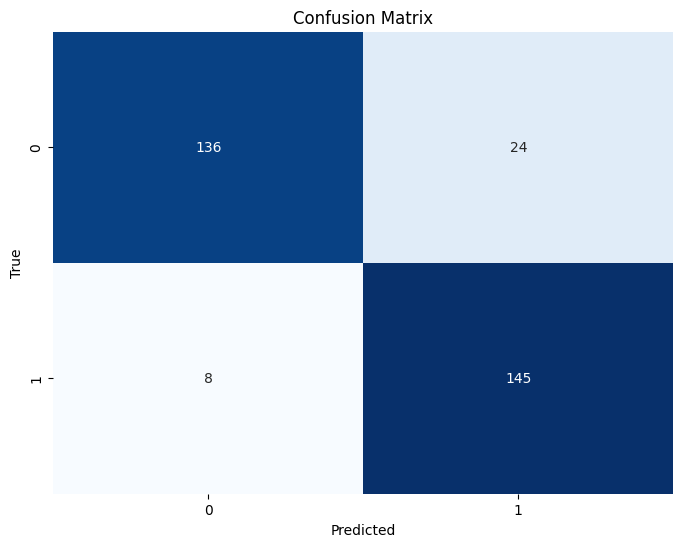

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9265265740506897
Precision: 0.9264861995753715
Recall: 0.9266952614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       160
           1       0.92      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



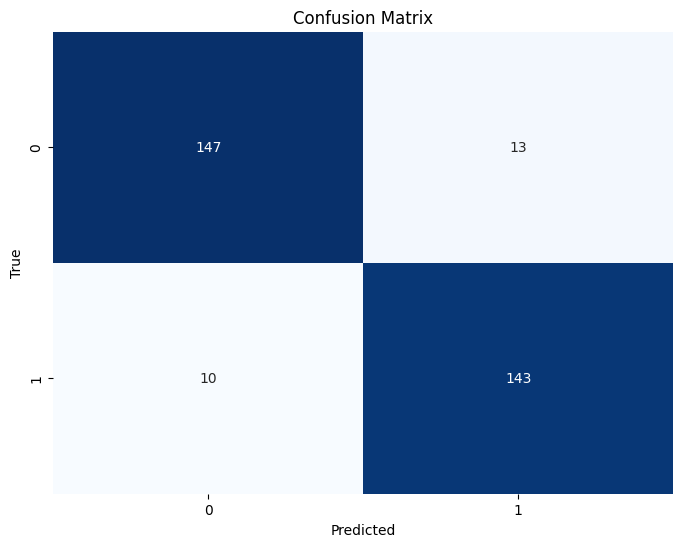

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



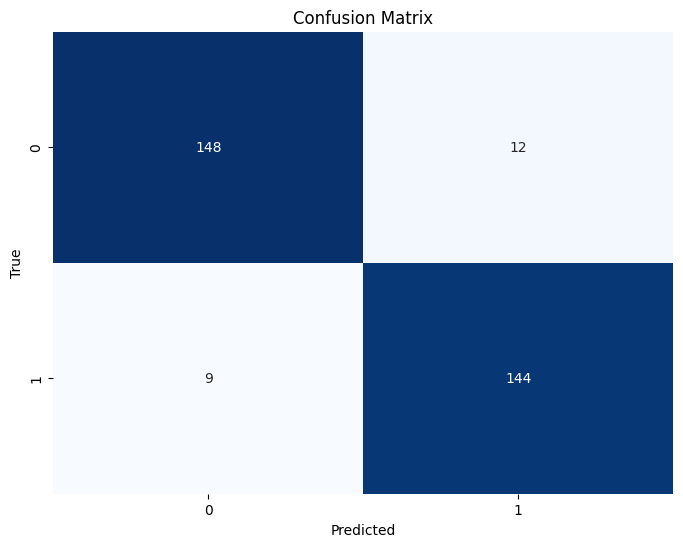

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



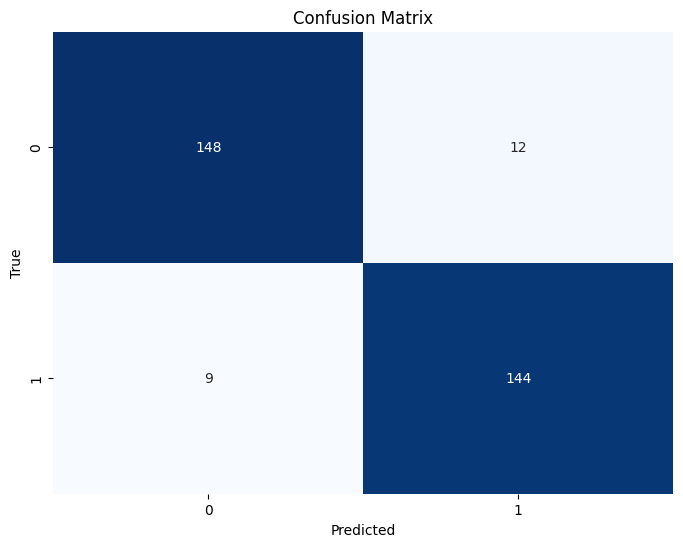

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



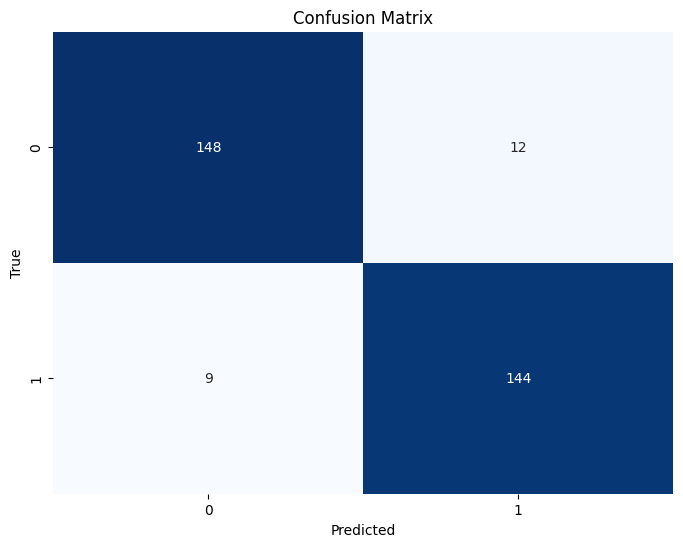

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.0}
Running: lr=2e-05, bs=16, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.207086,0.926518,0.926515,0.926525,0.926664,0.926838,precision recall f1-score support 0 0.94 0.91 0.93 160 1 0.91 0.94 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
2,No log,0.189272,0.923323,0.923316,0.923332,0.923363,0.923570,precision recall f1-score support 0 0.94 0.91 0.92 160 1 0.91 0.93 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.9265175718849841
Macro F1: 0.9265145715306486
Weighted F1: 0.9265250727708224
Precision: 0.9266639444671294
Recall: 0.9268382352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       160
           1       0.91      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



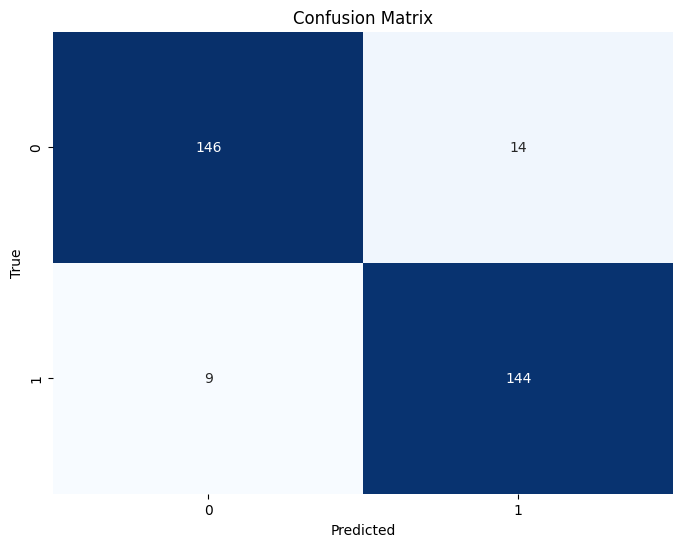

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9233226837060703
Macro F1: 0.9233156390363414
Weighted F1: 0.9233320765990423
Precision: 0.9233627306875715
Recall: 0.9235702614379084
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       160
           1       0.91      0.93      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



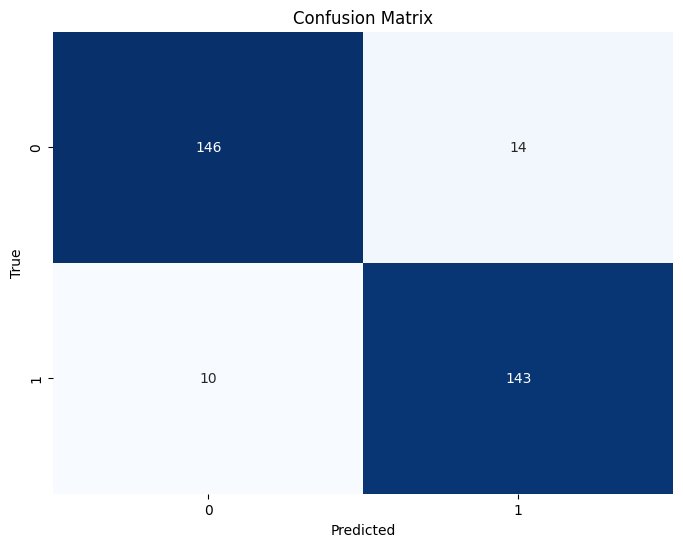

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9265175718849841
Macro F1: 0.9265145715306486
Weighted F1: 0.9265250727708224
Precision: 0.9266639444671294
Recall: 0.9268382352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       160
           1       0.91      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



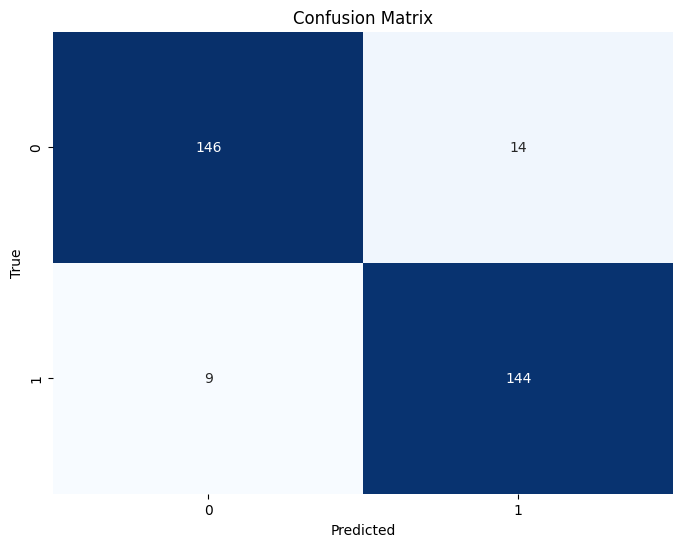

Accuracy: 0.9265175718849841
Macro F1: 0.9265145715306486
Weighted F1: 0.9265250727708224
Precision: 0.9266639444671294
Recall: 0.9268382352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       160
           1       0.91      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



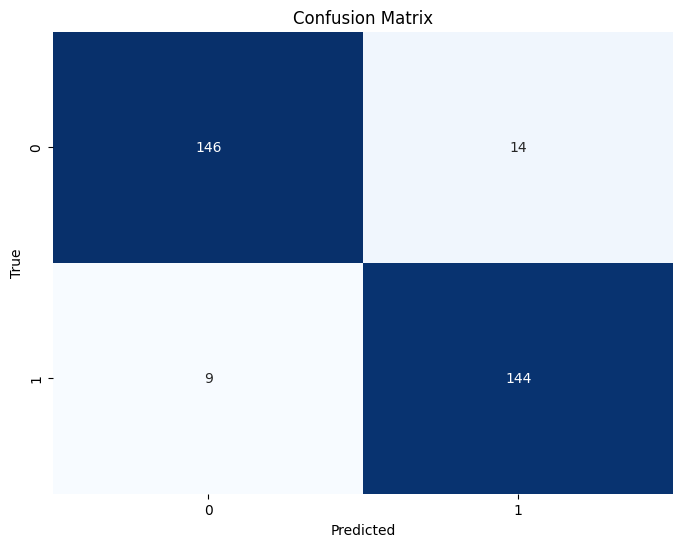

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=2e-05, bs=16, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.200109,0.929712,0.929677,0.929712,0.929677,0.929677,precision recall f1-score support 0 0.93 0.93 0.93 160 1 0.93 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
2,No log,0.202773,0.932907,0.932896,0.932916,0.932876,0.933088,precision recall f1-score support 0 0.94 0.93 0.93 160 1 0.92 0.94 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9297124600638977
Macro F1: 0.9296772875816994
Weighted F1: 0.9297124600638977
Precision: 0.9296772875816994
Recall: 0.9296772875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       160
           1       0.93      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



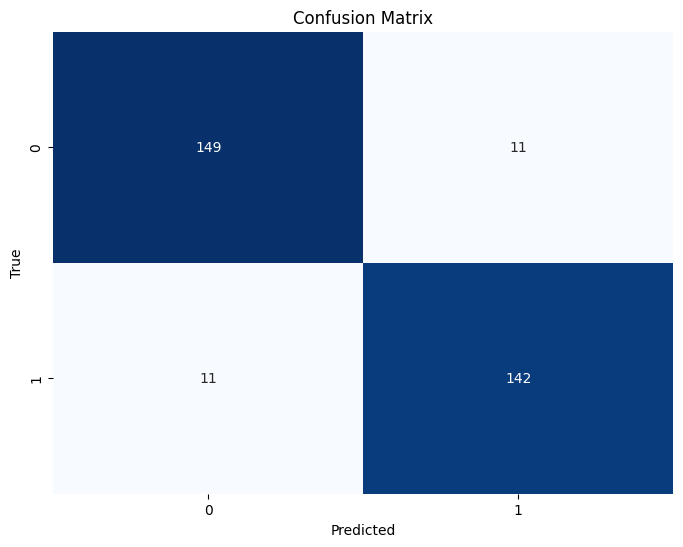

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



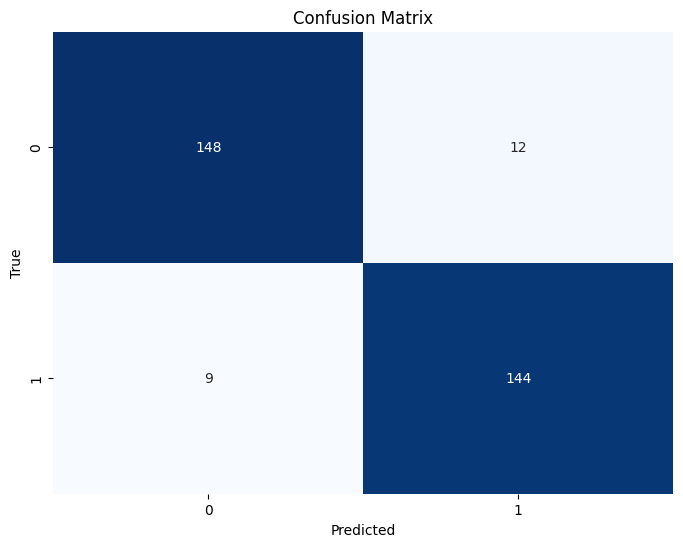

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



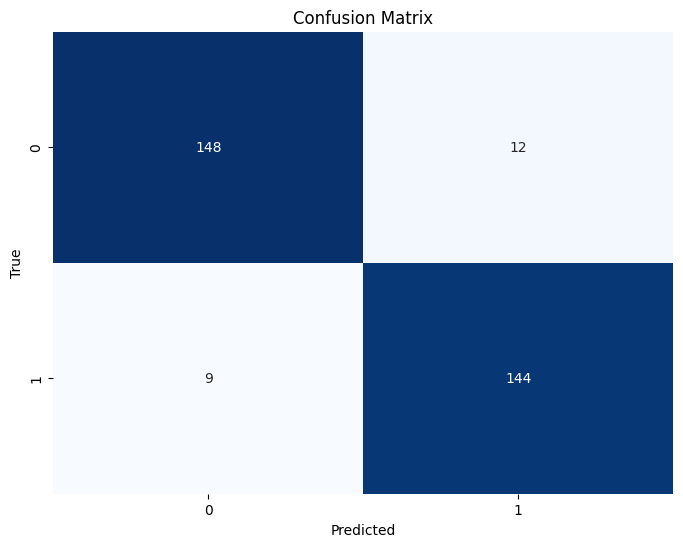

Accuracy: 0.9329073482428115
Macro F1: 0.932896389084561
Weighted F1: 0.9329155676114994
Precision: 0.932876041156296
Recall: 0.9330882352941177
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.94      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



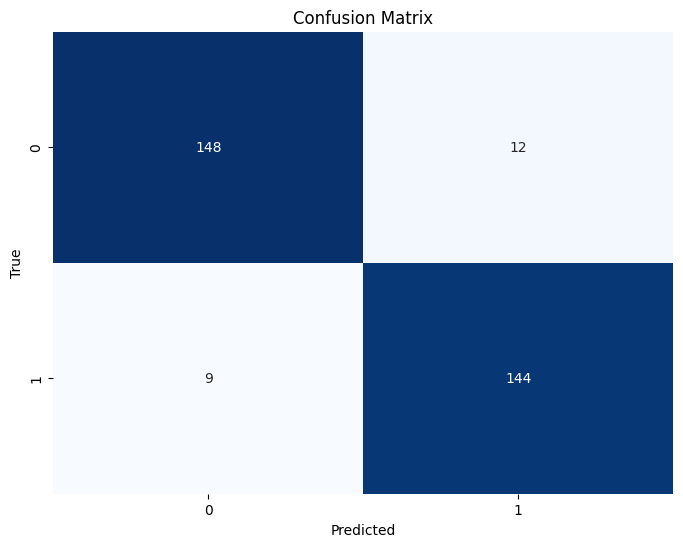

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=2e-05, bs=16, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.226550,0.929712,0.929591,0.929656,0.930620,0.929248,precision recall f1-score support 0 0.92 0.95 0.93 160 1 0.95 0.91 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
2,No log,0.176261,0.936102,0.936102,0.936106,0.936392,0.936499,precision recall f1-score support 0 0.95 0.92 0.94 160 1 0.92 0.95 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313
3,0.311291,0.200344,0.936102,0.936070,0.936102,0.936070,0.936070,precision recall f1-score support 0 0.94 0.94 0.94 160 1 0.93 0.93 0.93 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.9297124600638977
Macro F1: 0.9295910020449898
Weighted F1: 0.9296564025167096
Precision: 0.9306204409474633
Recall: 0.9292483660130719
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       160
           1       0.95      0.91      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



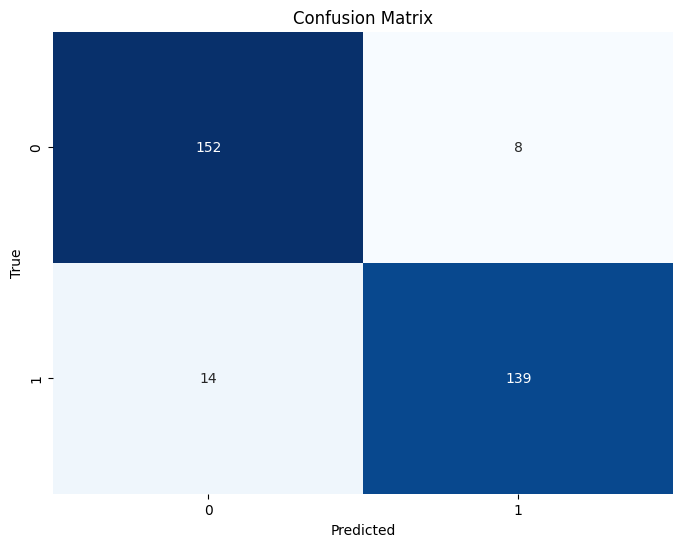

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9361022364217252
Macro F1: 0.9361015841907562
Weighted F1: 0.9361061498075396
Precision: 0.9363922241280732
Recall: 0.9364991830065359
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       160
           1       0.92      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



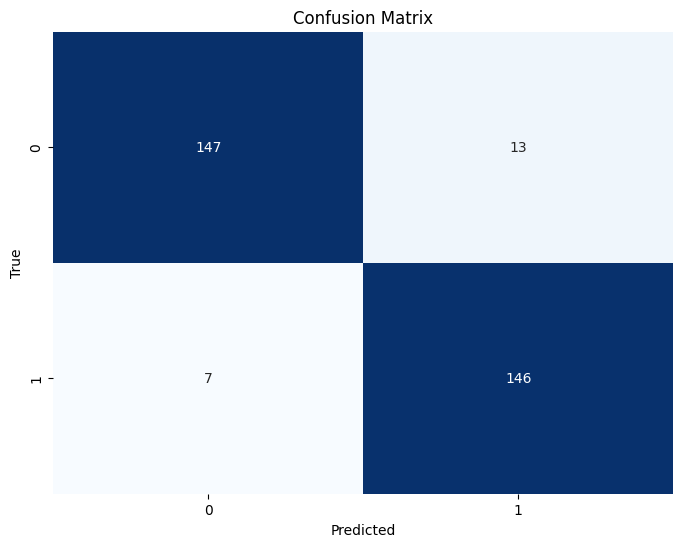

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9361022364217252
Macro F1: 0.9360702614379085
Weighted F1: 0.9361022364217252
Precision: 0.9360702614379085
Recall: 0.9360702614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       160
           1       0.93      0.93      0.93       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



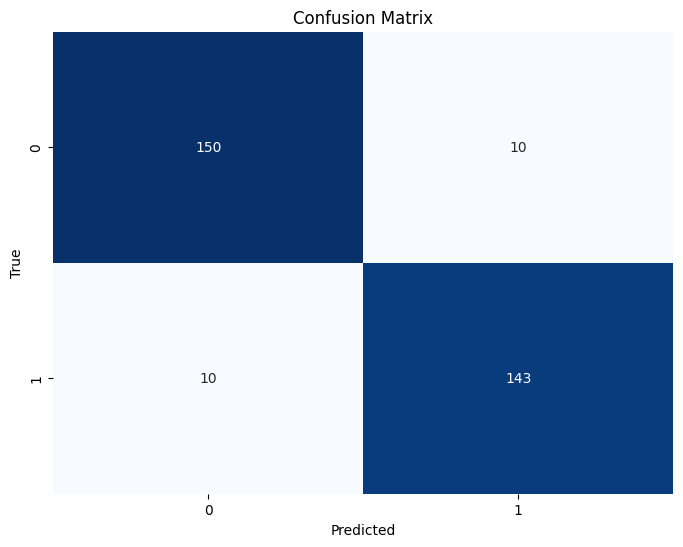

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9361022364217252
Macro F1: 0.9361015841907562
Weighted F1: 0.9361061498075396
Precision: 0.9363922241280732
Recall: 0.9364991830065359
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       160
           1       0.92      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



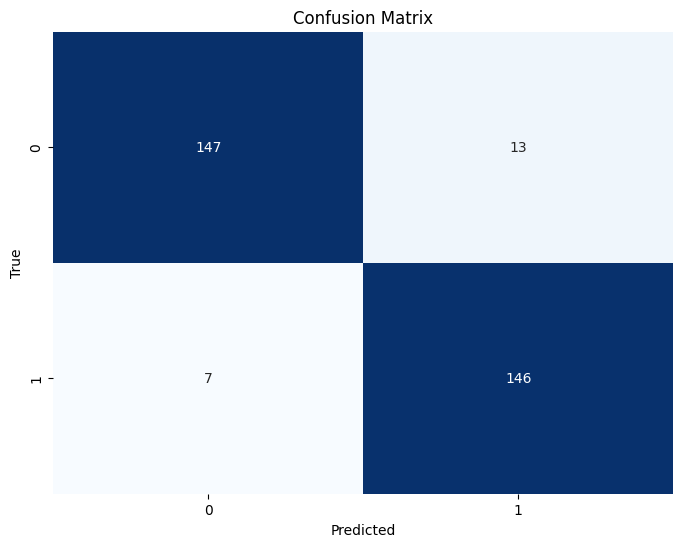

Accuracy: 0.9361022364217252
Macro F1: 0.9361015841907562
Weighted F1: 0.9361061498075396
Precision: 0.9363922241280732
Recall: 0.9364991830065359
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       160
           1       0.92      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



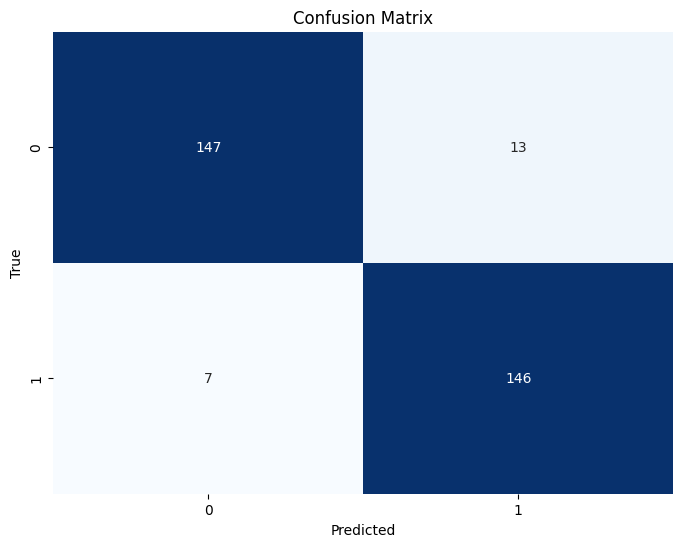

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=2e-05, bs=16, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.212831,0.929712,0.929551,0.929626,0.931219,0.929105,precision recall f1-score support 0 0.91 0.96 0.93 160 1 0.95 0.90 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
2,No log,0.180324,0.929712,0.929695,0.929720,0.929645,0.929820,precision recall f1-score support 0 0.94 0.93 0.93 160 1 0.92 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
3,0.322459,0.209276,0.939297,0.939287,0.939305,0.939266,0.939481,precision recall f1-score support 0 0.95 0.93 0.94 160 1 0.93 0.95 0.94 153 accuracy 0.94 313 macro avg 0.94 0.94 0.94 313 weighted avg 0.94 0.94 0.94 313


Accuracy: 0.9297124600638977
Macro F1: 0.929550662956294
Weighted F1: 0.9296261682731759
Precision: 0.9312192118226601
Recall: 0.9291053921568628
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       160
           1       0.95      0.90      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



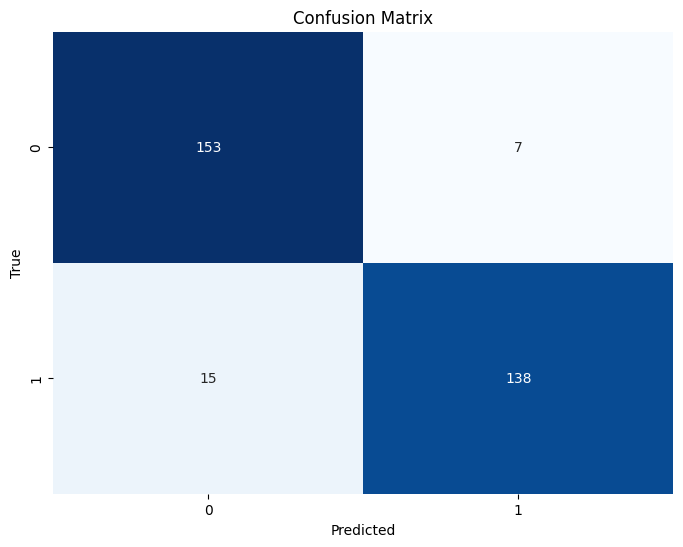

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9297124600638977
Macro F1: 0.9296945193171609
Weighted F1: 0.9297196363625927
Precision: 0.929644752960392
Recall: 0.9298202614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.92      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



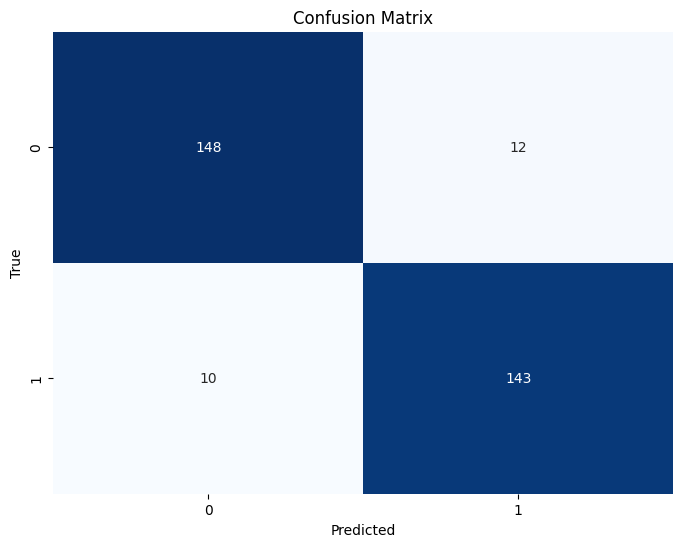

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.939297124600639
Macro F1: 0.9392872091717457
Weighted F1: 0.939304561172309
Precision: 0.9392658827372203
Recall: 0.9394812091503268
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.93      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



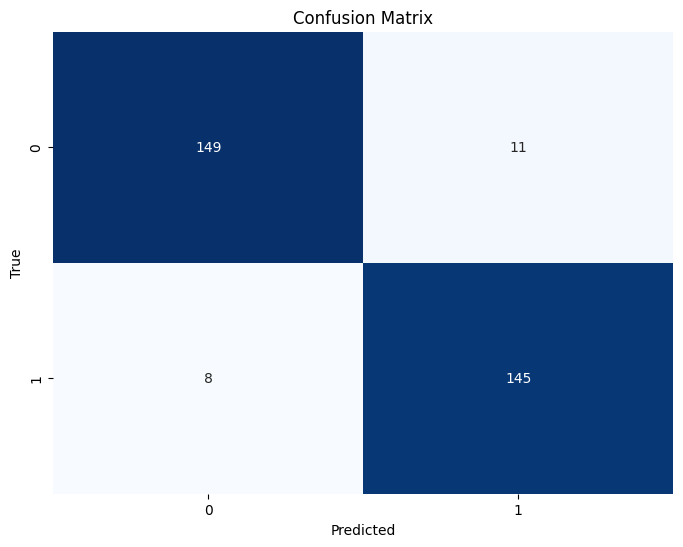

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.939297124600639
Macro F1: 0.9392872091717457
Weighted F1: 0.939304561172309
Precision: 0.9392658827372203
Recall: 0.9394812091503268
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.93      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



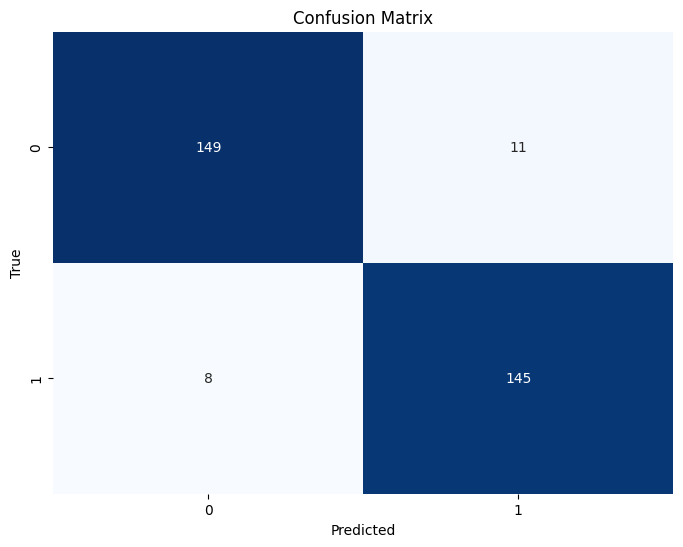

Accuracy: 0.939297124600639
Macro F1: 0.9392872091717457
Weighted F1: 0.939304561172309
Precision: 0.9392658827372203
Recall: 0.9394812091503268
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.93      0.95      0.94       153

    accuracy                           0.94       313
   macro avg       0.94      0.94      0.94       313
weighted avg       0.94      0.94      0.94       313



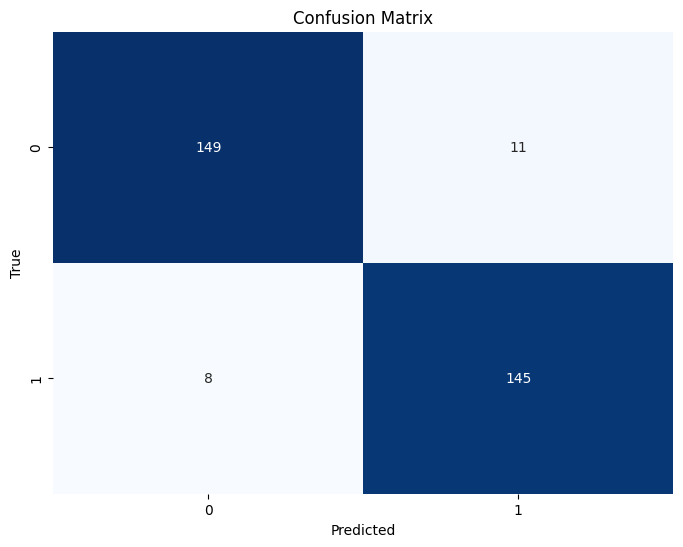

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.0}
Running: lr=3e-05, bs=16, epochs=2, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.261132,0.897764,0.897754,0.897732,0.898916,0.898427,precision recall f1-score support 0 0.93 0.87 0.90 160 1 0.87 0.93 0.90 153 accuracy 0.90 313 macro avg 0.90 0.90 0.90 313 weighted avg 0.90 0.90 0.90 313
2,No log,0.207262,0.920128,0.920098,0.920133,0.920056,0.920159,precision recall f1-score support 0 0.92 0.92 0.92 160 1 0.92 0.92 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.8977635782747604
Macro F1: 0.8977541853817885
Weighted F1: 0.8977322686315208
Precision: 0.8989161554192229
Recall: 0.8984272875816994
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       160
           1       0.87      0.93      0.90       153

    accuracy                           0.90       313
   macro avg       0.90      0.90      0.90       313
weighted avg       0.90      0.90      0.90       313



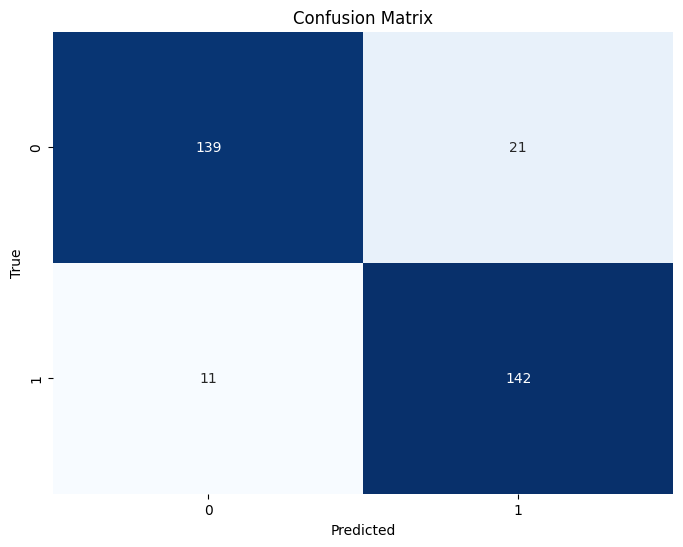

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



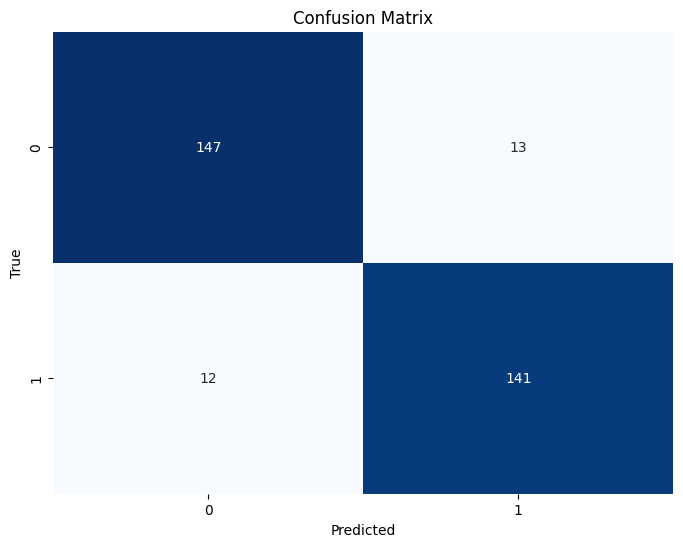

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



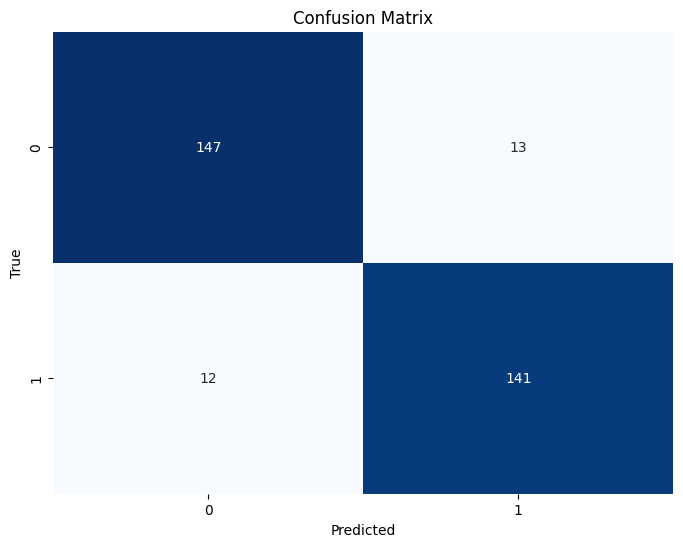

Accuracy: 0.9201277955271565
Macro F1: 0.9200984346440935
Weighted F1: 0.9201326890076671
Precision: 0.9200563587356041
Recall: 0.9201593137254902
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



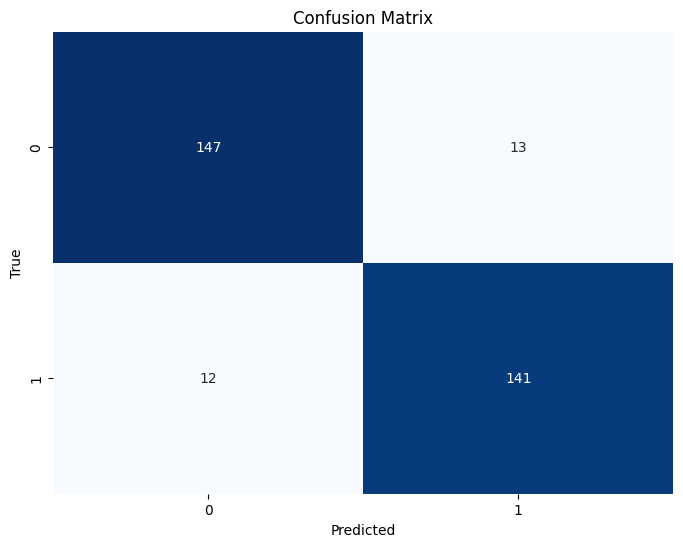

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=3e-05, bs=16, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.219556,0.926518,0.926442,0.926495,0.926789,0.926266,precision recall f1-score support 0 0.92 0.94 0.93 160 1 0.93 0.92 0.92 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313
2,No log,0.216882,0.926518,0.926506,0.926527,0.926486,0.926695,precision recall f1-score support 0 0.94 0.92 0.93 160 1 0.92 0.93 0.93 153 accuracy 0.93 313 macro avg 0.93 0.93 0.93 313 weighted avg 0.93 0.93 0.93 313


Accuracy: 0.9265175718849841
Macro F1: 0.9264424894501834
Weighted F1: 0.9264950471545438
Precision: 0.9267893660531697
Recall: 0.926266339869281
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       160
           1       0.93      0.92      0.92       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



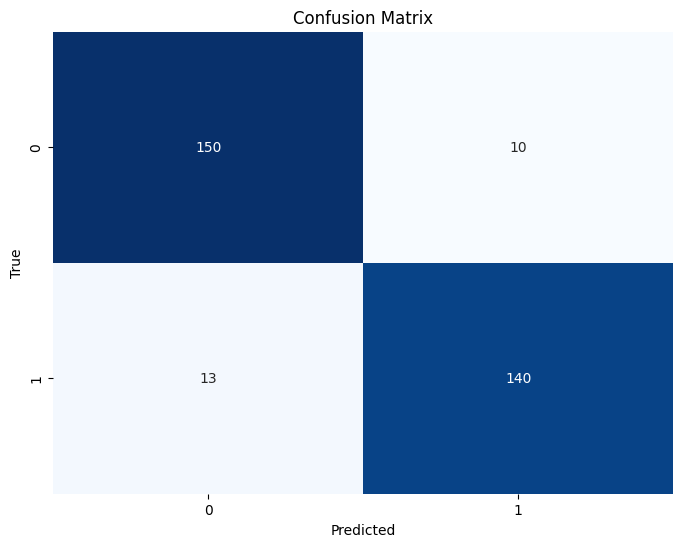

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9265265740506897
Precision: 0.9264861995753715
Recall: 0.9266952614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       160
           1       0.92      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



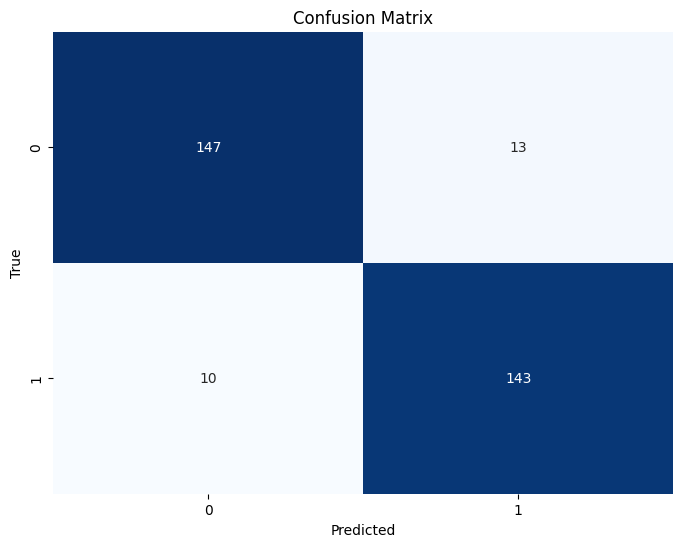

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9265265740506897
Precision: 0.9264861995753715
Recall: 0.9266952614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       160
           1       0.92      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



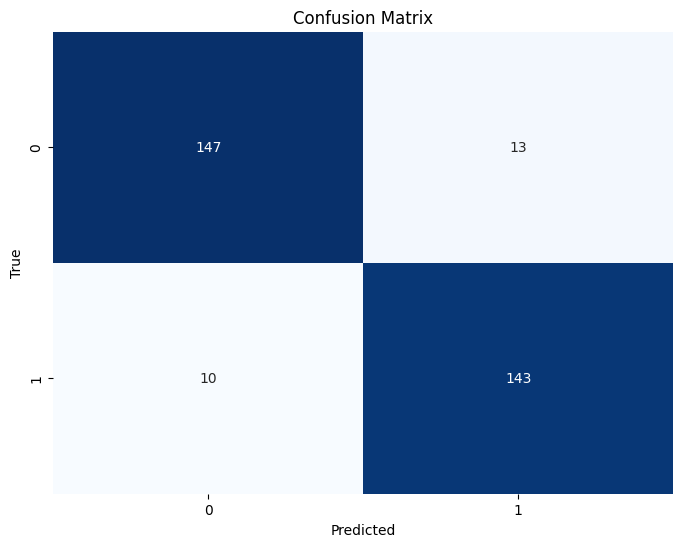

Accuracy: 0.9265175718849841
Macro F1: 0.9265055689973762
Weighted F1: 0.9265265740506897
Precision: 0.9264861995753715
Recall: 0.9266952614379085
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       160
           1       0.92      0.93      0.93       153

    accuracy                           0.93       313
   macro avg       0.93      0.93      0.93       313
weighted avg       0.93      0.93      0.93       313



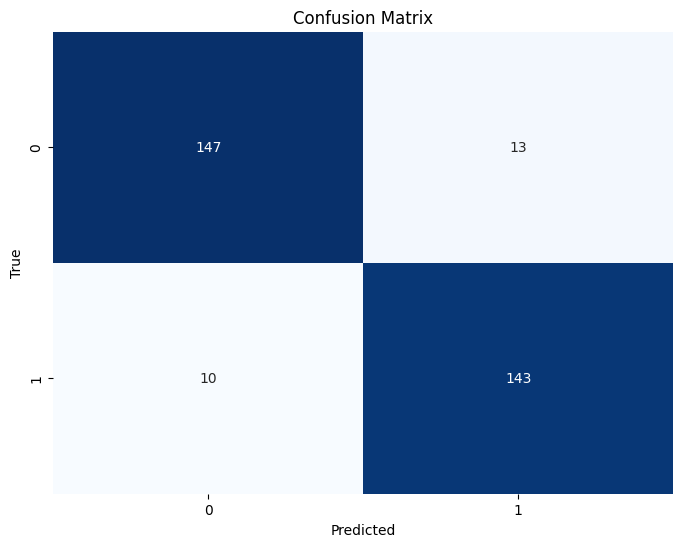

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.0}
Running: lr=3e-05, bs=16, epochs=3, wd=0.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.204614,0.920128,0.920010,0.920079,0.920762,0.919730,precision recall f1-score support 0 0.91 0.94 0.92 160 1 0.93 0.90 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
2,No log,0.247016,0.910543,0.910520,0.910488,0.912367,0.911356,precision recall f1-score support 0 0.95 0.88 0.91 160 1 0.88 0.95 0.91 153 accuracy 0.91 313 macro avg 0.91 0.91 0.91 313 weighted avg 0.91 0.91 0.91 313


Accuracy: 0.9201277955271565
Macro F1: 0.9200102223358038
Weighted F1: 0.9200788066974261
Precision: 0.9207616707616708
Recall: 0.9197303921568627
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       160
           1       0.93      0.90      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



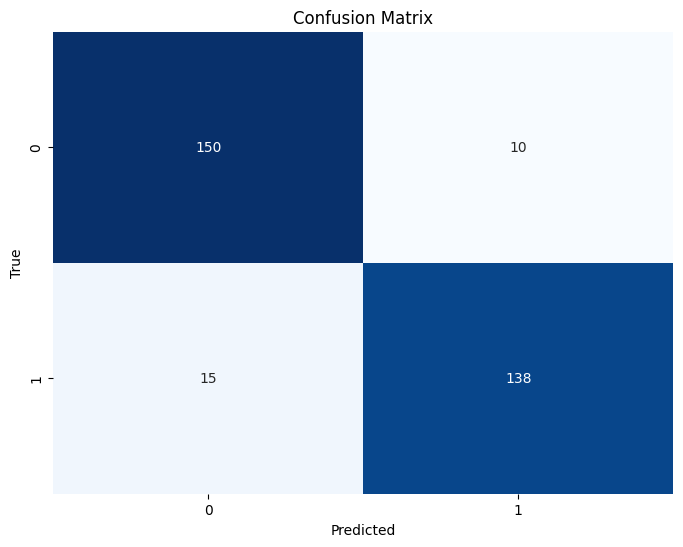

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9105431309904153
Macro F1: 0.9105202973127502
Weighted F1: 0.9104883301640189
Precision: 0.9123669123669124
Recall: 0.9113562091503268
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       160
           1       0.88      0.95      0.91       153

    accuracy                           0.91       313
   macro avg       0.91      0.91      0.91       313
weighted avg       0.91      0.91      0.91       313



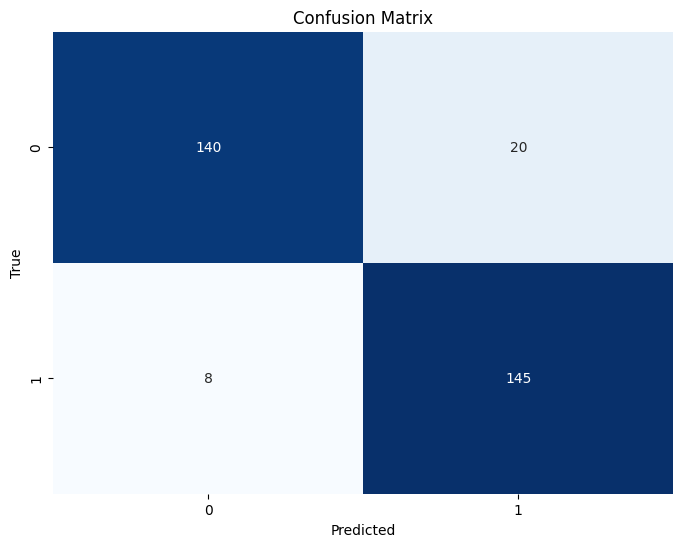

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9201277955271565
Macro F1: 0.9200102223358038
Weighted F1: 0.9200788066974261
Precision: 0.9207616707616708
Recall: 0.9197303921568627
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       160
           1       0.93      0.90      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



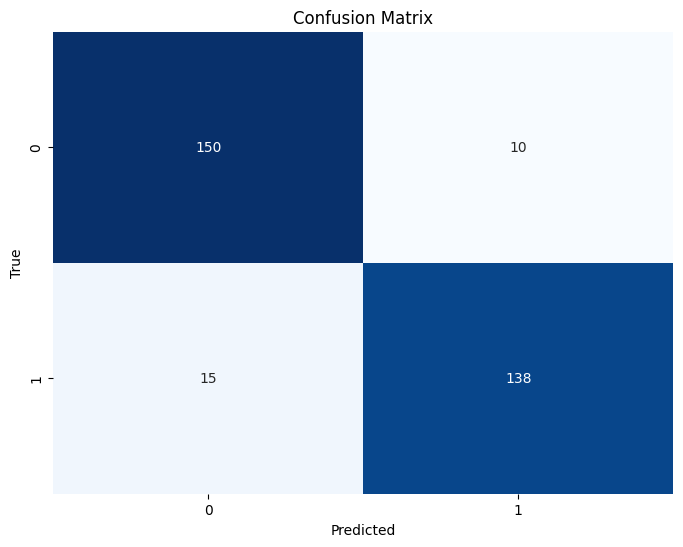

Accuracy: 0.9201277955271565
Macro F1: 0.9200102223358038
Weighted F1: 0.9200788066974261
Precision: 0.9207616707616708
Recall: 0.9197303921568627
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       160
           1       0.93      0.90      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



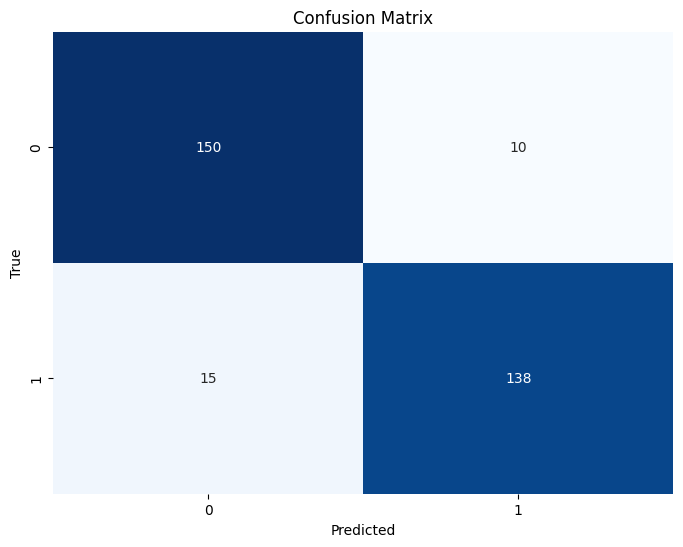

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=3e-05, bs=16, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.206877,0.913738,0.913228,0.913377,0.919471,0.912480,precision recall f1-score support 0 0.88 0.97 0.92 160 1 0.96 0.86 0.91 153 accuracy 0.91 313 macro avg 0.92 0.91 0.91 313 weighted avg 0.92 0.91 0.91 313
2,No log,0.205616,0.923323,0.923322,0.923327,0.923609,0.923713,precision recall f1-score support 0 0.94 0.91 0.92 160 1 0.91 0.94 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313
3,0.310893,0.294164,0.920128,0.920076,0.920121,0.920154,0.920016,precision recall f1-score support 0 0.92 0.93 0.92 160 1 0.92 0.92 0.92 153 accuracy 0.92 313 macro avg 0.92 0.92 0.92 313 weighted avg 0.92 0.92 0.92 313


Accuracy: 0.9137380191693291
Macro F1: 0.9132278500508251
Weighted F1: 0.9133766493770553
Precision: 0.9194707544034564
Recall: 0.9124795751633987
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       160
           1       0.96      0.86      0.91       153

    accuracy                           0.91       313
   macro avg       0.92      0.91      0.91       313
weighted avg       0.92      0.91      0.91       313



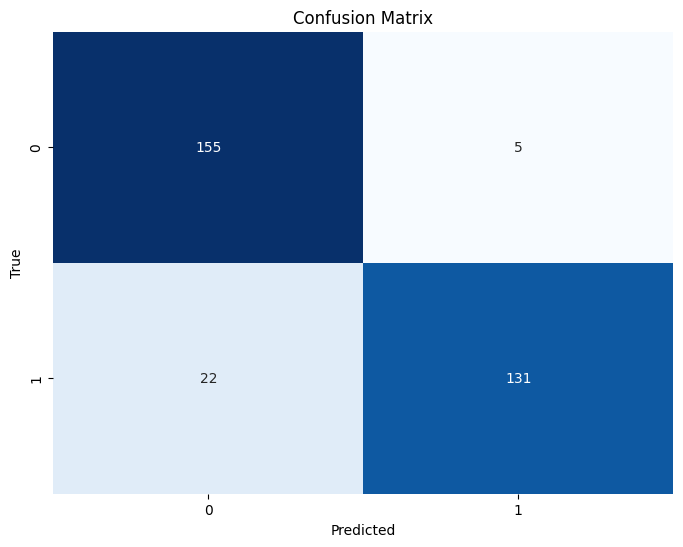

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9233226837060703
Macro F1: 0.9233219010289074
Weighted F1: 0.9233273797690476
Precision: 0.9236094094584661
Recall: 0.9237132352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       160
           1       0.91      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



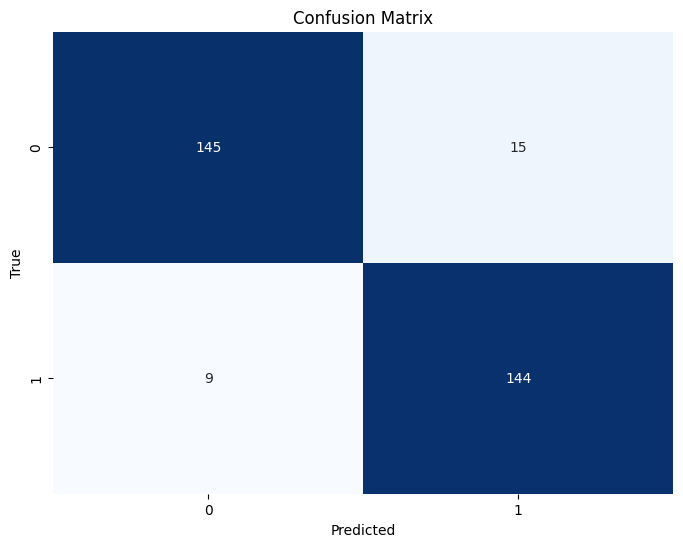

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9201277955271565
Macro F1: 0.9200755834737756
Weighted F1: 0.920121269020484
Precision: 0.9201536449820202
Recall: 0.9200163398692811
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       160
           1       0.92      0.92      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



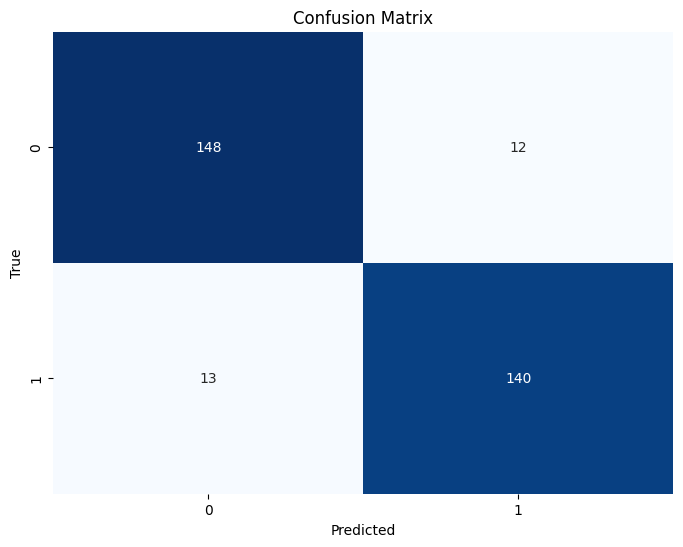

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.9233226837060703
Macro F1: 0.9233219010289074
Weighted F1: 0.9233273797690476
Precision: 0.9236094094584661
Recall: 0.9237132352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       160
           1       0.91      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



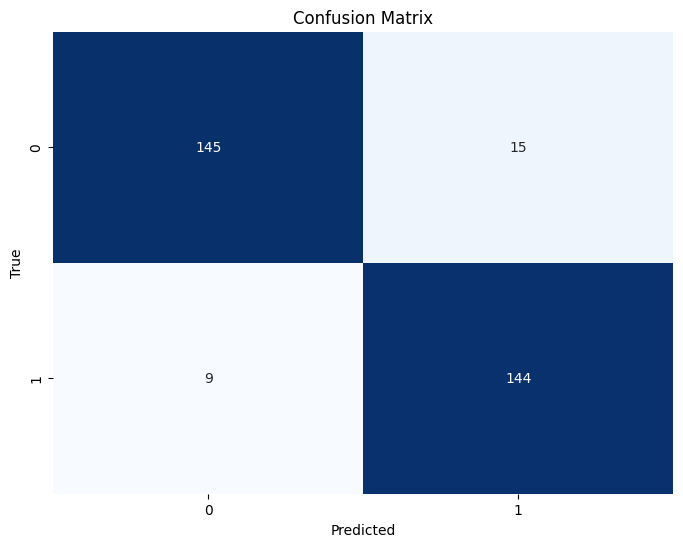

Accuracy: 0.9233226837060703
Macro F1: 0.9233219010289074
Weighted F1: 0.9233273797690476
Precision: 0.9236094094584661
Recall: 0.9237132352941176
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       160
           1       0.91      0.94      0.92       153

    accuracy                           0.92       313
   macro avg       0.92      0.92      0.92       313
weighted avg       0.92      0.92      0.92       313



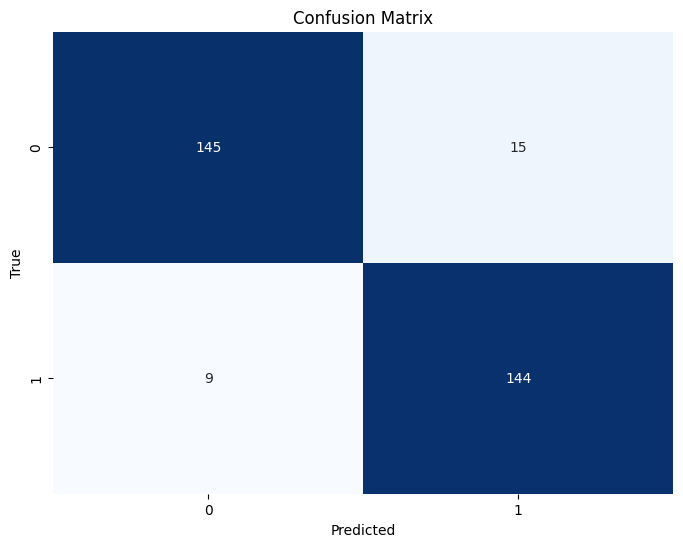

In [95]:
#Sentiment tuning
sentiment_results = find_best_config_from_grid(candidate_configs, train_ds_sent, val_ds_sent)

In [97]:
sent_df = pd.DataFrame(sentiment_results)

sent_df_sorted = sent_df.sort_values(by="macro_f1", ascending=False)

print(sent_df_sorted.head())

    learning_rate  batch_size  num_train_epochs  weight_decay  accuracy  \
17        0.00002          16                 3          0.01  0.939297   
16        0.00002          16                 3          0.00  0.936102   
9         0.00003           8                 3          0.00  0.936102   
12        0.00001          16                 3          0.00  0.936102   
7         0.00003           8                 2          0.00  0.936102   

    macro_f1  weighted_f1  precision    recall  
17  0.939287     0.939305   0.939266  0.939481  
16  0.936102     0.936106   0.936392  0.936499  
9   0.936086     0.936109   0.936035  0.936213  
12  0.936070     0.936102   0.936070  0.936070  
7   0.936049     0.936090   0.936248  0.935927  


## Running the best sentiment model

In [98]:
best_config_sent = sent_df_sorted.iloc[0].to_dict()
print("Best config:", best_config_sent)

Best config: {'learning_rate': 2e-05, 'batch_size': 16.0, 'num_train_epochs': 3.0, 'weight_decay': 0.01, 'accuracy': 0.939297124600639, 'macro_f1': 0.9392872091717457, 'weighted_f1': 0.939304561172309, 'precision': 0.9392658827372203, 'recall': 0.9394812091503268}


In [99]:
full_train_dataset_sent = concatenate_datasets([train_ds_sent, val_ds_sent])


Running sentiment model with seed: 42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.300927


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8983050847457628
Macro F1: 0.8982845729944289
Weighted F1: 0.89831831813372
Precision: 0.8982563361318581
Recall: 0.8984637052141473
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1117
           1       0.89      0.91      0.90      1066

    accuracy                           0.90      2183
   macro avg       0.90      0.90      0.90      2183
weighted avg       0.90      0.90      0.90      2183



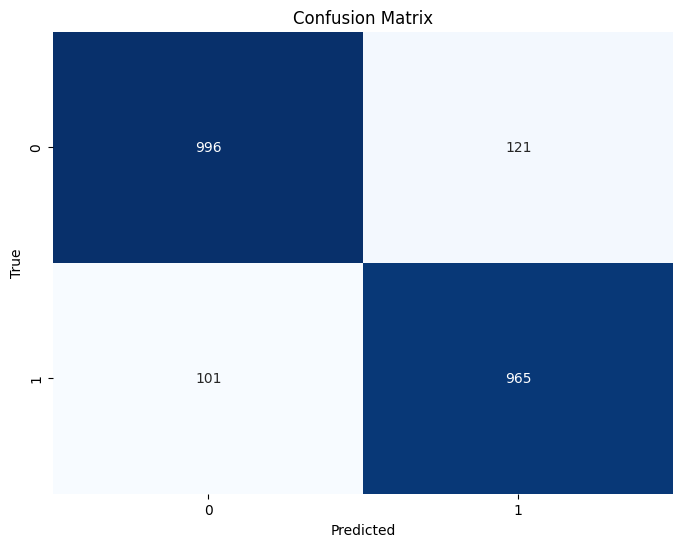

Time for seed 42: 135.24 seconds

Running sentiment model with seed: 100


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.295434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9070087036188731
Macro F1: 0.9068573452339291
Weighted F1: 0.9069450642979308
Precision: 0.9076765145275738
Recall: 0.9065617331333427
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1117
           1       0.92      0.89      0.90      1066

    accuracy                           0.91      2183
   macro avg       0.91      0.91      0.91      2183
weighted avg       0.91      0.91      0.91      2183



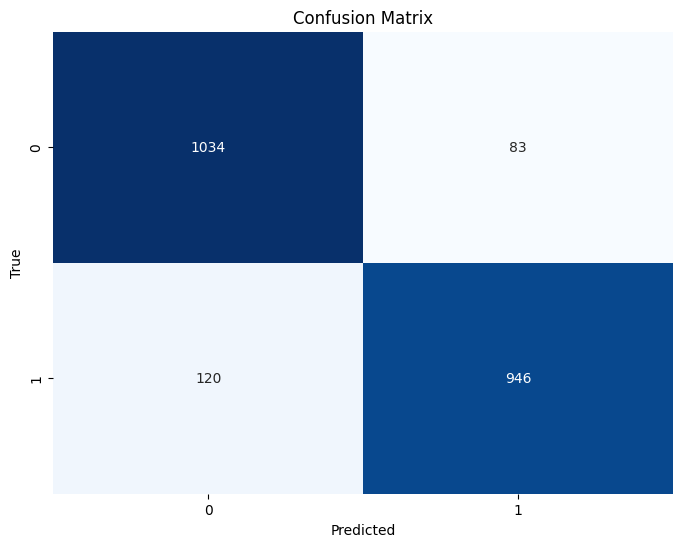

Time for seed 100: 134.80 seconds

Total runtime: 270.04 seconds


In [101]:
seeds = [42, 100]

all_results = {}

total_start_time = time.time()

for seed in seeds:
    print(f"\nRunning sentiment model with seed: {seed}")

    start_time = time.time()

    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./sentiment_final_model_seed_{seed}",
        eval_strategy="no",
        learning_rate=best_config_sent["learning_rate"],
        per_device_train_batch_size=int(best_config_sent["batch_size"]),
        num_train_epochs=int(best_config_sent["num_train_epochs"]),
        weight_decay=best_config_sent["weight_decay"],
        fp16=True,
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=full_train_dataset_sent,
        processing_class=tokenizer
    )

    trainer.train()

    pred_output = trainer.predict(test_ds_sent)
    eval_result = compute_metrics((pred_output.predictions, pred_output.label_ids))
    all_results[seed] = eval_result

    end_time = time.time()
    print(f"Time for seed {seed}: {end_time - start_time:.2f} seconds")

total_end_time = time.time()
print(f"\nTotal runtime: {total_end_time - total_start_time:.2f} seconds")

In [102]:
all_results

{42: {'accuracy': 0.8983050847457628,
  'macro_f1': 0.8982845729944289,
  'weighted_f1': 0.89831831813372,
  'precision': 0.8982563361318581,
  'recall': 0.8984637052141473,
  'classification_report': '              precision    recall  f1-score   support\n\n           0       0.91      0.89      0.90      1117\n           1       0.89      0.91      0.90      1066\n\n    accuracy                           0.90      2183\n   macro avg       0.90      0.90      0.90      2183\nweighted avg       0.90      0.90      0.90      2183\n'},
 100: {'accuracy': 0.9070087036188731,
  'macro_f1': 0.9068573452339291,
  'weighted_f1': 0.9069450642979308,
  'precision': 0.9076765145275738,
  'recall': 0.9065617331333427,
  'classification_report': '              precision    recall  f1-score   support\n\n           0       0.90      0.93      0.91      1117\n           1       0.92      0.89      0.90      1066\n\n    accuracy                           0.91      2183\n   macro avg       0.91      0.

In [103]:
trainer.save_model("drive/MyDrive/nlp/best_sentiment_model")
tokenizer.save_pretrained("drive/MyDrive/nlp/best_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('drive/MyDrive/nlp/best_sentiment_model/tokenizer_config.json',
 'drive/MyDrive/nlp/best_sentiment_model/tokenizer.json')

In [106]:
candidate_configs_s = [
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 2e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01},
    {'learning_rate': 3e-5, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01},

]

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=2e-05, bs=16, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.369660,0.862620,0.485217,0.802066,0.931090,0.511364,precision recall f1-score support 0 0.86 1.00 0.93 269 1 1.00 0.02 0.04 44 accuracy 0.86 313 macro avg 0.93 0.51 0.49 313 weighted avg 0.88 0.86 0.80 313
2,No log,0.315353,0.869010,0.666094,0.853209,0.727917,0.638645,precision recall f1-score support 0 0.90 0.96 0.93 269 1 0.56 0.32 0.41 44 accuracy 0.87 313 macro avg 0.73 0.64 0.67 313 weighted avg 0.85 0.87 0.85 313


Accuracy: 0.8626198083067093
Macro F1: 0.4852170587110346
Weighted F1: 0.8020663820656122
Precision: 0.9310897435897436
Recall: 0.5113636363636364
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       269
           1       1.00      0.02      0.04        44

    accuracy                           0.86       313
   macro avg       0.93      0.51      0.49       313
weighted avg       0.88      0.86      0.80       313



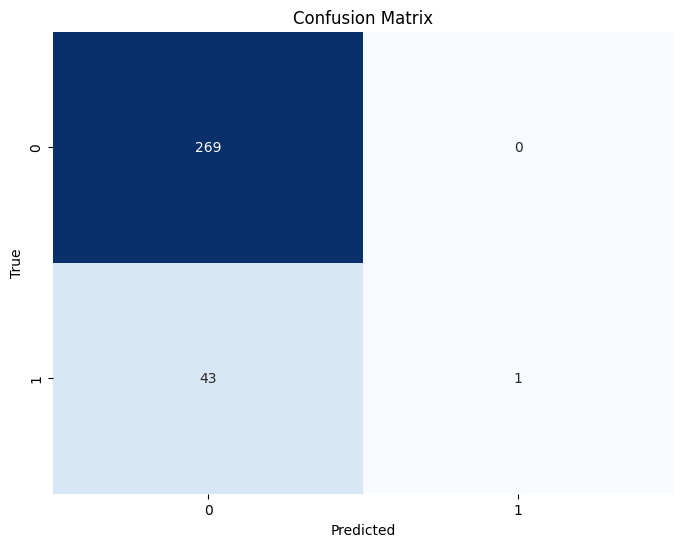

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8690095846645367
Macro F1: 0.6660942419275102
Weighted F1: 0.8532087997792763
Precision: 0.7279166666666668
Recall: 0.638644812436634
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.73      0.64      0.67       313
weighted avg       0.85      0.87      0.85       313



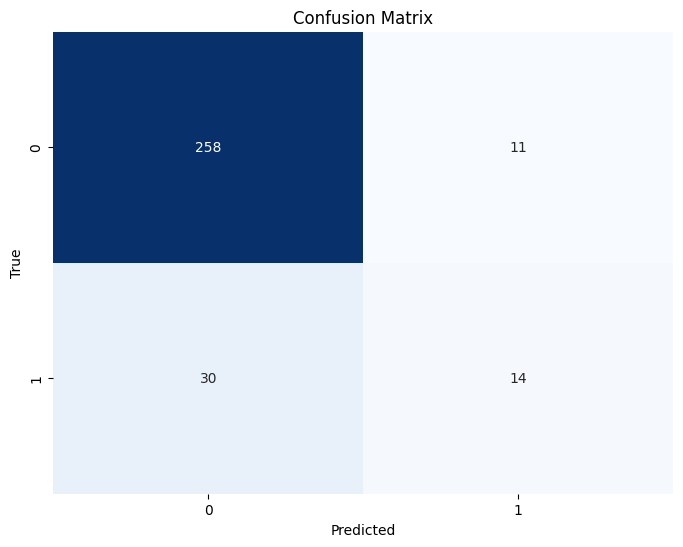

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.8690095846645367
Macro F1: 0.6660942419275102
Weighted F1: 0.8532087997792763
Precision: 0.7279166666666668
Recall: 0.638644812436634
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.73      0.64      0.67       313
weighted avg       0.85      0.87      0.85       313



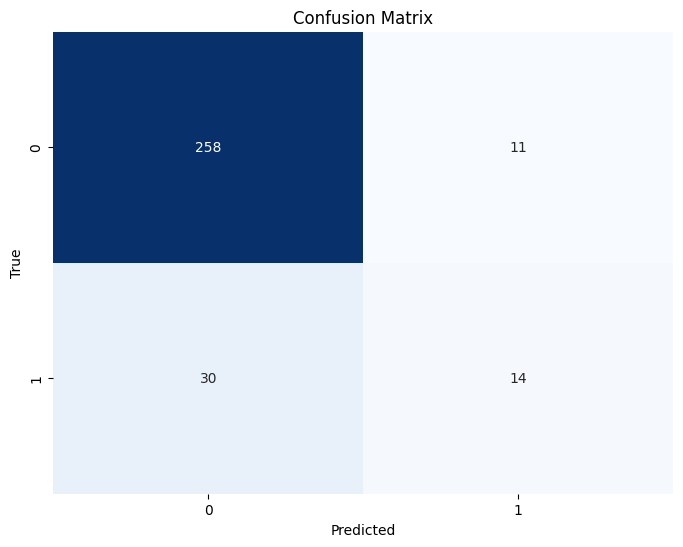

Accuracy: 0.8690095846645367
Macro F1: 0.6660942419275102
Weighted F1: 0.8532087997792763
Precision: 0.7279166666666668
Recall: 0.638644812436634
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.73      0.64      0.67       313
weighted avg       0.85      0.87      0.85       313



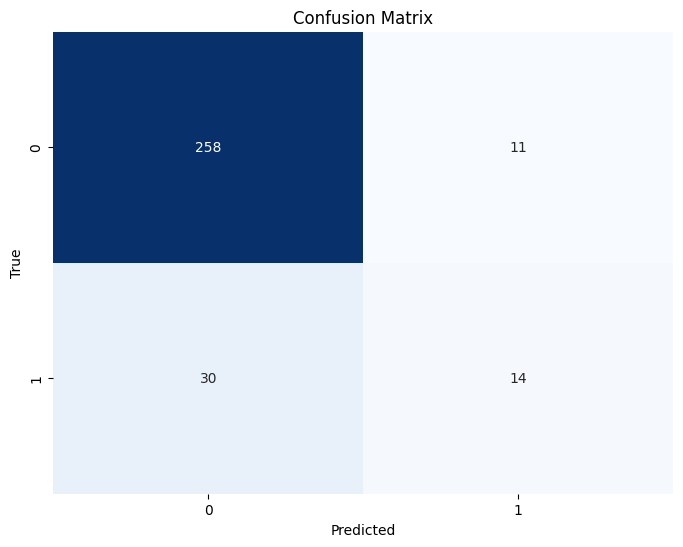

{'learning_rate': 2e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=2e-05, bs=16, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.419647,0.859425,0.462199,0.794451,0.429712,0.500000,precision recall f1-score support 0 0.86 1.00 0.92 269 1 0.00 0.00 0.00 44 accuracy 0.86 313 macro avg 0.43 0.50 0.46 313 weighted avg 0.74 0.86 0.79 313
2,No log,0.323429,0.869010,0.674331,0.855334,0.727078,0.648150,precision recall f1-score support 0 0.90 0.96 0.93 269 1 0.56 0.34 0.42 44 accuracy 0.87 313 macro avg 0.73 0.65 0.67 313 weighted avg 0.85 0.87 0.86 313
3,0.328252,0.352067,0.856230,0.659165,0.845466,0.690517,0.640715,precision recall f1-score support 0 0.90 0.94 0.92 269 1 0.48 0.34 0.40 44 accuracy 0.86 313 macro avg 0.69 0.64 0.66 313 weighted avg 0.84 0.86 0.85 313


Accuracy: 0.8594249201277955
Macro F1: 0.46219931271477666
Weighted F1: 0.7944512148260379
Precision: 0.42971246006389774
Recall: 0.5
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       269
           1       0.00      0.00      0.00        44

    accuracy                           0.86       313
   macro avg       0.43      0.50      0.46       313
weighted avg       0.74      0.86      0.79       313



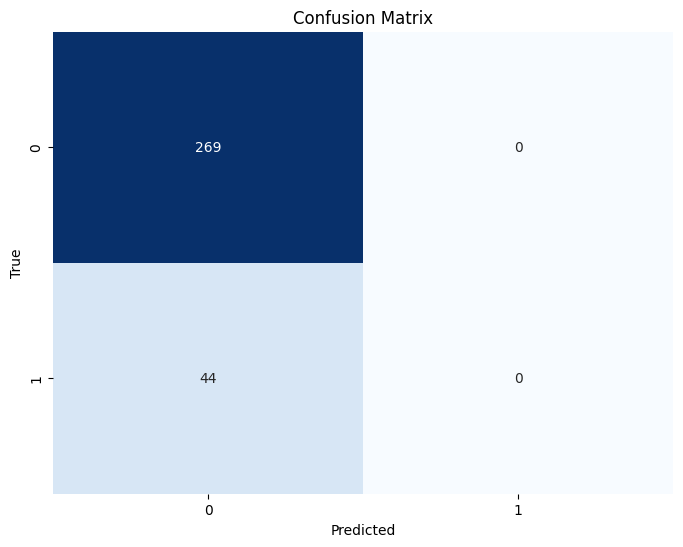

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8690095846645367
Macro F1: 0.6743306686968659
Weighted F1: 0.855333793046973
Precision: 0.7270784770784771
Recall: 0.6481497127407908
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.34      0.42        44

    accuracy                           0.87       313
   macro avg       0.73      0.65      0.67       313
weighted avg       0.85      0.87      0.86       313



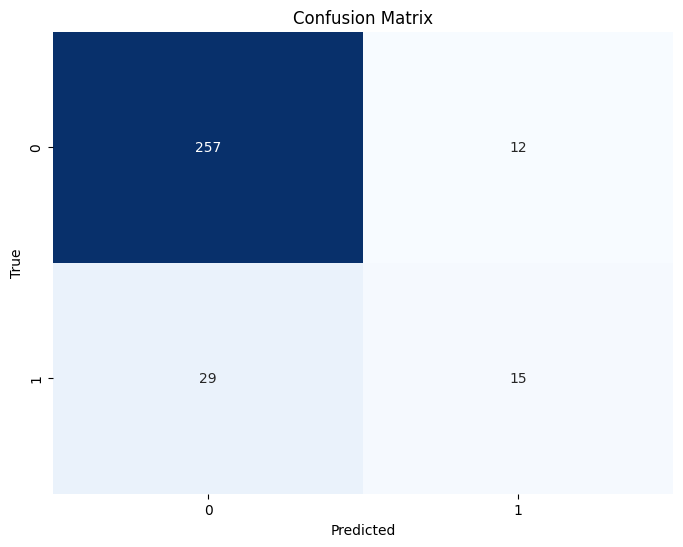

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8562300319488818
Macro F1: 0.6591651542649728
Weighted F1: 0.8454659840081641
Precision: 0.6905170441546558
Recall: 0.6407147685028726
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       269
           1       0.48      0.34      0.40        44

    accuracy                           0.86       313
   macro avg       0.69      0.64      0.66       313
weighted avg       0.84      0.86      0.85       313



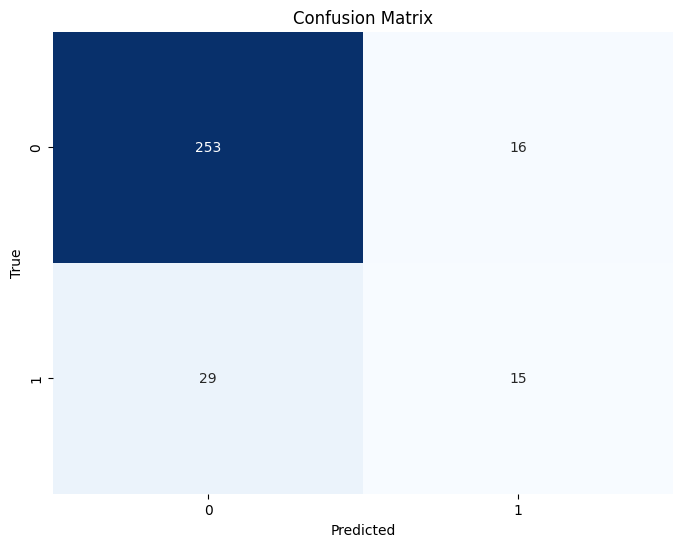

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.8690095846645367
Macro F1: 0.6743306686968659
Weighted F1: 0.855333793046973
Precision: 0.7270784770784771
Recall: 0.6481497127407908
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.34      0.42        44

    accuracy                           0.87       313
   macro avg       0.73      0.65      0.67       313
weighted avg       0.85      0.87      0.86       313



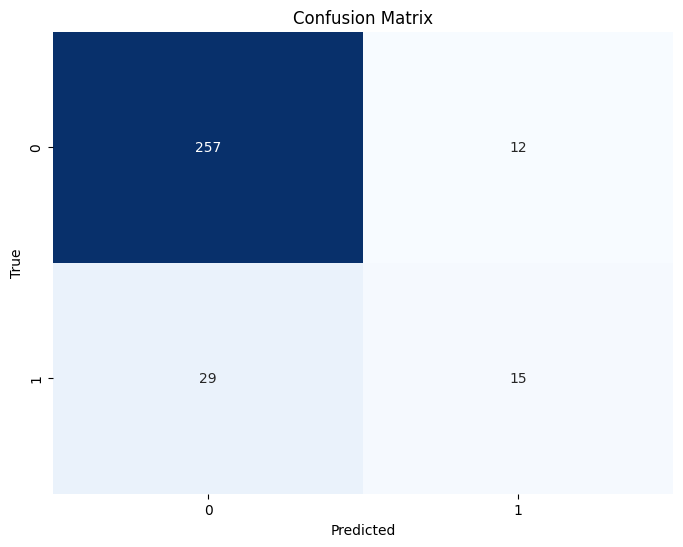

Accuracy: 0.8690095846645367
Macro F1: 0.6743306686968659
Weighted F1: 0.855333793046973
Precision: 0.7270784770784771
Recall: 0.6481497127407908
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.56      0.34      0.42        44

    accuracy                           0.87       313
   macro avg       0.73      0.65      0.67       313
weighted avg       0.85      0.87      0.86       313



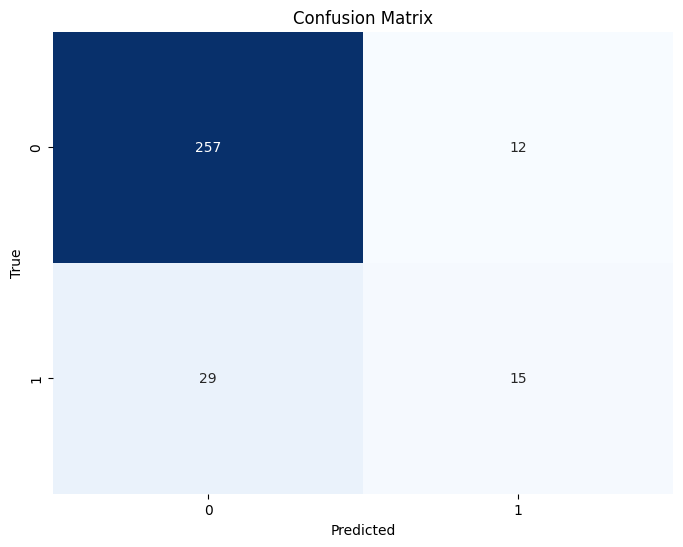

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.01}
Running: lr=3e-05, bs=16, epochs=2, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.513997,0.837061,0.594899,0.820049,0.625745,0.582038,precision recall f1-score support 0 0.88 0.94 0.91 269 1 0.37 0.23 0.28 44 accuracy 0.84 313 macro avg 0.63 0.58 0.59 313 weighted avg 0.81 0.84 0.82 313
2,No log,0.312373,0.862620,0.666601,0.850369,0.707564,0.644432,precision recall f1-score support 0 0.90 0.95 0.92 269 1 0.52 0.34 0.41 44 accuracy 0.86 313 macro avg 0.71 0.64 0.67 313 weighted avg 0.84 0.86 0.85 313


Accuracy: 0.8370607028753994
Macro F1: 0.5948991244765893
Weighted F1: 0.8200493523267226
Precision: 0.6257446257446257
Recall: 0.5820378506252112
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       269
           1       0.37      0.23      0.28        44

    accuracy                           0.84       313
   macro avg       0.63      0.58      0.59       313
weighted avg       0.81      0.84      0.82       313



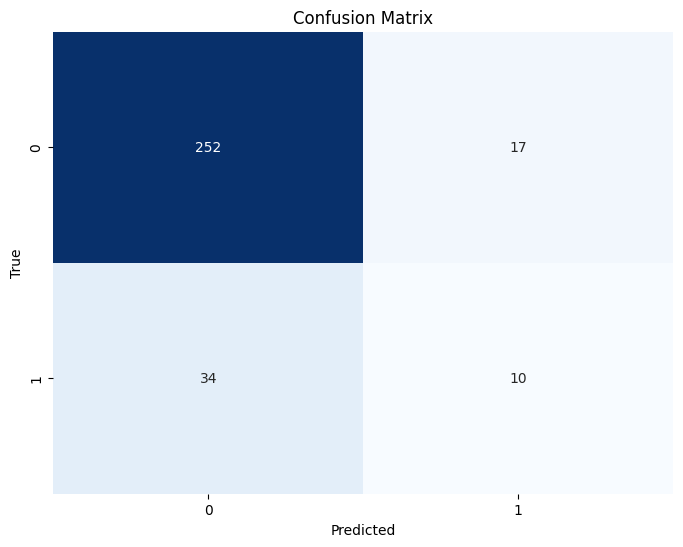

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8626198083067093
Macro F1: 0.6666006093784835
Weighted F1: 0.8503686083736952
Precision: 0.7075643516270034
Recall: 0.6444322406218317
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       269
           1       0.52      0.34      0.41        44

    accuracy                           0.86       313
   macro avg       0.71      0.64      0.67       313
weighted avg       0.84      0.86      0.85       313



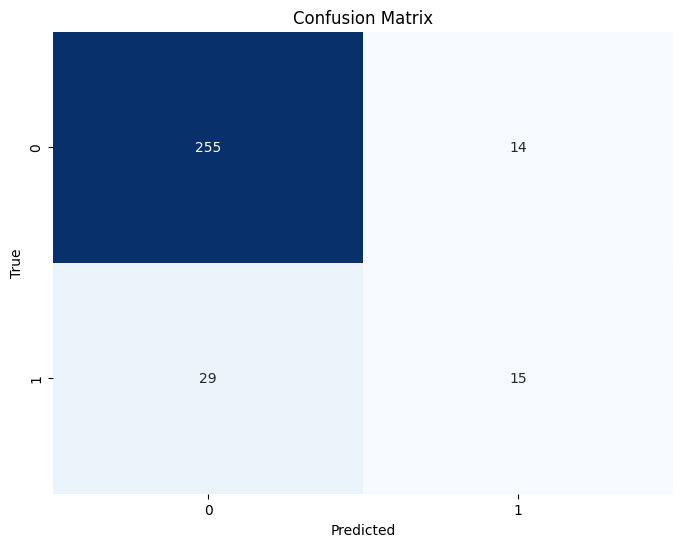

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.8626198083067093
Macro F1: 0.6666006093784835
Weighted F1: 0.8503686083736952
Precision: 0.7075643516270034
Recall: 0.6444322406218317
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       269
           1       0.52      0.34      0.41        44

    accuracy                           0.86       313
   macro avg       0.71      0.64      0.67       313
weighted avg       0.84      0.86      0.85       313



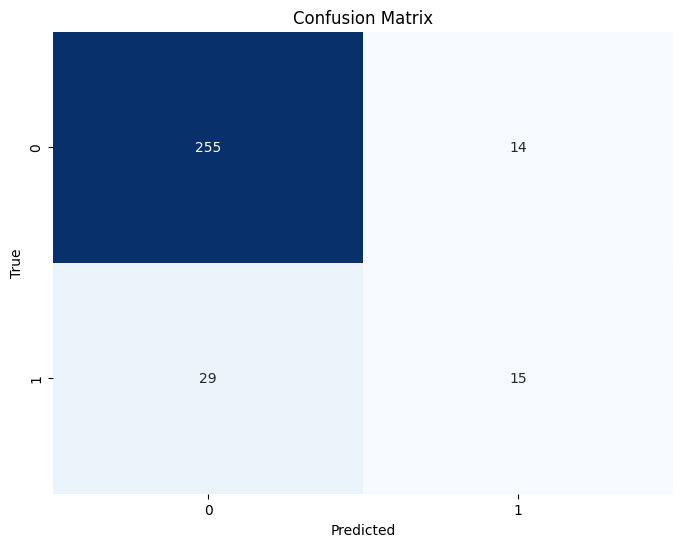

Accuracy: 0.8626198083067093
Macro F1: 0.6666006093784835
Weighted F1: 0.8503686083736952
Precision: 0.7075643516270034
Recall: 0.6444322406218317
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       269
           1       0.52      0.34      0.41        44

    accuracy                           0.86       313
   macro avg       0.71      0.64      0.67       313
weighted avg       0.84      0.86      0.85       313



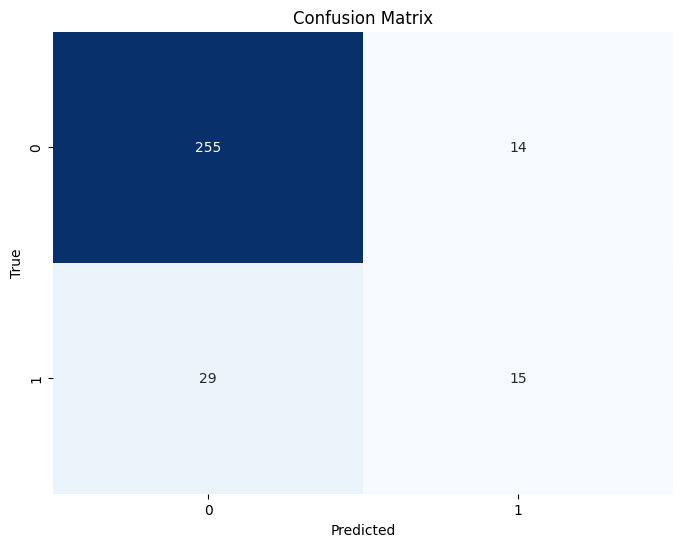

{'learning_rate': 3e-05, 'batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.01}
Running: lr=3e-05, bs=16, epochs=3, wd=0.01


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall,Classification Report
1,No log,0.396482,0.865815,0.507271,0.809415,0.932476,0.522727,precision recall f1-score support 0 0.86 1.00 0.93 269 1 1.00 0.05 0.09 44 accuracy 0.87 313 macro avg 0.93 0.52 0.51 313 weighted avg 0.88 0.87 0.81 313
2,No log,0.369222,0.872204,0.670040,0.855701,0.739764,0.640504,precision recall f1-score support 0 0.90 0.96 0.93 269 1 0.58 0.32 0.41 44 accuracy 0.87 313 macro avg 0.74 0.64 0.67 313 weighted avg 0.85 0.87 0.86 313
3,0.327319,0.388147,0.849840,0.652000,0.840619,0.675487,0.636997,precision recall f1-score support 0 0.90 0.93 0.91 269 1 0.45 0.34 0.39 44 accuracy 0.85 313 macro avg 0.68 0.64 0.65 313 weighted avg 0.83 0.85 0.84 313


Accuracy: 0.865814696485623
Macro F1: 0.507271364317841
Weighted F1: 0.8094146217626011
Precision: 0.932475884244373
Recall: 0.5227272727272727
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       269
           1       1.00      0.05      0.09        44

    accuracy                           0.87       313
   macro avg       0.93      0.52      0.51       313
weighted avg       0.88      0.87      0.81       313



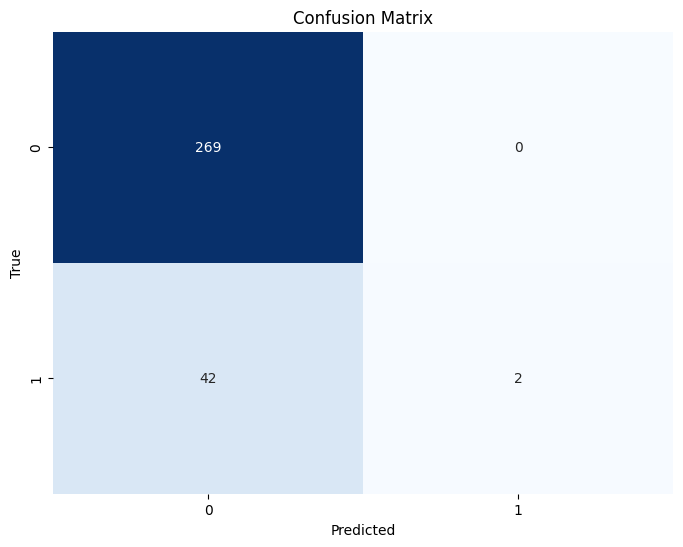

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8722044728434505
Macro F1: 0.6700400590343665
Weighted F1: 0.8557012553896478
Precision: 0.7397635524798154
Recall: 0.6405035484961136
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.58      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.74      0.64      0.67       313
weighted avg       0.85      0.87      0.86       313



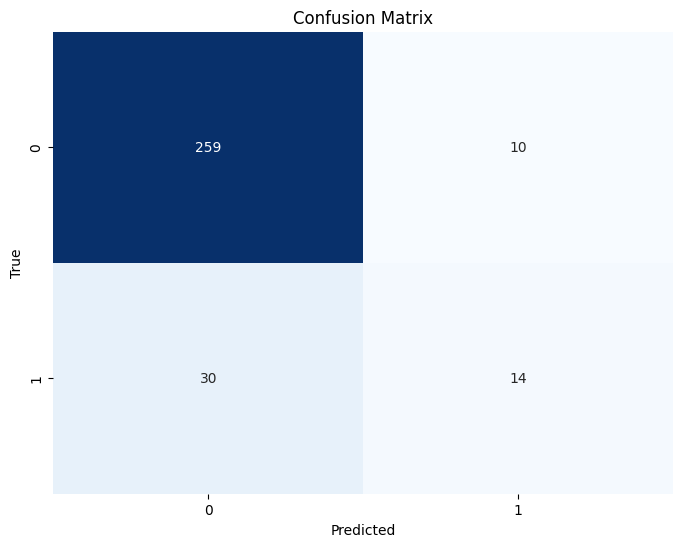

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8498402555910544
Macro F1: 0.6520000946230455
Weighted F1: 0.8406188921561049
Precision: 0.675487012987013
Recall: 0.6369972963839134
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       269
           1       0.45      0.34      0.39        44

    accuracy                           0.85       313
   macro avg       0.68      0.64      0.65       313
weighted avg       0.83      0.85      0.84       313



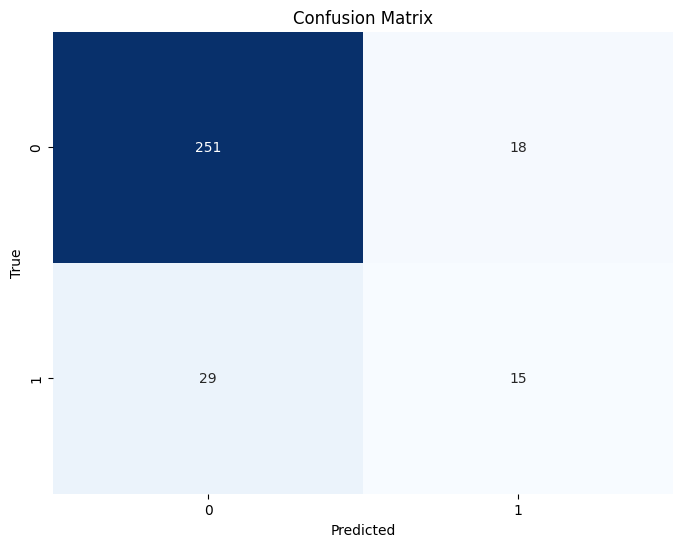

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.8722044728434505
Macro F1: 0.6700400590343665
Weighted F1: 0.8557012553896478
Precision: 0.7397635524798154
Recall: 0.6405035484961136
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.58      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.74      0.64      0.67       313
weighted avg       0.85      0.87      0.86       313



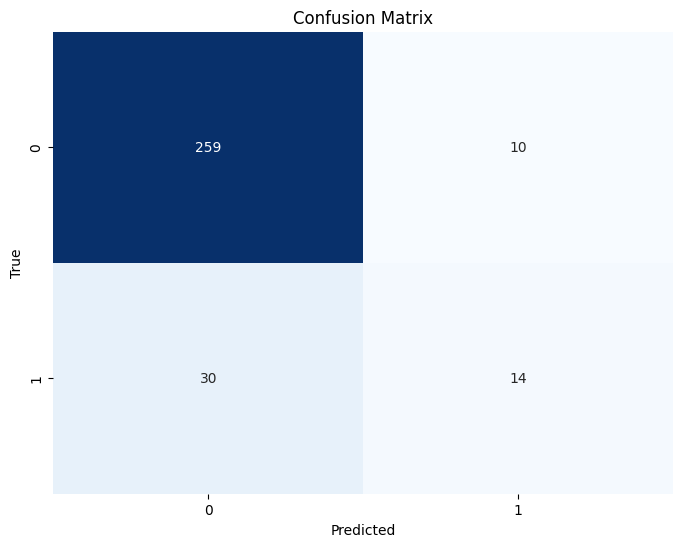

Accuracy: 0.8722044728434505
Macro F1: 0.6700400590343665
Weighted F1: 0.8557012553896478
Precision: 0.7397635524798154
Recall: 0.6405035484961136
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       269
           1       0.58      0.32      0.41        44

    accuracy                           0.87       313
   macro avg       0.74      0.64      0.67       313
weighted avg       0.85      0.87      0.86       313



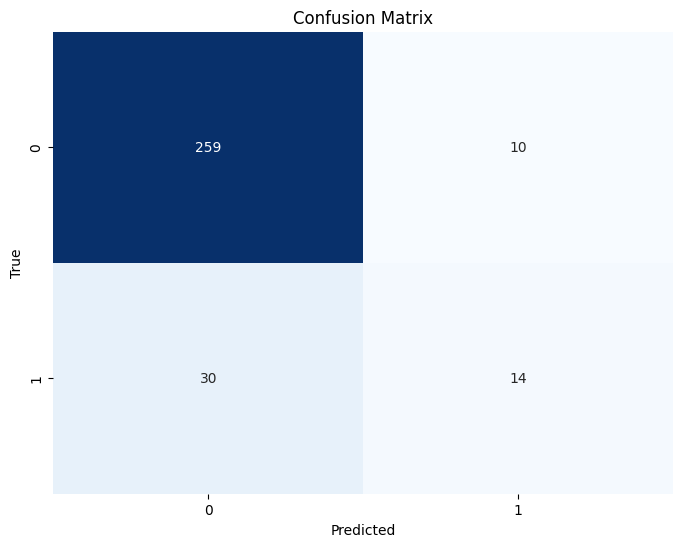

In [107]:
#Sarcasm tuning
sarcasm_results = find_best_config_from_grid(candidate_configs_s, train_ds_sarc, val_ds_sarc)

## Running the best sarcasm model

In [108]:
sarc_df = pd.DataFrame(sarcasm_results)

sarc_df_sorted = sarc_df.sort_values(by="macro_f1", ascending=False)

print(sarc_df_sorted.head())

   learning_rate  batch_size  num_train_epochs  weight_decay  accuracy  \
1        0.00002          16                 3          0.01  0.869010   
3        0.00003          16                 3          0.01  0.872204   
2        0.00003          16                 2          0.01  0.862620   
0        0.00002          16                 2          0.01  0.869010   

   macro_f1  weighted_f1  precision    recall  
1  0.674331     0.855334   0.727078  0.648150  
3  0.670040     0.855701   0.739764  0.640504  
2  0.666601     0.850369   0.707564  0.644432  
0  0.666094     0.853209   0.727917  0.638645  


In [109]:
best_config_sarc = sarc_df_sorted.iloc[0].to_dict()
print("Best config:", best_config_sarc)

Best config: {'learning_rate': 2e-05, 'batch_size': 16.0, 'num_train_epochs': 3.0, 'weight_decay': 0.01, 'accuracy': 0.8690095846645367, 'macro_f1': 0.6743306686968659, 'weighted_f1': 0.855333793046973, 'precision': 0.7270784770784771, 'recall': 0.6481497127407908}


In [110]:
full_train_dataset_sarc = concatenate_datasets([train_ds_sarc, val_ds_sarc])


Running sarcasm model with seed: 42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.302014


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8767750801649107
Macro F1: 0.6977868744046207
Weighted F1: 0.8653752361075588
Precision: 0.7480993817265857
Recall: 0.6702377834808568
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1878
           1       0.59      0.38      0.47       305

    accuracy                           0.88      2183
   macro avg       0.75      0.67      0.70      2183
weighted avg       0.86      0.88      0.87      2183



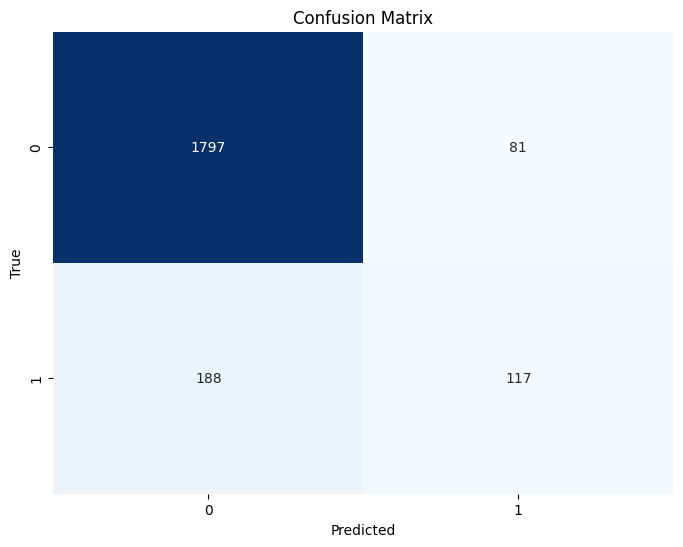

Time for seed 42: 135.33 seconds

Running sarcasm model with seed: 100


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.334582


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.8676133760879523
Macro F1: 0.6672278916139596
Weighted F1: 0.8533001271969529
Precision: 0.7204634926158731
Recall: 0.641570208977112
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1878
           1       0.54      0.33      0.41       305

    accuracy                           0.87      2183
   macro avg       0.72      0.64      0.67      2183
weighted avg       0.85      0.87      0.85      2183



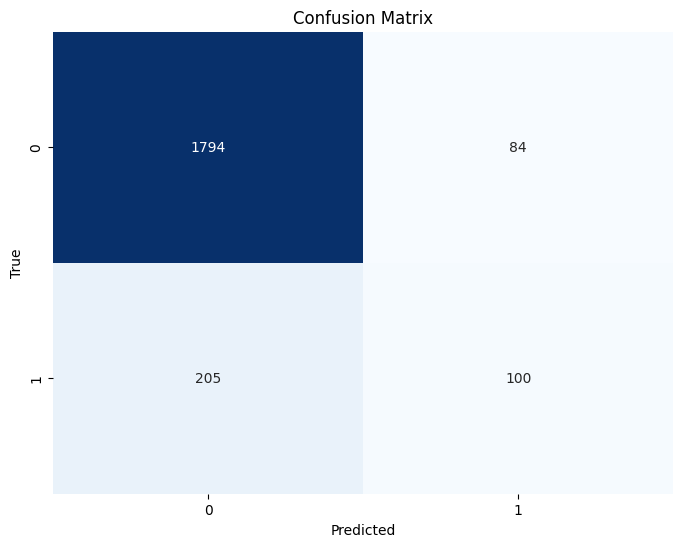

Time for seed 100: 136.65 seconds

Total runtime: 1208.22 seconds


In [113]:
from transformers import DataCollatorWithPadding

seeds = [42, 100]

all_results_sarc = {}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

for seed in seeds:
    print(f"\nRunning sarcasm model with seed: {seed}")

    start_time = time.time()

    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./sarcasm_final_model_seed_{seed}",
        eval_strategy="no",
        learning_rate=best_config_sarc["learning_rate"],
        per_device_train_batch_size=int(best_config_sarc["batch_size"]),
        num_train_epochs=int(best_config_sarc["num_train_epochs"]),
        weight_decay=best_config_sarc["weight_decay"],
        fp16=True,
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=full_train_dataset_sarc,
        data_collator=data_collator,
    )

    trainer.train()

    pred_output = trainer.predict(test_ds_sarc)
    eval_result = compute_metrics((pred_output.predictions, pred_output.label_ids))
    all_results_sarc[seed] = eval_result

    end_time = time.time()
    print(f"Time for seed {seed}: {end_time - start_time:.2f} seconds")

total_end_time = time.time()
print(f"\nTotal runtime: {total_end_time - total_start_time:.2f} seconds")

In [114]:
all_results_sarc

{42: {'accuracy': 0.8767750801649107,
  'macro_f1': 0.6977868744046207,
  'weighted_f1': 0.8653752361075588,
  'precision': 0.7480993817265857,
  'recall': 0.6702377834808568,
  'classification_report': '              precision    recall  f1-score   support\n\n           0       0.91      0.96      0.93      1878\n           1       0.59      0.38      0.47       305\n\n    accuracy                           0.88      2183\n   macro avg       0.75      0.67      0.70      2183\nweighted avg       0.86      0.88      0.87      2183\n'},
 100: {'accuracy': 0.8676133760879523,
  'macro_f1': 0.6672278916139596,
  'weighted_f1': 0.8533001271969529,
  'precision': 0.7204634926158731,
  'recall': 0.641570208977112,
  'classification_report': '              precision    recall  f1-score   support\n\n           0       0.90      0.96      0.93      1878\n           1       0.54      0.33      0.41       305\n\n    accuracy                           0.87      2183\n   macro avg       0.72      0

In [115]:
trainer.save_model("drive/MyDrive/nlp/best_sarcasm_model")
tokenizer.save_pretrained("drive/MyDrive/nlp/best_sarcasm_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('drive/MyDrive/nlp/best_sarcasm_model/tokenizer_config.json',
 'drive/MyDrive/nlp/best_sarcasm_model/tokenizer.json')